# Bitcoin Forecasting Pipeline — Kompletny Notebook
## Połączony pipeline: Ingestion → Preprocessing → Feature Engineering → ARIMA → LSTM → BLSTM

Ten notebook zawiera pełny, zintegrowany pipeline:
1. **Ingestion** (`DataIngestor`) — pobieranie danych rynkowych i on-chain
2. **Preprocessing** (`DataPreprocessor`) — scalanie i czyszczenie danych
3. **Feature Engineering** (`FeatureEngineer`) — generowanie cech technicznych i on-chain
4. **Modelowanie** — ARIMA, ARIMAX, LSTM, BLSTM
5. **Ewaluacja i wizualizacja** — walk-forward, metryki, prognozy wielohoryzontowe

> **Uwaga:** Sekcje 1–3 (pipeline danych) można pominąć, jeśli plik `bitcoin_final.csv` już istnieje.

---
## Sekcja 0A: DataIngestor — pobieranie danych
Pobiera dane rynkowe (Yahoo Finance) oraz on-chain (Blockchain.com, CoinMetrics, mempool.space).  
Dane zapisywane są do `data/raw/`.  
**Pomiń tę sekcję** jeśli dane raw już istnieją.

In [1]:
import pandas as pd
import numpy as np
import requests
import os
import time
import yfinance as yf
from datetime import datetime


class DataIngestor:
    def __init__(self, base_dir="data/raw"):
        self.base_dir = base_dir
        os.makedirs(self.base_dir, exist_ok=True)

    def get_market_data(self, ticker="BTC-USD", period="5y"):
        print(f"Pobieranie danych dla {ticker} z Yahoo Finance (zakres: {period})...")
        try:
            btc = yf.Ticker(ticker)
            df = btc.history(period=period).reset_index()
            df = df[['Date', 'Close', 'Volume']]
            df.columns = ['date', 'price', 'total_volume']
            df['market_cap'] = df['price'] * 19_000_000
            df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None).dt.normalize()
            path = os.path.join(self.base_dir, "bitcoin_daily_market_data.csv")
            df.to_csv(path, index=False)
            print(f"Sukces! Dane rynkowe zapisane w: {path}")
            return df
        except Exception as e:
            print(f"Błąd Yahoo Finance: {e}")
            return None

    def get_blockchain_com_data(self, charts=["n-transactions", "hash-rate",
                                               "estimated-transaction-volume-usd",
                                               "n-unique-addresses"]):
        all_onchain_data = []
        for chart in charts:
            print(f"Pobieranie metryki on-chain: {chart}...")
            url = f"https://api.blockchain.info/charts/{chart}"
            params = {"timespan": "5years", "sampled": "true", "format": "json", "cors": "true"}
            try:
                response = requests.get(url, params=params)
                response.raise_for_status()
                df_chart = pd.DataFrame(response.json()['values'])
                df_chart.columns = ['timestamp', chart]
                df_chart['date'] = pd.to_datetime(df_chart['timestamp'], unit='s').dt.normalize()
                df_chart.drop(columns=['timestamp'], inplace=True)
                all_onchain_data.append(df_chart)
                time.sleep(1)
            except Exception as e:
                print(f"Błąd przy pobieraniu {chart}: {e}")
        if all_onchain_data:
            final_df = all_onchain_data[0]
            for next_df in all_onchain_data[1:]:
                final_df = final_df.merge(next_df, on='date', how='outer')
            path = os.path.join(self.base_dir, "bitcoin_onchain_data.csv")
            final_df.to_csv(path, index=False)
            print(f"Dane on-chain zapisane w: {path}")
            return final_df
        return None

    def get_stablecoin_data(self):
        print("Pobieranie danych stablecoin...")
        try:
            url = "https://community-api.coinmetrics.io/v4/timeseries/asset-metrics"
            params = {"assets": "usdt,usdc,dai,busd", "metrics": "CapMrktCurUSD",
                      "frequency": "1d", "start_time": "2014-01-01", "page_size": 10000}
            all_data = []
            next_page = None
            while True:
                if next_page:
                    params["next_page_token"] = next_page
                r = requests.get(url, params=params, timeout=30)
                r.raise_for_status()
                result = r.json()
                all_data.extend(result["data"])
                next_page = result.get("next_page_token")
                if not next_page:
                    break
                time.sleep(0.3)
            df = pd.DataFrame(all_data)
            df["date"] = pd.to_datetime(df["time"]).dt.tz_localize(None).dt.normalize()
            df["CapMrktCurUSD"] = pd.to_numeric(df["CapMrktCurUSD"], errors="coerce")
            stable_total = df.groupby("date")["CapMrktCurUSD"].sum().reset_index()
            stable_total.columns = ["date", "stablecoin_market_cap"]
            path = os.path.join(self.base_dir, "stablecoin_data.csv")
            stable_total.to_csv(path, index=False)
            print(f"Sukces! Dane stablecoin zapisane w: {path}")
            return stable_total
        except Exception as e:
            print(f"Błąd przy pobieraniu danych stablecoin: {e}")
            return None

    def get_active_addresses_data(self, start_time="2014-01-01"):
        print(f"Pobieranie liczby aktywnych adresów z CoinMetrics (od {start_time})...")
        try:
            url = "https://community-api.coinmetrics.io/v4/timeseries/asset-metrics"
            params = {"assets": "btc", "metrics": "AdrActCnt", "frequency": "1d",
                      "start_time": start_time, "page_size": 10000}
            all_data, next_page = [], None
            while True:
                if next_page:
                    params["next_page_token"] = next_page
                r = requests.get(url, params=params)
                r.raise_for_status()
                result = r.json()
                all_data.extend(result["data"])
                next_page = result.get("next_page_token")
                if not next_page:
                    break
                time.sleep(0.5)
            df = pd.DataFrame(all_data)
            df["date"] = pd.to_datetime(df["time"]).dt.tz_localize(None).dt.normalize()
            df["active_addresses"] = pd.to_numeric(df["AdrActCnt"], errors="coerce")
            df = df[["date", "active_addresses"]].dropna()
            path = os.path.join(self.base_dir, "active_addresses_data.csv")
            df.to_csv(path, index=False)
            print(f"Sukces! Aktywne adresy zapisane w: {path} ({len(df)} rekordów)")
            return df
        except Exception as e:
            print(f"Błąd CoinMetrics (aktywne adresy): {e}")
            return None

    def get_lightning_network_data(self):
        print("Pobieranie danych Lightning Network z mempool.space...")
        try:
            url = "https://mempool.space/api/v1/lightning/statistics/3y"
            r = requests.get(url, timeout=30)
            r.raise_for_status()
            df = pd.DataFrame(r.json())
            df["date"] = pd.to_datetime(df["added"], unit="s").dt.normalize()
            if "node_count" not in df.columns:
                node_cols = [c for c in ["tor_nodes", "clearnet_nodes", "unannounced_nodes",
                                          "clearnet_tor_nodes"] if c in df.columns]
                df["ln_node_count"] = df[node_cols].sum(axis=1)
            else:
                df = df.rename(columns={"node_count": "ln_node_count"})
            df = df.rename(columns={"channel_count": "ln_channel_count",
                                     "total_capacity": "ln_total_capacity_sat"})
            keep = ["date"] + [c for c in ["ln_node_count", "ln_channel_count",
                                             "ln_total_capacity_sat"] if c in df.columns]
            df = df[keep]
            path = os.path.join(self.base_dir, "lightning_network_data.csv")
            df.to_csv(path, index=False)
            print(f"Sukces! Lightning Network zapisane w: {path}")
            return df
        except Exception as e:
            print(f"Błąd Lightning Network: {e}")
            return None

    def get_hodl_wave_data(self, start_time="2014-01-01"):
        print(f"Pobieranie danych HODL Wave z CoinMetrics (od {start_time})...")
        metrics_to_fetch = ["SplyAct1yr", "SplyAct180d", "SplyAct30d", "RevAllTime"]
        url = "https://community-api.coinmetrics.io/v4/timeseries/asset-metrics"
        all_data, next_page = [], None
        params = {"assets": "btc", "metrics": ",".join(metrics_to_fetch),
                  "frequency": "1d", "start_time": start_time, "page_size": 10000}
        try:
            while True:
                if next_page:
                    params["next_page_token"] = next_page
                r = requests.get(url, params=params, timeout=30)
                r.raise_for_status()
                result = r.json()
                all_data.extend(result["data"])
                next_page = result.get("next_page_token")
                if not next_page:
                    break
                time.sleep(0.5)
            df = pd.DataFrame(all_data)
            df["date"] = pd.to_datetime(df["time"]).dt.tz_localize(None).dt.normalize()
            for col in metrics_to_fetch:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors="coerce")
            df = df.rename(columns={"SplyAct1yr": "hodl_1yr_supply",
                                     "SplyAct180d": "hodl_180d_supply",
                                     "SplyAct30d": "hodl_30d_supply",
                                     "RevAllTime": "realized_value_usd"})
            if "hodl_1yr_supply" in df.columns and "hodl_30d_supply" in df.columns:
                df["stale_vs_liquid_ratio"] = df["hodl_1yr_supply"] / (df["hodl_30d_supply"] + 1)
            keep = ["date"] + [c for c in ["hodl_1yr_supply", "hodl_180d_supply",
                                             "hodl_30d_supply", "realized_value_usd",
                                             "stale_vs_liquid_ratio"] if c in df.columns]
            df = df[keep].dropna(subset=["hodl_1yr_supply"])
            path = os.path.join(self.base_dir, "hodl_wave_data.csv")
            df.to_csv(path, index=False)
            print(f"Sukces! HODL Wave zapisane w: {path} ({len(df)} rekordów)")
            return df
        except Exception as e:
            print(f"Błąd HODL Wave: {e}")
            return None

    def get_whale_transaction_data(self, start_time="2014-01-01"):
        print(f"Pobieranie danych ruchów wielorybów (od {start_time})...")
        cm_metrics = ["TxTfrValAdjUSD", "TxCnt", "TxCnt10kUSD", "TxCnt100kUSD", "TxCnt1mUSD"]
        url = "https://community-api.coinmetrics.io/v4/timeseries/asset-metrics"
        all_data, next_page = [], None
        params = {"assets": "btc", "metrics": ",".join(cm_metrics), "frequency": "1d",
                  "start_time": start_time, "page_size": 10000}
        cm_df = None
        try:
            while True:
                if next_page:
                    params["next_page_token"] = next_page
                r = requests.get(url, params=params, timeout=30)
                r.raise_for_status()
                result = r.json()
                all_data.extend(result["data"])
                next_page = result.get("next_page_token")
                if not next_page:
                    break
                time.sleep(0.5)
            cm_df = pd.DataFrame(all_data)
            cm_df["date"] = pd.to_datetime(cm_df["time"]).dt.tz_localize(None).dt.normalize()
            for col in cm_metrics:
                if col in cm_df.columns:
                    cm_df[col] = pd.to_numeric(cm_df[col], errors="coerce")
            cm_df = cm_df.rename(columns={
                "TxTfrValAdjUSD": "whale_adj_transfer_usd", "TxCnt": "whale_total_tx_count",
                "TxCnt10kUSD": "whale_tx_above_10k", "TxCnt100kUSD": "whale_tx_above_100k",
                "TxCnt1mUSD": "whale_tx_above_1m"})
        except Exception as e:
            print(f"   CoinMetrics whale TX nie powiodło się: {e}")
        bchain_df = None
        try:
            url2 = "https://api.blockchain.info/charts/median-transaction-value"
            r2 = requests.get(url2, params={"timespan": "5years", "sampled": "true",
                                              "format": "json", "cors": "true"}, timeout=30)
            r2.raise_for_status()
            bchain_df = pd.DataFrame(r2.json()["values"])
            bchain_df.columns = ["timestamp", "whale_median_tx_usd"]
            bchain_df["date"] = pd.to_datetime(bchain_df["timestamp"], unit="s").dt.normalize()
            bchain_df = bchain_df[["date", "whale_median_tx_usd"]]
        except Exception as e:
            print(f"   Blockchain.com median TX nie powiodło się: {e}")
        if cm_df is not None and bchain_df is not None:
            final_df = pd.merge(cm_df, bchain_df, on="date", how="outer")
        elif cm_df is not None:
            final_df = cm_df
        elif bchain_df is not None:
            final_df = bchain_df
        else:
            print("Błąd: Oba źródła whale TX zawiodły.")
            return None
        final_df = final_df.sort_values("date").reset_index(drop=True)
        path = os.path.join(self.base_dir, "whale_transaction_data.csv")
        final_df.to_csv(path, index=False)
        print(f"Sukces! Dane whale TX zapisane w: {path} ({len(final_df)} rekordów)")
        return final_df


# ── Uruchomienie ingestion ──────────────────────────────────────────────────
# Odkomentuj linie, których dane chcesz pobrać.
# Jeśli dane raw już istnieją (data/raw/), możesz pominąć całą sekcję.

# ingestor = DataIngestor()
# ingestor.get_market_data(period="5y")
# ingestor.get_blockchain_com_data()
# ingestor.get_stablecoin_data()
# ingestor.get_active_addresses_data(start_time="2014-01-01")
# ingestor.get_lightning_network_data()
# ingestor.get_hodl_wave_data()
# ingestor.get_whale_transaction_data()
print("DataIngestor zdefiniowany. Odkomentuj wywołania powyżej, aby pobrać dane.")

DataIngestor zdefiniowany. Odkomentuj wywołania powyżej, aby pobrać dane.


---
## Sekcja 0B: DataPreprocessor — scalanie i czyszczenie
Scala pliki z `data/raw/` w jeden `bitcoin_master.csv` i stosuje interpolację liniową na brakach.  
**Pomiń tę sekcję** jeśli `data/processed/bitcoin_master.csv` już istnieje.

In [2]:
class DataPreprocessor:
    def __init__(self, raw_dir="data/raw", processed_dir="data/processed"):
        self.raw_dir = raw_dir
        self.processed_dir = processed_dir
        os.makedirs(self.processed_dir, exist_ok=True)

    def merge_and_clean(self):
        print("Rozpoczynam integrację danych...")
        try:
            market_df = pd.read_csv(os.path.join(self.raw_dir, "bitcoin_daily_market_data.csv"))
            onchain_df = pd.read_csv(os.path.join(self.raw_dir, "bitcoin_onchain_data.csv"))
        except FileNotFoundError as e:
            print(f"Błąd: {e}. Uruchom najpierw DataIngestor.")
            return None
        market_df['date'] = pd.to_datetime(market_df['date'])
        onchain_df['date'] = pd.to_datetime(onchain_df['date'])
        master_df = pd.merge(market_df, onchain_df, on='date', how='inner')
        for fname, label in [
            ("stablecoin_data.csv", "Stablecoiny"),
            ("active_addresses_data.csv", "Aktywne adresy"),
            ("lightning_network_data.csv", "Lightning Network"),
            ("hodl_wave_data.csv", "HODL Wave"),
            ("whale_transaction_data.csv", "Whale TX"),
            ("exchange_flows_coinmetrics.csv", "Exchange Flows"),
        ]:
            path = os.path.join(self.raw_dir, fname)
            if os.path.exists(path):
                df_extra = pd.read_csv(path)
                df_extra['date'] = pd.to_datetime(df_extra['date'])
                master_df = pd.merge(master_df, df_extra, on='date', how='left')
                print(f"  + {label} dołączone")
        master_df = master_df.sort_values('date').reset_index(drop=True)
        if master_df.isnull().values.any():
            print("Wykryto braki — stosuję interpolację liniową...")
            master_df = master_df.interpolate(method='linear', limit_direction='both')
        output_path = os.path.join(self.processed_dir, "bitcoin_master.csv")
        master_df.to_csv(output_path, index=False)
        print(f"Sukces! Master dataset: {output_path}")
        print(f"Zakres dat: {master_df['date'].min()} → {master_df['date'].max()}")
        print(f"Liczba wierszy: {len(master_df)}, kolumn: {len(master_df.columns)}")
        return master_df


# preprocessor = DataPreprocessor()
# master_df = preprocessor.merge_and_clean()
print("DataPreprocessor zdefiniowany. Odkomentuj wywołanie powyżej, aby uruchomić.")

DataPreprocessor zdefiniowany. Odkomentuj wywołanie powyżej, aby uruchomić.


---
## Sekcja 0C: FeatureEngineer — generowanie cech
Generuje cechy techniczne (log-zwroty, SMA, RSI) oraz on-chain (MVRV, whale proxy, HODL features).  
Wynik zapisywany do `data/processed/bitcoin_final.csv`.  
**Pomiń tę sekcję** jeśli plik końcowy już istnieje.

In [3]:
class FeatureEngineer:
    def __init__(self, file_path="data/processed/bitcoin_master.csv"):
        self.file_path = file_path
        self.df = pd.read_csv(file_path)
        self.df['date'] = pd.to_datetime(self.df['date'])

    def add_technical_indicators(self):
        print("Generowanie cech technicznych...")
        df = self.df.copy()
        # Log Returns
        df['log_return'] = np.log(df['price'] / df['price'].shift(1))
        # SMA
        df['sma_7']  = df['price'].rolling(window=7).mean()
        df['sma_30'] = df['price'].rolling(window=30).mean()
        # RSI
        delta = df['price'].diff()
        gain  = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss  = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        df['rsi'] = 100 - (100 / (1 + gain / loss))
        # SSR
        if 'stablecoin_market_cap' in df.columns and 'market_cap' in df.columns:
            df['ssr_ratio']          = df['market_cap'] / df['stablecoin_market_cap']
            df['stablecoin_flow_usd'] = df['stablecoin_market_cap'].diff()
        if 'estimated-transaction-volume-usd' in df.columns:
            if 'n-transactions' in df.columns:
                df['whale_proxy_avg_tx'] = df['estimated-transaction-volume-usd'] / df['n-transactions']
                df['whale_trend_7d'] = df['whale_proxy_avg_tx'].rolling(window=7).mean()
            if 'market_cap' in df.columns:
                df['hodl_velocity']   = df['estimated-transaction-volume-usd'] / df['market_cap']
                df['hodl_trend_30d'] = df['hodl_velocity'].rolling(window=30).mean()
            if 'hodl_1yr_supply' in df.columns:
                df['hodl_1yr_delta_7d']  = df['hodl_1yr_supply'].diff(7)
                df['hodl_1yr_momentum']  = (df['hodl_1yr_supply'].rolling(14).mean()
                                             - df['hodl_1yr_supply'].rolling(30).mean())
            if 'stale_vs_liquid_ratio' in df.columns:
                df['hodl_stale_trend_30d'] = df['stale_vs_liquid_ratio'].rolling(30).mean()
            if 'realized_value_usd' in df.columns and 'market_cap' in df.columns:
                df['mvrv_proxy']  = df['market_cap'] / (df['realized_value_usd'] + 1)
                mvrv_mean = df['mvrv_proxy'].rolling(365).mean()
                mvrv_std  = df['mvrv_proxy'].rolling(365).std()
                df['mvrv_zscore'] = (df['mvrv_proxy'] - mvrv_mean) / (mvrv_std + 1e-9)
            if 'whale_tx_above_1m' in df.columns:
                w_mean = df['whale_tx_above_1m'].rolling(30).mean()
                w_std  = df['whale_tx_above_1m'].rolling(30).std()
                df['whale_1m_zscore'] = (df['whale_tx_above_1m'] - w_mean) / (w_std + 1e-9)
            if 'whale_tx_above_100k' in df.columns and 'whale_total_tx_count' in df.columns:
                df['whale_dominance_14d'] = (
                    df['whale_tx_above_100k'] / (df['whale_total_tx_count'] + 1) * 100
                ).rolling(14).mean()
            if 'whale_adj_transfer_usd' in df.columns and 'market_cap' in df.columns:
                df['whale_vol_to_mcap'] = df['whale_adj_transfer_usd'] / (df['market_cap'] + 1)
                df['whale_vol_mcap_7d'] = df['whale_vol_to_mcap'].rolling(7).mean()
            if 'whale_median_tx_usd' in df.columns:
                df['whale_median_tx_delta'] = df['whale_median_tx_usd'].pct_change(7)
            if 'net_flow' in df.columns:
                df['net_flow_sma_7'] = df['net_flow'].rolling(window=7).mean()
                df['cum_net_flow']   = df['net_flow'].cumsum()
                df['inflow_shock']   = df['inflow'] / df['inflow'].rolling(window=30).mean()
            df['vol_shock'] = (df['estimated-transaction-volume-usd'] /
                               df['estimated-transaction-volume-usd'].rolling(window=30).mean())
            if 'whale_proxy_avg_tx' in df.columns:
                df['whale_intensity']    = df['whale_proxy_avg_tx'].pct_change()
                df['whale_pressure_30d'] = df['whale_intensity'].rolling(window=30).sum()
            if 'stablecoin_market_cap' in df.columns:
                df['stablecoin_flow_pct'] = df['stablecoin_market_cap'].pct_change()
                df['stable_momentum_7d']  = df['stablecoin_flow_pct'].rolling(window=7).mean()
        df.dropna(inplace=True)
        output_path = "data/processed/bitcoin_final.csv"
        df.to_csv(output_path, index=False)
        print(f"Cechy dodane. Plik końcowy: {output_path} ({len(df)} wierszy)")
        return df


# engineer = FeatureEngineer()
# final_df = engineer.add_technical_indicators()
print("FeatureEngineer zdefiniowany. Odkomentuj wywołanie powyżej, aby uruchomić.")

FeatureEngineer zdefiniowany. Odkomentuj wywołanie powyżej, aby uruchomić.


---
## Sekcja 0D: Uruchomienie pełnego pipeline'u (opcjonalne)
Uruchamia wszystkie trzy etapy naraz: Ingestion → Preprocessing → Features.

In [4]:
# ── Pełny pipeline — odkomentuj, aby uruchomić od zera ──────────────────────
# def run_full_pipeline():
#     print("🚀 PIPELINE START\n")
#     ingestor = DataIngestor()
#     ingestor.get_market_data(period="5y")
#     ingestor.get_blockchain_com_data()
#     ingestor.get_stablecoin_data()
#     ingestor.get_active_addresses_data(start_time="2014-01-01")
#     ingestor.get_lightning_network_data()
#     ingestor.get_hodl_wave_data()
#     ingestor.get_whale_transaction_data()
#     DataPreprocessor().merge_and_clean()
#     FeatureEngineer().add_technical_indicators()
#     print("\n✅ PIPELINE ZAKOŃCZONY!")
#
# run_full_pipeline()

print("Pipeline zdefiniowany. Odkomentuj run_full_pipeline() aby uruchomić.")

Pipeline zdefiniowany. Odkomentuj run_full_pipeline() aby uruchomić.


---
---
# ═══════════════════════════════════════════════════════
# MODELOWANIE — ARIMA, ARIMAX, LSTM, BLSTM
# ═══════════════════════════════════════════════════════
Poniżej oryginalny notebook z modelowaniem i wizualizacją.  
Sekcja 8 (Walk-Forward Chart) została rozszerzona o opcję nałożenia prawdziwej ceny BTC.

# ARIMA — Prognozowanie ceny Bitcoina

**Dane:** dzienne ceny BTC z Yahoo Finance (`bitcoin_final.csv`)  
**Model:** ARIMA (AutoRegressive Integrated Moving Average)

### Horyzonty prognozy
| Horyzont | Dni | Uwaga o jakości |
|---|---|---|
| Jutro | 1 | Najdokładniejszy |
| 3 dni | 3 | Dobry |
| 7 dni | 7 | Akceptowalny |
| 14 dni | 14 | Umiarkowany |
| Miesiąc | 30 | Szeroki CI |
| 3 miesiące | 90 | Bardzo szeroki CI |
| 6 miesięcy | 180 | Poglądowy — CI obejmuje ogromny zakres |

> **Dlaczego nie 30min/1h?** Nasze dane są dzienne. Krótsze horyzonty wymagają danych intraday (np. Binance API).

---
## 1. Import bibliotek

In [5]:
!pip install tensorflow scikit-learn pandas matplotlib statsmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from itertools import product
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('OK')

OK


---
## 2. Wczytanie i przegląd danych

In [6]:
df = pd.read_csv('../data/processed/bitcoin_final.csv', parse_dates=['date'])
df = df.set_index('date').sort_index()

price = df['price'].copy()
log_ret = np.log(price / price.shift(1)).dropna()

print(f'Zakres:          {price.index.min().date()} → {price.index.max().date()}')
print(f'Obserwacji:      {len(price)} dni')
print(f'Cena ostatnia:   ${price.iloc[-1]:,.0f}')
print(f'Cena min/max:    ${price.min():,.0f} / ${price.max():,.0f}')

Zakres:          2021-06-06 → 2026-05-05
Obserwacji:      1795 dni
Cena ostatnia:   $80,927
Cena min/max:    $15,787 / $124,753


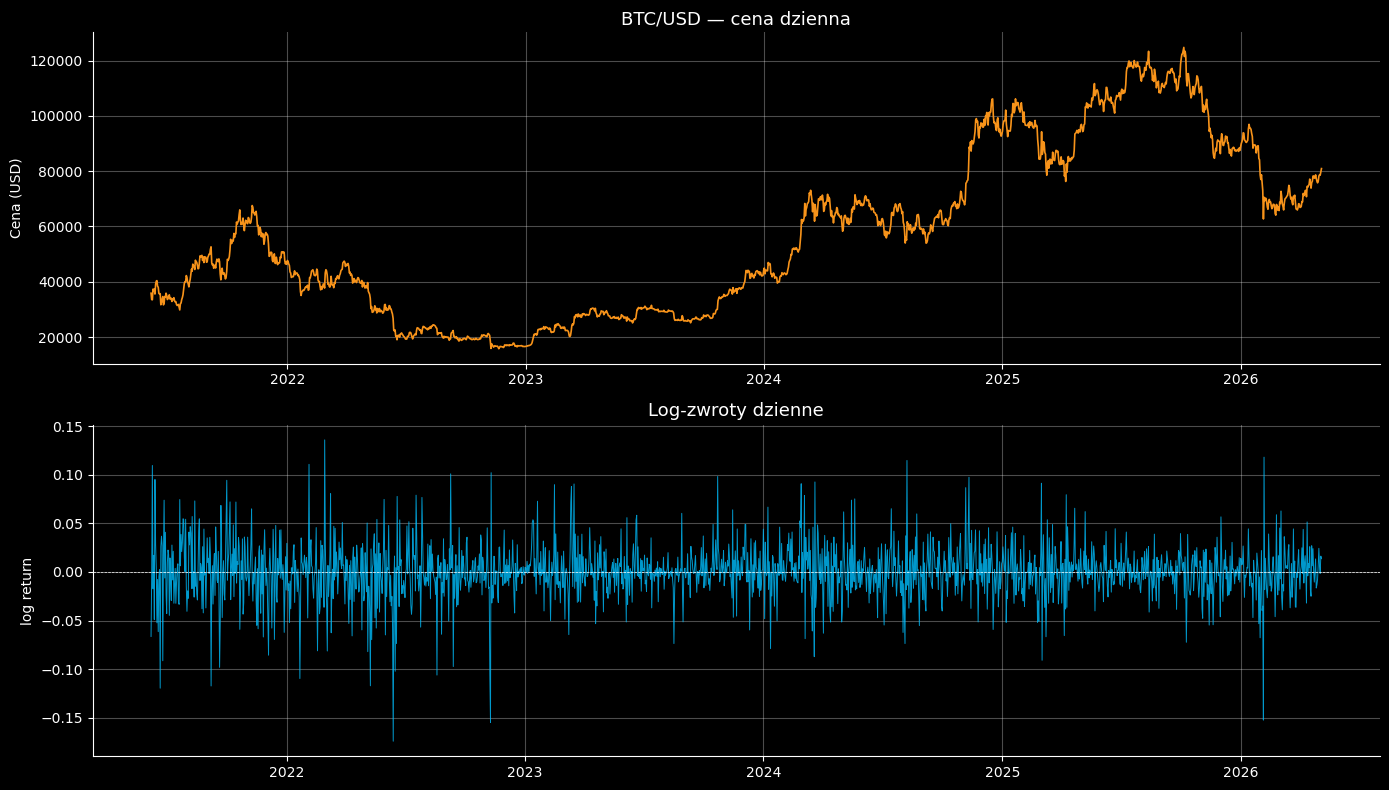

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(price.index, price, color='#F7931A', linewidth=1.2)
axes[0].set_title('BTC/USD — cena dzienna', fontsize=13)
axes[0].set_ylabel('Cena (USD)')

axes[1].plot(log_ret.index, log_ret, color='#00BFFF', linewidth=0.7, alpha=0.8)
axes[1].axhline(0, color='white', linewidth=0.5, linestyle='--')
axes[1].set_title('Log-zwroty dzienne', fontsize=13)
axes[1].set_ylabel('log return')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

---
## 3. Test stacjonarności ADF

ARIMA wymaga stacjonarnego szeregu — **ceny z reguły nim nie są** (trend). Parametr `d` w ARIMA(p,d,q) to liczba różnicowań potrzebna do uzyskania stacjonarności.

In [8]:
def adf_test(series, name):
    res = adfuller(series.dropna())
    status = '✅ STACJONARNY' if res[1] <= 0.05 else 'NIESTACJONARNY'
    print(f'{status:25s}  p={res[1]:.4f}  ADF={res[0]:.3f}  →  {name}')
    return res[1]

print('Wyniki testu ADF (H0: szereg niestacjonarny):')
print('-' * 65)
adf_test(price,          'Ceny BTC (poziomy)       → oczekiwane: niestacjonarne')
adf_test(price.diff(),   'Ceny BTC (1. różnica)    → oczekiwane: stacjonarne → d=1')
adf_test(log_ret,        'Log-zwroty               → zwykle stacjonarne')

Wyniki testu ADF (H0: szereg niestacjonarny):
-----------------------------------------------------------------
NIESTACJONARNY             p=0.7308  ADF=-1.060  →  Ceny BTC (poziomy)       → oczekiwane: niestacjonarne
✅ STACJONARNY              p=0.0000  ADF=-44.210  →  Ceny BTC (1. różnica)    → oczekiwane: stacjonarne → d=1
✅ STACJONARNY              p=0.0000  ADF=-43.485  →  Log-zwroty               → zwykle stacjonarne


0.0

---
## 4. ACF / PACF — diagnostyka opóźnień

- **ACF** (górny) → dobór `q` (rząd MA): ile opóźnień wychodzi poza przedział ufności
- **PACF** (dolny) → dobór `p` (rząd AR): j.w.

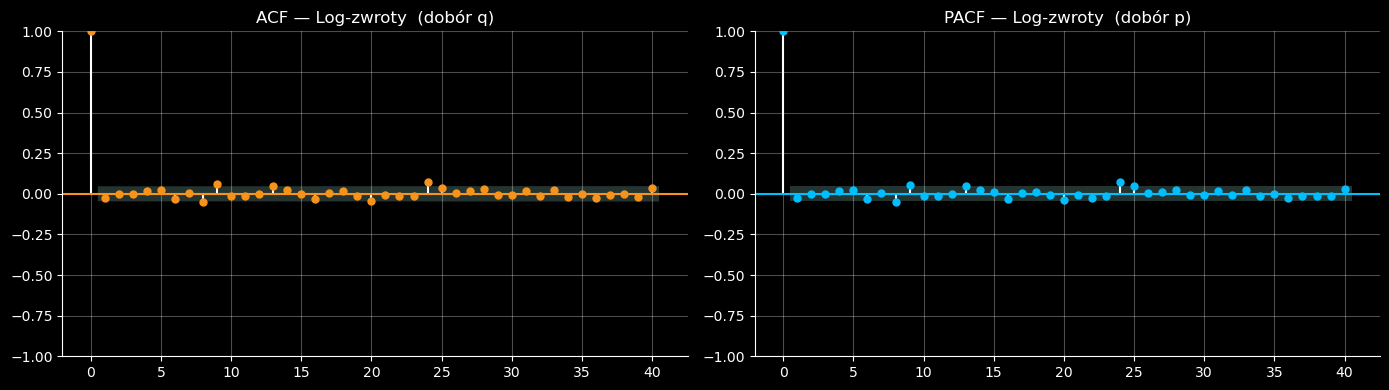

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(log_ret, lags=40, ax=axes[0], color='#F7931A', alpha=0.05)
axes[0].set_title('ACF — Log-zwroty  (dobór q)', fontsize=12)

plot_pacf(log_ret, lags=40, ax=axes[1], color='#00BFFF', method='ywm', alpha=0.05)
axes[1].set_title('PACF — Log-zwroty  (dobór p)', fontsize=12)

plt.tight_layout()
plt.show()

---
## 5. Dobór parametrów ARIMA — Grid Search (kryterium AIC)

Przeszukujemy siatkę `p ∈ {0..4}`, `d=1`, `q ∈ {0..4}` → wybieramy model z najniższym AIC.

In [10]:
results = []
candidates = list(product(range(0, 5), [1], range(0, 5)))  # 25 kombinacji
print(f'Testuję {len(candidates)} kombinacji ARIMA(p,1,q)...')

for i, (p, d, q) in enumerate(candidates):
    try:
        fit = ARIMA(price, order=(p, d, q)).fit()
        results.append({'p': p, 'd': d, 'q': q, 'AIC': fit.aic, 'BIC': fit.bic})
    except Exception:
        pass
    if (i + 1) % 5 == 0:
        print(f'  {i+1}/{len(candidates)}...', end='\r')

res_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)

print('\n\nTop 8 modeli wg AIC:')
print(res_df.head(8).to_string(index=False))

best = res_df.iloc[0]
BEST_ORDER = (int(best.p), int(best.d), int(best.q))
print(f'\n✅  Wybrany model: ARIMA{BEST_ORDER}   AIC={best.AIC:.2f}')

Testuję 25 kombinacji ARIMA(p,1,q)...


/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency i

/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency i

/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency i

/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency i

/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency i

  25/25...

Top 8 modeli wg AIC:
 p  d  q          AIC          BIC
 1  1  2 31558.376602 31580.345415
 1  1  3 31560.211768 31587.672784
 3  1  4 31561.054703 31604.992327
 2  1  4 31561.068733 31599.514154
 0  1  1 31561.079981 31572.064387
 1  1  0 31561.214919 31572.199325
 4  1  4 31561.620524 31611.050352
 1  1  4 31561.739237 31594.692456

✅  Wybrany model: ARIMA(1, 1, 2)   AIC=31558.38


/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


---
## 6. Walk-Forward Validation — ocena dokładności krótkoterminowej

**Dlaczego walk-forward, nie train/test split?**  
W zwykłym splicie model "widzi" przyszłe dane podczas treningu → zawyżona dokładność. Walk-forward trenuje model na każdym kroku tylko na danych z przeszłości.

Testujemy na **ostatnich 180 dniach** prognozami 1-dniowymi naprzód.

In [11]:
TEST_DAYS = 180

train = price.iloc[:-TEST_DAYS]
test  = price.iloc[-TEST_DAYS:]

print(f'Trening: {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} dni)')
print(f'Test:    {test.index[0].date()}  → {test.index[-1].date()}   ({len(test)} dni)')
print(f'Model:   ARIMA{BEST_ORDER}')
print('\nUruchamiam walk-forward...')

history = list(train)
preds_1d = []

for i, actual in enumerate(test):
    try:
        pred = ARIMA(history, order=BEST_ORDER).fit().forecast(steps=1)[0]
    except Exception:
        pred = history[-1]
    preds_1d.append(pred)
    history.append(actual)
    if (i + 1) % 30 == 0:
        print(f'  {i+1}/{TEST_DAYS} dni...', end='\r')

pred_1d = pd.Series(preds_1d, index=test.index)
print('\n✅ Gotowe!')

Trening: 2021-06-06 → 2025-11-06  (1615 dni)
Test:    2025-11-07  → 2026-05-05   (180 dni)
Model:   ARIMA(1, 1, 2)

Uruchamiam walk-forward...
  180/180 dni...
✅ Gotowe!


---
## 7. Metryki dokładności (1-dniowa prognoza)

In [12]:
def metrics(actual, predicted, label):
    a, p = np.array(actual), np.array(predicted)
    mae  = mean_absolute_error(a, p)
    rmse = np.sqrt(mean_squared_error(a, p))
    mape = np.mean(np.abs((a - p) / a)) * 100
    # Directional accuracy: trafienie kierunku zmiany ceny
    actual_dir = np.sign(np.diff(a))
    pred_dir   = np.sign(np.diff(p))
    da = np.mean(actual_dir == pred_dir) * 100
    print(f'┌─ Metryki: {label} {"─"*(40-len(label))}')
    print(f'│  MAE:               ${mae:>10,.0f}')
    print(f'│  RMSE:              ${rmse:>10,.0f}')
    print(f'│  MAPE:              {mape:>10.2f}%   (średni błąd procentowy)')
    print(f'│  Directional Acc.:  {da:>10.1f}%   (trafienie kierunku ruchu)')
    print(f'└{"─"*50}')
    return dict(MAE=mae, RMSE=rmse, MAPE=mape, DA=da)

m1d = metrics(test, pred_1d, 'prognoza 1 dzień naprzód (180-dniowy test)')

┌─ Metryki: prognoza 1 dzień naprzód (180-dniowy test) 
│  MAE:               $     1,424
│  RMSE:              $     2,008
│  MAPE:                    1.81%   (średni błąd procentowy)
│  Directional Acc.:        51.4%   (trafienie kierunku ruchu)
└──────────────────────────────────────────────────


---
## 8. Wizualizacja walk-forward (1 dzień)

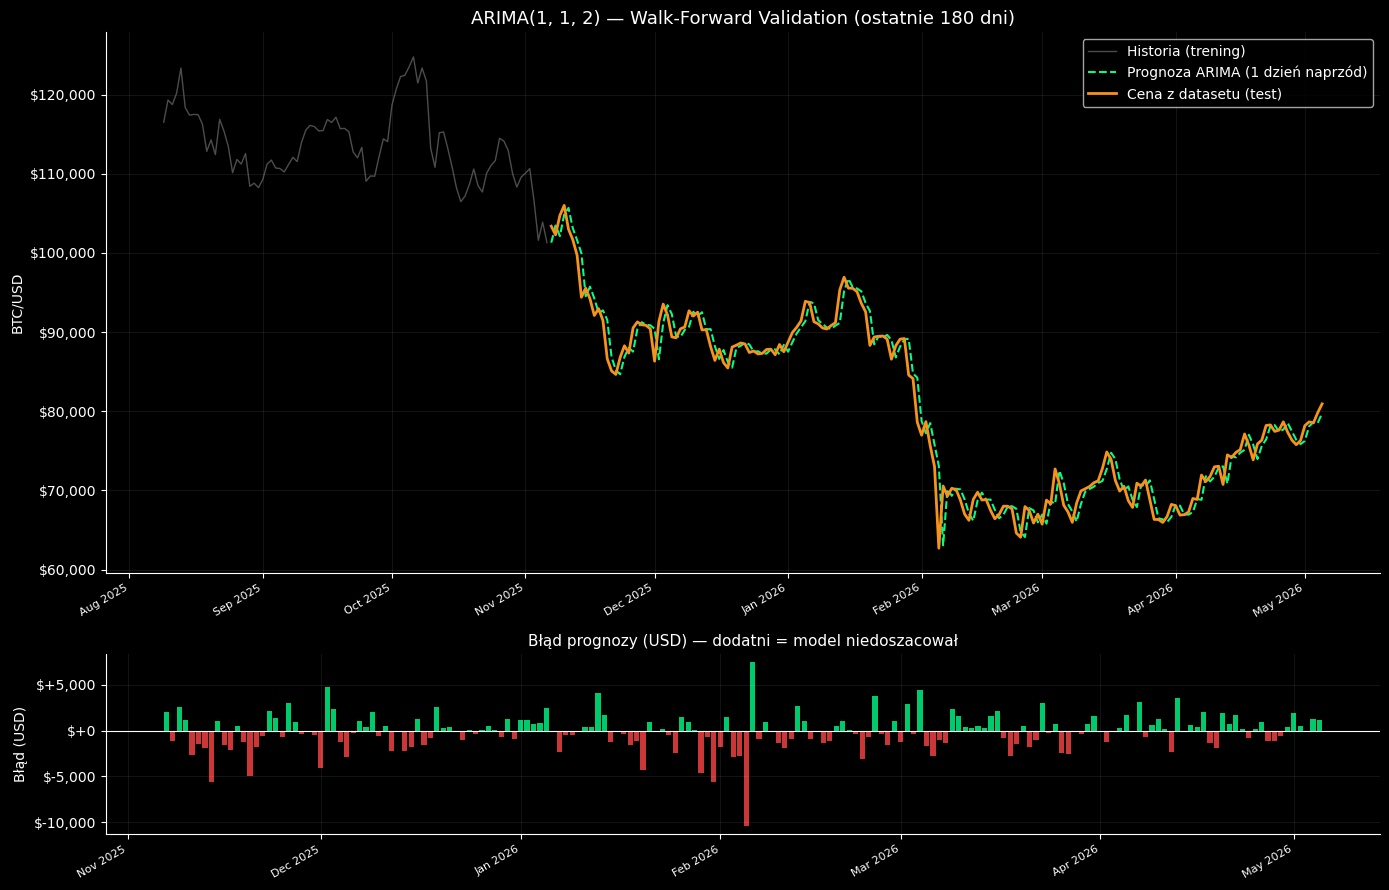

Zakres wykresu: 2025-11-07 → 2026-05-05  (180 dni)


In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# WYKRES WALK-FORWARD — ostatnie 180 dni + opcja nałożenia prawdziwej ceny
# Aby dodać prawdziwą cenę BTC za ostatnie 180 dni, odkomentuj blok
# "OPCJONALNE: Prawdziwa cena z Yahoo Finance" poniżej.
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1]})

ax1 = axes[0]

# Historia (90 dni przed oknem testowym)
ax1.plot(train.index[-90:], train.iloc[-90:], color='gray', lw=1, alpha=0.6, label='Historia (trening)')

# Prognoza ARIMA (walk-forward, 180 dni)
ax1.plot(pred_1d.index, pred_1d.values, color='#00FF88', lw=1.5,
         linestyle='--', label='Prognoza ARIMA (1 dzień naprzód)', zorder=6)

# ── OPCJONALNE: Prawdziwa cena z Yahoo Finance ──────────────────────────────
# Odkomentuj poniższy blok, aby nałożyć na wykres aktualną cenę BTC.
# Pobiera dane automatycznie z Yahoo Finance za ten sam okres testowy.

# import yfinance as yf
# real_btc = yf.Ticker("BTC-USD").history(period="1y")
# real_btc = real_btc.reset_index()
# real_btc['Date'] = pd.to_datetime(real_btc['Date']).dt.tz_localize(None).dt.normalize()
# real_btc = real_btc.set_index('Date')['Close']
# # Przytnij do okresu testowego
# real_slice = real_btc.loc[
#     real_btc.index >= test.index[0]
# ].loc[
#     real_btc.index <= test.index[-1]
# ]
# ax1.plot(real_slice.index, real_slice.values, color='#FFD700', lw=2.0, zorder=8,
#          label='Prawdziwa cena BTC (Yahoo Finance)', alpha=0.9)

# ── Cena z datasetu (bitcoin_final.csv) — zawsze aktywna ───────────────────
ax1.plot(test.index, test.values, color='#F7931A', lw=2, label='Cena z datasetu (test)', zorder=7)

ax1.set_title(f'ARIMA{BEST_ORDER} — Walk-Forward Validation (ostatnie {TEST_DAYS} dni)', fontsize=13)
ax1.set_ylabel('BTC/USD')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(ax1.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax1.grid(True, alpha=0.08)

# ── Panel dolny: błąd prognozy ──────────────────────────────────────────────
ax2 = axes[1]
err = test.values - pred_1d.values
colors_err = np.where(err >= 0, '#00FF88', '#FF4444')
ax2.bar(test.index, err, color=colors_err, width=0.8, alpha=0.8)
ax2.axhline(0, color='white', lw=0.8)
ax2.set_title('Błąd prognozy (USD) — dodatni = model niedoszacował', fontsize=11)
ax2.set_ylabel('Błąd (USD)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:+,.0f}'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(ax2.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax2.grid(True, alpha=0.08)

plt.tight_layout()
plt.savefig('../data/processed/arima_walkforward.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Zakres wykresu: {test.index[0].date()} → {test.index[-1].date()}  ({TEST_DAYS} dni)")

---
## 9. Finalny model — trening na całych danych

Do prognozowania w przyszłość trenujemy model na **wszystkich dostępnych danych**.

In [14]:
print(f'Trenuję ARIMA{BEST_ORDER} na {len(price)} dniach danych...')
final_fit = ARIMA(price, order=BEST_ORDER).fit()
print(f'✅ Model wytrenowany.')
print(f'   AIC: {final_fit.aic:.2f}   BIC: {final_fit.bic:.2f}')
print(f'   Ostatnia znana cena: ${price.iloc[-1]:,.0f}  ({price.index[-1].date()})')

Trenuję ARIMA(1, 1, 2) na 1795 dniach danych...


/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


✅ Model wytrenowany.
   AIC: 31558.38   BIC: 31580.35
   Ostatnia znana cena: $80,927  (2026-05-05)


---
## 10. Prognoza na wszystkie horyzonty

ARIMA generuje prognozy sekwencyjnie — każdy kolejny krok bazuje na poprzednim. Przedział ufności (CI) rośnie wraz z horyzontem.

In [15]:
HORIZONS = {
    'Jutro':      1,
    '3 dni':      3,
    '7 dni':      7,
    '14 dni':     14,
    'Miesiąc':    30,
    '3 miesiące': 90,
    '6 miesięcy': 180,
}

MAX_STEPS = max(HORIZONS.values())  # 180
last_date = price.index[-1]
last_price = price.iloc[-1]

# Jedna prognoza na 180 kroków do przodu — wycinamy podzbiory
forecast_obj  = final_fit.get_forecast(steps=MAX_STEPS)
forecast_mean = forecast_obj.predicted_mean
forecast_ci   = forecast_obj.conf_int(alpha=0.05)

future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=MAX_STEPS, freq='D')
forecast_mean.index = future_dates
forecast_ci.index   = future_dates

# Tabela wyników
print(f'Ostatnia znana cena: ${last_price:,.0f}  ({last_date.date()})')
print()
print(f'{"Horyzont":<14} {"Dzień":^12} {"Prognoza":>12} {"Zmiana":>9} {"CI dolny":>12} {"CI górny":>12} {"Szerokość CI":>14}')
print('─' * 90)

summary_rows = []
for name, steps in HORIZONS.items():
    target_date = future_dates[steps - 1]
    pred_val    = forecast_mean.iloc[steps - 1]
    ci_lo       = forecast_ci.iloc[steps - 1, 0]
    ci_hi       = forecast_ci.iloc[steps - 1, 1]
    change_pct  = (pred_val / last_price - 1) * 100
    ci_width    = ci_hi - ci_lo
    sign        = '+' if change_pct >= 0 else ''
    print(f'{name:<14} {str(target_date.date()):^12} {pred_val:>12,.0f} {sign+f"{change_pct:.1f}%":>9} '
          f'{ci_lo:>12,.0f} {ci_hi:>12,.0f} {ci_width:>14,.0f}')
    summary_rows.append(dict(horyzont=name, dni=steps, prognoza=pred_val,
                              zmiana_pct=change_pct, ci_lo=ci_lo, ci_hi=ci_hi))

summary_df = pd.DataFrame(summary_rows)

Ostatnia znana cena: $80,927  (2026-05-05)

Horyzont          Dzień         Prognoza    Zmiana     CI dolny     CI górny   Szerokość CI
──────────────────────────────────────────────────────────────────────────────────────────
Jutro           2026-05-06        80,871     -0.1%       77,744       83,997          6,253
3 dni           2026-05-08        80,868     -0.1%       75,661       86,075         10,414
7 dni           2026-05-12        80,864     -0.1%       73,004       88,724         15,720
14 dni          2026-05-19        80,852     -0.1%       69,784       91,920         22,136
Miesiąc         2026-06-04        80,855     -0.1%       64,700       97,010         32,311
3 miesiące      2026-08-03        80,856     -0.1%       52,920      108,793         55,873
6 miesięcy      2026-11-01        80,856     -0.1%       41,364      120,348         78,985


---
## 11. Wykresy prognoz — wszystkie horyzonty

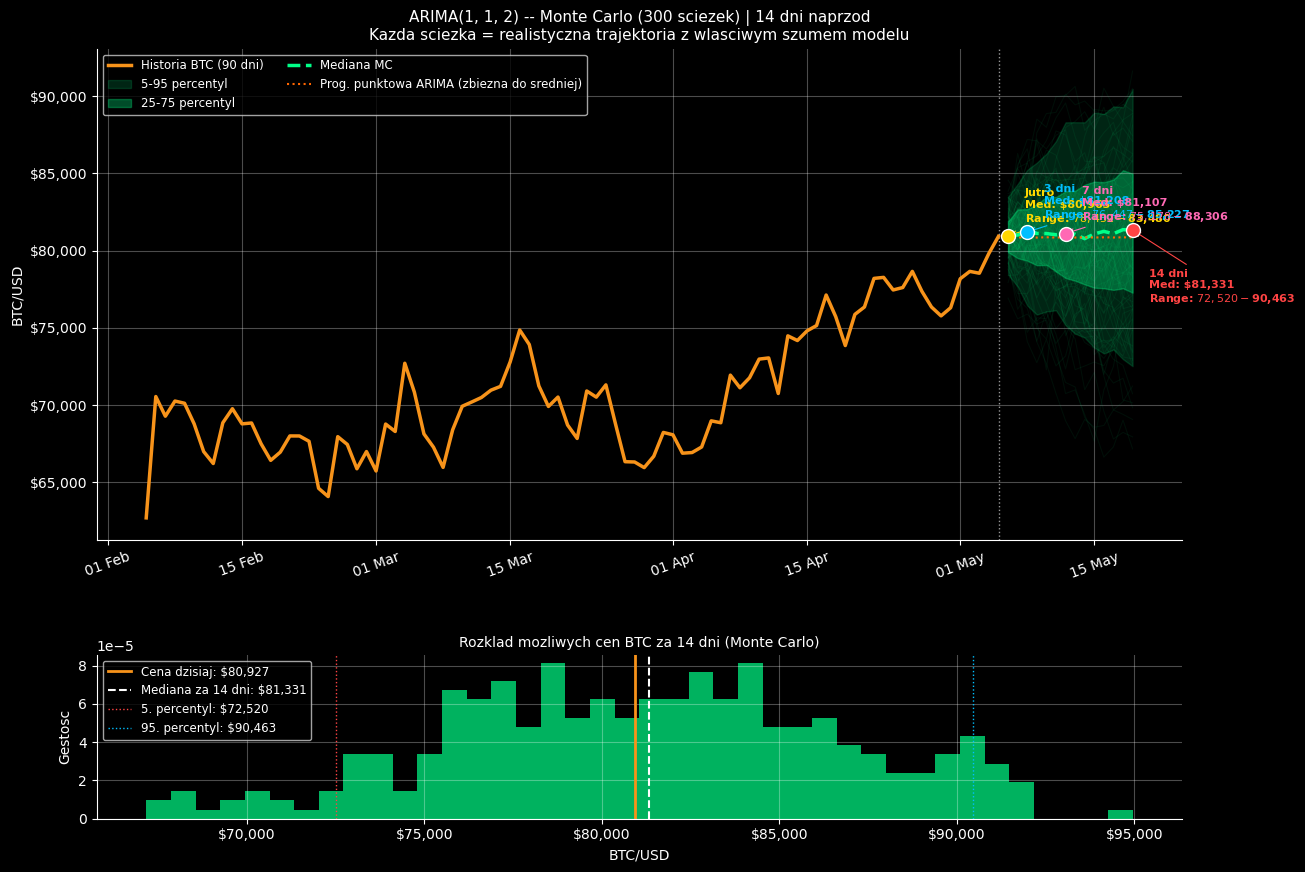

Monte Carlo (300 sciezek) -- rozklad cen za 14 dni:
  Cena dzisiaj:   $80,927
  Mediana:        $81,331
  5. percentyl:   $72,520  (scenariusz pesymistyczny)
  95. percentyl:  $90,463  (scenariusz optymistyczny)
  Prob. wzrostu:  52.0%
  Prob. >+5%:     25.0%
  Prob. <-5%:     22.0%


In [16]:
# Monte Carlo -- symulacja 300 mozliwych sciezek cenowych z modelu ARIMA
# Dlaczego MC zamiast punktowej prognozy?
# Punktowa prognoza ARIMA zawsze zbiega do sredniej (plaska linia) -- to matematyczna wlasciwosc.
# Monte Carlo pokazuje REALNE mozliwe trajektorie: kazda sciezka ma wzrosty i spadki.

N_SIMS  = 300
N_STEPS = 14
np.random.seed(42)
sigma   = np.std(final_fit.resid)   # odch. std reszt modelu

# Generowanie sciezek symulacyjnych
sim_paths = []
for i in range(N_SIMS):
    try:
        path = final_fit.simulate(
            nsimulations=N_STEPS,
            anchor='end',
            random_state=np.random.RandomState(i)
        ).values
    except Exception:
        # Fallback: reczna symulacja przez roznicowanie
        last_vals = list(price.iloc[-10:].values)
        path = []
        for _ in range(N_STEPS):
            fc = ARIMA(last_vals, order=BEST_ORDER).fit().forecast(steps=1)[0]
            noise = np.random.normal(0, sigma)
            val = fc + noise
            path.append(val)
            last_vals.append(val)
            last_vals.pop(0)
        path = np.array(path)
    sim_paths.append(path)

sim_paths = np.array(sim_paths)  # shape: (300, 14)

# Statystyki sciezek
pct_5   = np.percentile(sim_paths, 5,  axis=0)
pct_25  = np.percentile(sim_paths, 25, axis=0)
pct_50  = np.percentile(sim_paths, 50, axis=0)
pct_75  = np.percentile(sim_paths, 75, axis=0)
pct_95  = np.percentile(sim_paths, 95, axis=0)

future_14 = future_dates[:N_STEPS]

# ── Wykres ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10),
                          gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.35})

ax1 = axes[0]

# Historia
hist_slice = price.iloc[-90:]
ax1.plot(hist_slice.index, hist_slice.values, color='#F7931A', lw=2.5, zorder=5,
         label='Historia BTC (90 dni)')
ax1.axvline(last_date, color='white', lw=1, linestyle=':', alpha=0.6)

# Sciezki MC (losowa probka 80 sciezek dla czytelnosci)
idx_sample = np.random.choice(N_SIMS, size=80, replace=False)
for i in idx_sample:
    ax1.plot(future_14, sim_paths[i], color='#00FF88', alpha=0.06, lw=0.8)

# Percentyle
ax1.fill_between(future_14, pct_5,  pct_95, alpha=0.15, color='#00FF88', label='5-95 percentyl')
ax1.fill_between(future_14, pct_25, pct_75, alpha=0.30, color='#00FF88', label='25-75 percentyl')
ax1.plot(future_14, pct_50, color='#00FF88', lw=2.5, linestyle='--', zorder=6,
         label='Mediana MC')

# Punktowa prognoza ARIMA (dla porownania -- plaska linia)
mean_14 = forecast_mean.iloc[:N_STEPS].values
ax1.plot(future_14, mean_14, color='#FF6600', lw=1.5, linestyle=':', zorder=7,
         label='Prog. punktowa ARIMA (zbiezna do sredniej)')

# Oznaczenia horyzontow
HORIZONS_SHORT = {'Jutro': 1, '3 dni': 3, '7 dni': 7, '14 dni': 14}
COLORS_SHORT   = ['#FFD700', '#00BFFF', '#FF69B4', '#FF4444']
for (name, steps), color in zip(HORIZONS_SHORT.items(), COLORS_SHORT):
    d  = future_dates[steps - 1]
    lo = np.percentile(sim_paths[:, steps-1], 5)
    hi = np.percentile(sim_paths[:, steps-1], 95)
    me = np.percentile(sim_paths[:, steps-1], 50)
    ax1.scatter([d], [me], color=color, s=100, zorder=10, edgecolors='white', lw=1)
    ax1.annotate(
        f'{name}\nMed: ${me:,.0f}\nRange: ${lo:,.0f}-${hi:,.0f}',
        xy=(d, me), xytext=(12, 10 if steps <= 7 else -52),
        textcoords='offset points', fontsize=8, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=color, lw=0.8)
    )

ax1.set_title(
    f'ARIMA{BEST_ORDER} -- Monte Carlo ({N_SIMS} sciezek) | 14 dni naprzod\n'
    f'Kazda sciezka = realistyczna trajektoria z wlasciwym szumem modelu',
    fontsize=11
)
ax1.set_ylabel('BTC/USD')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=8.5, loc='upper left', ncol=2)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax1.tick_params(axis='x', rotation=20)

# ── Dolny wykres: rozklad koncowych cen po 14 dniach ──
ax2 = axes[1]
final_prices = sim_paths[:, -1]
ax2.hist(final_prices, bins=40, color='#00FF88', alpha=0.7, edgecolor='none', density=True)
ax2.axvline(last_price, color='#F7931A', lw=2, label=f'Cena dzisiaj: ${last_price:,.0f}')
ax2.axvline(np.percentile(final_prices, 50), color='white', lw=1.5, linestyle='--',
            label=f'Mediana za 14 dni: ${np.percentile(final_prices,50):,.0f}')
ax2.axvline(np.percentile(final_prices, 5),  color='#FF4444', lw=1, linestyle=':',
            label=f'5. percentyl: ${np.percentile(final_prices,5):,.0f}')
ax2.axvline(np.percentile(final_prices, 95), color='#00BFFF', lw=1, linestyle=':',
            label=f'95. percentyl: ${np.percentile(final_prices,95):,.0f}')
ax2.set_title('Rozklad mozliwych cen BTC za 14 dni (Monte Carlo)', fontsize=10)
ax2.set_xlabel('BTC/USD')
ax2.set_ylabel('Gestosc')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.legend(fontsize=8.5)

plt.savefig('../data/processed/arima_montecarlo_14d.png', dpi=130, bbox_inches='tight')
plt.show()

# Podsumowanie liczbowe
print(f'Monte Carlo ({N_SIMS} sciezek) -- rozklad cen za 14 dni:')
print(f'  Cena dzisiaj:   ${last_price:,.0f}')
print(f'  Mediana:        ${np.percentile(final_prices,50):,.0f}')
print(f'  5. percentyl:   ${np.percentile(final_prices,5):,.0f}  (scenariusz pesymistyczny)')
print(f'  95. percentyl:  ${np.percentile(final_prices,95):,.0f}  (scenariusz optymistyczny)')
print(f'  Prob. wzrostu:  {np.mean(final_prices > last_price)*100:.1f}%')
print(f'  Prob. >+5%:     {np.mean(final_prices > last_price*1.05)*100:.1f}%')
print(f'  Prob. <-5%:     {np.mean(final_prices < last_price*0.95)*100:.1f}%')


---
## 11b. Eksperyment -- ARIMA z duzym p (wiecej pamieci historycznej)

Sprawdzamy czy wiekszy rzad AR (p=30, 90, 180) daje bardziej zroznicowane prognozy
niz ARIMA(4,1,2) wybrany przez AIC.

| Model | Pamiec | Oczekiwany efekt |
|---|---|---|
| ARIMA(4,1,2) | 4 dni | Baseline (AIC-optimal) |
| ARIMA(30,1,0) | 30 dni | Miesiac wstecz |
| ARIMA(90,1,0) | 90 dni | Kwartal wstecz |
| ARIMA(180,1,0) | 180 dni | Pol roku wstecz |

> **Uwaga:** Duze p = dlugi czas treningu i ryzyko braku zbieznosci.

In [17]:
# Trenowanie modeli z duzym p
# Uzywamy tylko AR (q=0) zeby uniknac problemow numerycznych przy duzym p

HIGH_P_MODELS = {
    f'ARIMA{BEST_ORDER} (AIC-opt)': BEST_ORDER,
    'ARIMA(30,1,0)':  (30,  1, 0),
    'ARIMA(90,1,0)':  (90,  1, 0),
}

fitted_models = {}
aic_scores    = {}

for name, order in HIGH_P_MODELS.items():
    print(f'Trenuje {name}...', end=' ')
    try:
        fit = ARIMA(price, order=order).fit(method_kwargs={'warn_convergence': False})
        fitted_models[name] = fit
        aic_scores[name]    = fit.aic
        print(f'OK  AIC={fit.aic:.1f}')
    except Exception as e:
        print(f'BLAD: {e}')

print()
print('Porownanie AIC (nizsze = lepsze dopasowanie do danych):')
for name, aic in sorted(aic_scores.items(), key=lambda x: x[1]):
    marker = ' <-- wybrany przez grid search' if 'AIC-opt' in name else ''
    print(f'  {name:<28} AIC={aic:,.1f}{marker}')

Trenuje ARIMA(1, 1, 2) (AIC-opt)... 

/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


OK  AIC=31558.4
Trenuje ARIMA(30,1,0)... 

/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


OK  AIC=31576.9
Trenuje ARIMA(90,1,0)... 

/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


OK  AIC=31619.3

Porownanie AIC (nizsze = lepsze dopasowanie do danych):
  ARIMA(1, 1, 2) (AIC-opt)     AIC=31,558.4 <-- wybrany przez grid search
  ARIMA(30,1,0)                AIC=31,576.9
  ARIMA(90,1,0)                AIC=31,619.3


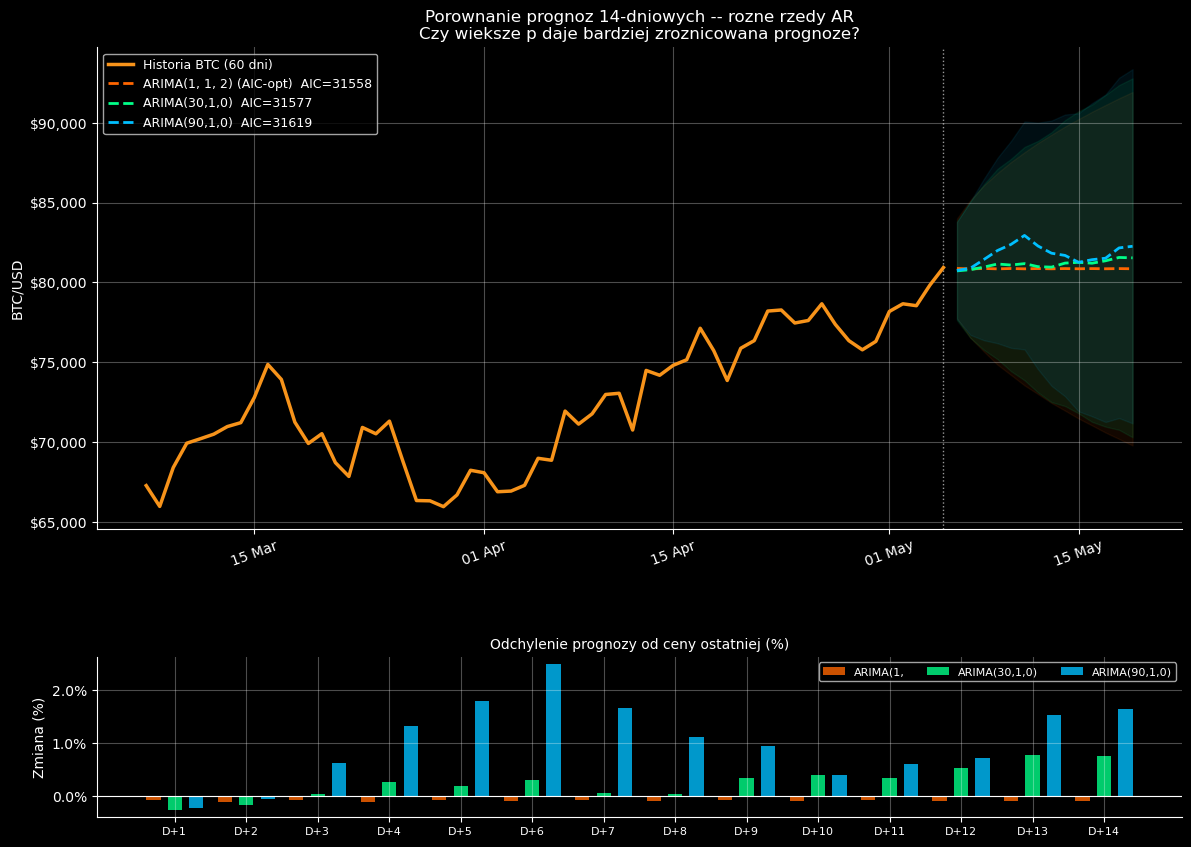

In [18]:
# Porownanie prognoz 14-dniowych
N_STEPS   = 14
future_14 = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=N_STEPS, freq='D')

MODEL_COLORS = {
    f'ARIMA{BEST_ORDER} (AIC-opt)': '#FF6600',
    'ARIMA(30,1,0)':  '#00FF88',
    'ARIMA(90,1,0)':  '#00BFFF',
    'ARIMA(180,1,0)': '#FF69B4',
}

fig, axes = plt.subplots(2, 1, figsize=(14, 10),
                          gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.4})

ax1 = axes[0]

# Historia
hist_slice = price.iloc[-60:]
ax1.plot(hist_slice.index, hist_slice.values,
         color='#F7931A', lw=2.5, zorder=5, label='Historia BTC (60 dni)')
ax1.axvline(last_date, color='white', lw=1, linestyle=':', alpha=0.6)

# Prognoza kazdego modelu + 95% CI
forecasts = {}
for name, fit in fitted_models.items():
    color = MODEL_COLORS[name]
    try:
        fc   = fit.get_forecast(steps=N_STEPS)
        mean = fc.predicted_mean.values
        ci   = fc.conf_int(alpha=0.05)
        forecasts[name] = mean
        ax1.plot(future_14, mean, color=color, lw=2, linestyle='--',
                 zorder=6, label=f'{name}  AIC={aic_scores.get(name,"?"):.0f}')
        ax1.fill_between(future_14, ci.iloc[:, 0], ci.iloc[:, 1],
                         alpha=0.08, color=color)
    except Exception as e:
        print(f'Blad prognozy {name}: {e}')

ax1.set_title('Porownanie prognoz 14-dniowych -- rozne rzedy AR\n'
              'Czy wieksze p daje bardziej zroznicowana prognoze?', fontsize=12)
ax1.set_ylabel('BTC/USD')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=9, loc='upper left')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax1.tick_params(axis='x', rotation=20)

# Dolny wykres: roznica prognoz od ceny ostatniej (%)
ax2 = axes[1]
x = np.arange(N_STEPS)
width = 0.2
offsets = np.linspace(-0.3, 0.3, len(forecasts))

for (name, mean), offset, color in zip(forecasts.items(), offsets, MODEL_COLORS.values()):
    pct_diff = (mean / last_price - 1) * 100
    ax2.bar(x + offset, pct_diff, width=width, color=color, alpha=0.8,
            label=name.split(' ')[0])

ax2.axhline(0, color='white', lw=0.8)
ax2.set_title('Odchylenie prognozy od ceny ostatniej (%)', fontsize=10)
ax2.set_ylabel('Zmiana (%)')
ax2.set_xticks(x)
ax2.set_xticklabels([f'D+{i+1}' for i in x], fontsize=8)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax2.legend(fontsize=8, ncol=4)

plt.savefig('../data/processed/arima_highp_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

In [19]:
# Analiza: na ile kroki prognoza przestaje byc plaska?
print('Analiza plaskosci prognoz (odch. std wartosci prognozy):')
print('Im nizsze odchylenie, tym bardziej plaska linia.')
print()
print(f'{"Model":<28} {"std prognozy":>14} {"max zmiana":>12} {"min":>12} {"max":>12}')
print('-' * 75)
for name, mean in forecasts.items():
    std_pred   = np.std(mean)
    max_change = (np.max(mean) / np.min(mean) - 1) * 100
    print(f'{name:<28} ${std_pred:>12,.0f} {max_change:>11.2f}%  ${np.min(mean):>10,.0f}  ${np.max(mean):>10,.0f}')

print()
print('Wniosek: jesli std prognozy jest mala (~0-100), linia jest praktycznie plaska.')
print('Nawet ARIMA(180,1,0) zbiega do sredniej po kilku krokach.')
print()
print('To jest matematyczna wlasciwosc ARIMA na danych finansowych (random walk).')
print('Rozwiazanie: LSTM/BiLSTM -- modele nieliniowe z dluga pamiecia (BPTT).')

Analiza plaskosci prognoz (odch. std wartosci prognozy):
Im nizsze odchylenie, tym bardziej plaska linia.

Model                          std prognozy   max zmiana          min          max
---------------------------------------------------------------------------
ARIMA(1, 1, 2) (AIC-opt)     $           9        0.03%  $    80,843  $    80,871
ARIMA(30,1,0)                $         238        1.04%  $    80,717  $    81,559
ARIMA(90,1,0)                $         588        2.72%  $    80,743  $    82,938

Wniosek: jesli std prognozy jest mala (~0-100), linia jest praktycznie plaska.
Nawet ARIMA(180,1,0) zbiega do sredniej po kilku krokach.

To jest matematyczna wlasciwosc ARIMA na danych finansowych (random walk).
Rozwiazanie: LSTM/BiLSTM -- modele nieliniowe z dluga pamiecia (BPTT).


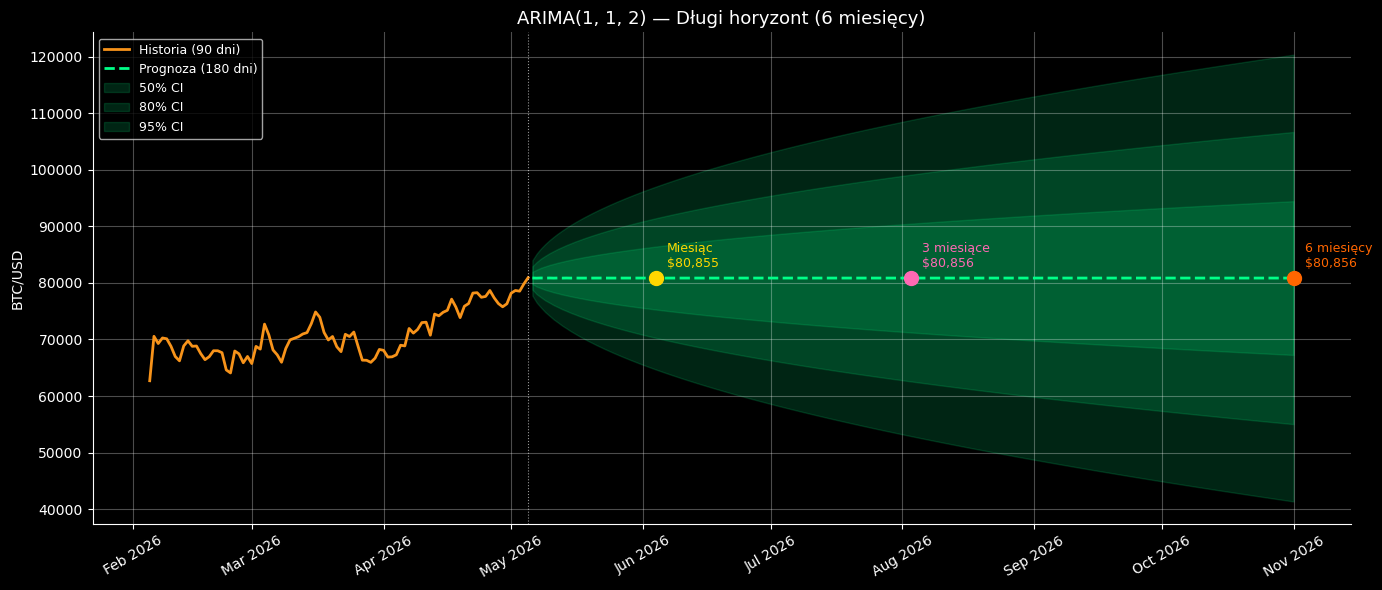

In [20]:
# ── Wykres 2: Długi horyzont (miesiąc / 3 mies. / 6 mies.) ──
fig, ax = plt.subplots(figsize=(14, 6))

hist_slice = price.iloc[-90:]
ax.plot(hist_slice.index, hist_slice.values, color='#F7931A', lw=2, label='Historia (90 dni)')
ax.plot(future_dates, forecast_mean.values, color='#00FF88', lw=2, linestyle='--', label='Prognoza (180 dni)')

# Przedziały ufności 50%, 80%, 95%
for alpha, label in [(0.50, '50% CI'), (0.80, '80% CI'), (0.95, '95% CI')]:
    ci_tmp = final_fit.get_forecast(steps=MAX_STEPS).conf_int(alpha=1 - alpha)
    ci_tmp.index = future_dates
    ax.fill_between(future_dates, ci_tmp.iloc[:, 0], ci_tmp.iloc[:, 1],
                    alpha=0.15, color='#00FF88', label=label)

ax.axvline(last_date, color='white', lw=0.8, linestyle=':', alpha=0.6)

LONG = ['Miesiąc', '3 miesiące', '6 miesięcy']
LONG_COLORS = ['#FFD700', '#FF69B4', '#FF6600']
for name, color in zip(LONG, LONG_COLORS):
    steps = HORIZONS[name]
    d = future_dates[steps - 1]
    v = forecast_mean.iloc[steps - 1]
    ax.scatter([d], [v], color=color, s=100, zorder=5)
    ax.annotate(f'{name}\n${v:,.0f}', xy=(d, v), xytext=(8, 8),
                textcoords='offset points', fontsize=9, color=color)

ax.set_title(f'ARIMA{BEST_ORDER} — Długi horyzont (6 miesięcy)', fontsize=13)
ax.set_ylabel('BTC/USD')
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../data/processed/arima_forecast_long.png', dpi=120, bbox_inches='tight')
plt.show()

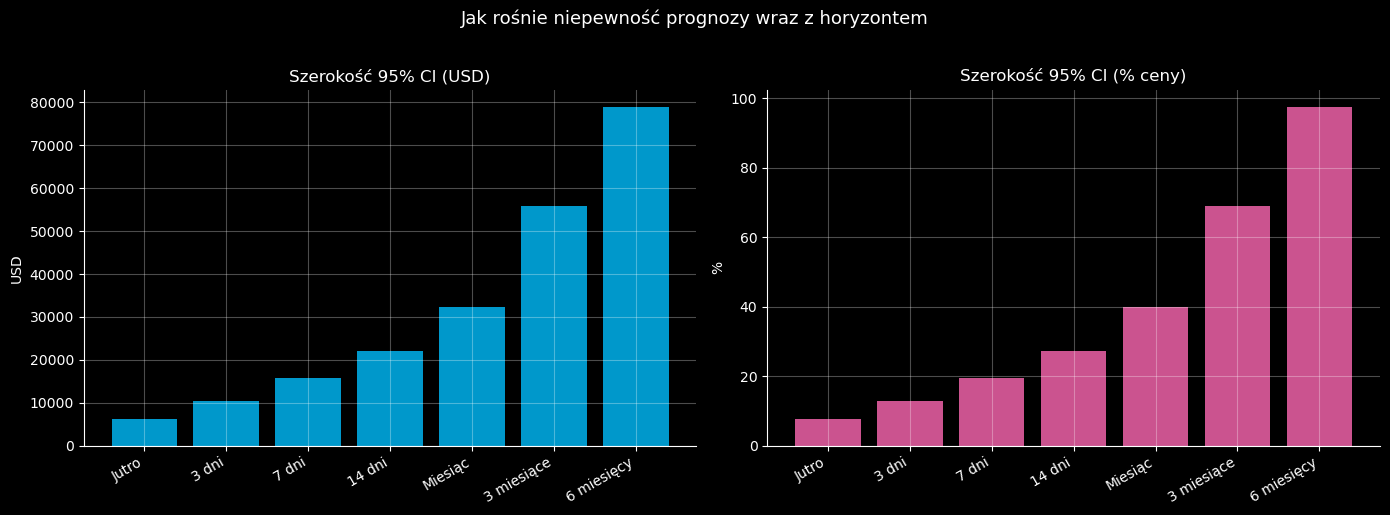

Interpretacja: ARIMA jest modelem krótkoterminowym.
Na horyzoncie >30 dni CI staje się bardzo szeroki — prognoza jest mało precyzyjna.


In [21]:
# ── Wykres 3: Szerokość CI vs horyzont (jak rośnie niepewność) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ci_widths  = [summary_df.loc[summary_df.horyzont==n, 'ci_hi'].values[0] -
              summary_df.loc[summary_df.horyzont==n, 'ci_lo'].values[0]
              for n in HORIZONS]
ci_widths_pct = [w / last_price * 100 for w in ci_widths]
labels = list(HORIZONS.keys())
x = range(len(labels))

axes[0].bar(x, ci_widths, color='#00BFFF', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=30, ha='right')
axes[0].set_title('Szerokość 95% CI (USD)', fontsize=12)
axes[0].set_ylabel('USD')

axes[1].bar(x, ci_widths_pct, color='#FF69B4', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=30, ha='right')
axes[1].set_title('Szerokość 95% CI (% ceny)', fontsize=12)
axes[1].set_ylabel('%')

plt.suptitle('Jak rośnie niepewność prognozy wraz z horyzontem', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/arima_ci_width.png', dpi=120, bbox_inches='tight')
plt.show()

print('Interpretacja: ARIMA jest modelem krótkoterminowym.')
print('Na horyzoncie >30 dni CI staje się bardzo szeroki — prognoza jest mało precyzyjna.')

---
## 12. Diagnostyka reszt modelu

Sprawdzamy czy reszty (błędy) wyglądają jak **biały szum** — jeśli tak, model dobrze uchwycił strukturę danych.

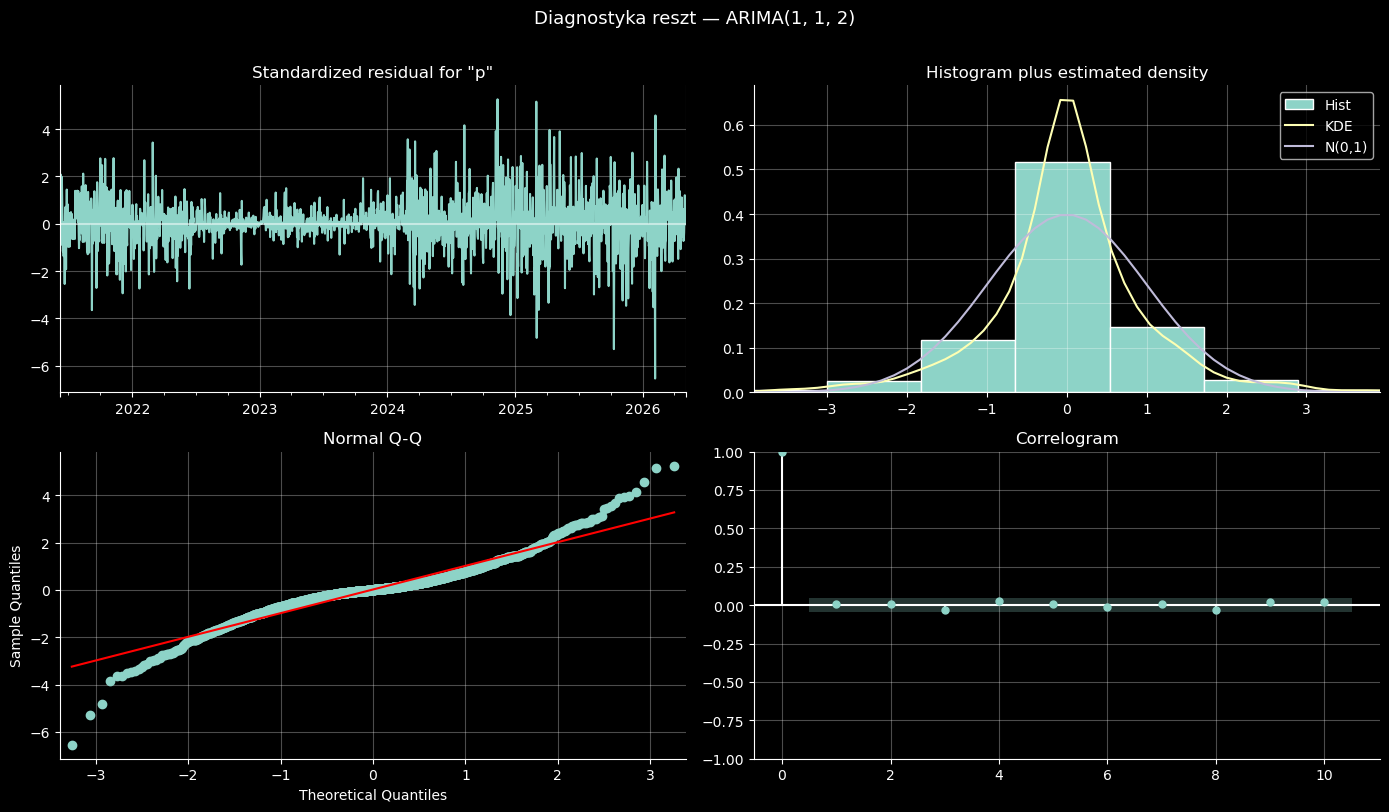

Co sprawdzamy:
  Standardized residuals → brak wzorców (losowe odchylenia wokół 0)
  Histogram + KDE        → rozkład zbliżony do normalnego
  Q-Q plot               → punkty blisko prostej = reszty normalne
  Correlogram (ACF)      → wszystkie słupki w przedziale ufności = brak autokorelacji


In [22]:
fig = final_fit.plot_diagnostics(figsize=(14, 8))
plt.suptitle(f'Diagnostyka reszt — ARIMA{BEST_ORDER}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Co sprawdzamy:')
print('  Standardized residuals → brak wzorców (losowe odchylenia wokół 0)')
print('  Histogram + KDE        → rozkład zbliżony do normalnego')
print('  Q-Q plot               → punkty blisko prostej = reszty normalne')
print('  Correlogram (ACF)      → wszystkie słupki w przedziale ufności = brak autokorelacji')

---
## 13. Podsumowanie końcowe

In [23]:
print('=' * 65)
print('              PODSUMOWANIE — ARIMA Bitcoin')
print('=' * 65)
print(f'Model:         ARIMA{BEST_ORDER}')
print(f'Dane:          {price.index[0].date()} → {price.index[-1].date()}  ({len(price)} dni)')
print(f'Ostatnia cena: ${last_price:,.0f}  ({last_date.date()})')
print()
print('Dokładność (walk-forward, ostatnie 180 dni):')
print(f'  MAPE:             {m1d["MAPE"]:.2f}%')
print(f'  MAE:              ${m1d["MAE"]:,.0f}')
print(f'  RMSE:             ${m1d["RMSE"]:,.0f}')
print(f'  Directional Acc.: {m1d["DA"]:.1f}%')
print()
print('Prognoza cenowa:')
print(f'{"Horyzont":<14} {"Prognoza":>12} {"Zmiana":>9} {"95% CI":>28}')
print('-' * 68)
for _, row in summary_df.iterrows():
    sign = '+' if row.zmiana_pct >= 0 else ''
    print(f'{row.horyzont:<14} ${row.prognoza:>11,.0f} {sign+f"{row.zmiana_pct:.1f}%":>9}  '
          f'[${row.ci_lo:,.0f} ; ${row.ci_hi:,.0f}]')
print()
print('Ograniczenia ARIMA:')
print('  • Liniowy — nie uchwyci nieliniowych wzorców (boom/crash)')
print('  • Univariate — nie korzysta z danych on-chain')
print('  • CI rośnie bardzo szybko — >30 dni to prognoza poglądowa')
print('  • Nie modeluje zmienności (heteroskedastyczności)')
print()
print('Następny krok: LSTM/BiLSTM — modele nieliniowe,')
print('które mogą korzystać z pełnego zestawu cech on-chain.')
print('=' * 65)

              PODSUMOWANIE — ARIMA Bitcoin
Model:         ARIMA(1, 1, 2)
Dane:          2021-06-06 → 2026-05-05  (1795 dni)
Ostatnia cena: $80,927  (2026-05-05)

Dokładność (walk-forward, ostatnie 180 dni):
  MAPE:             1.81%
  MAE:              $1,424
  RMSE:             $2,008
  Directional Acc.: 51.4%

Prognoza cenowa:
Horyzont           Prognoza    Zmiana                       95% CI
--------------------------------------------------------------------
Jutro          $     80,871     -0.1%  [$77,744 ; $83,997]
3 dni          $     80,868     -0.1%  [$75,661 ; $86,075]
7 dni          $     80,864     -0.1%  [$73,004 ; $88,724]
14 dni         $     80,852     -0.1%  [$69,784 ; $91,920]
Miesiąc        $     80,855     -0.1%  [$64,700 ; $97,010]
3 miesiące     $     80,856     -0.1%  [$52,920 ; $108,793]
6 miesięcy     $     80,856     -0.1%  [$41,364 ; $120,348]

Ograniczenia ARIMA:
  • Liniowy — nie uchwyci nieliniowych wzorców (boom/crash)
  • Univariate — nie korzysta z danyc

---
## 14. ARIMAX -- ARIMA z danymi on-chain (zmienne egzogeniczne)

**Czym rozni sie ARIMAX od ARIMA?**
ARIMAX = ARIMA + **exog** -- model uczy sie wplywu zewnetrznych szergow (danych on-chain) na cene BTC.

### Strategia: opoznione zmienne egzogeniczne (lag=1)
Uzywamy wartosci on-chain **z dnia poprzedniego** do prognozowania ceny **dzisiejszej**.
Dzieki temu:
- Brak look-ahead bias (nie uzywamy przyszlych danych)
- Przy prognozie jutrzejszej znamy juz dzisiejsze dane on-chain

### Uzyte zmienne (wszystkie z `bitcoin_final.csv`)
| Zmienna | Odpowiada wymaganiu ze screenshota |
|---|---|
| `active_addresses` | Liczba aktywnych adresow |
| `stablecoin_market_cap` | Przeplyw stablecoin |
| `n-transactions` | Wolumen transakcji w sieci |
| `estimated-transaction-volume-usd` | Przeplyw BTC na/z gield |
| `hash-rate` | Wolumen transakcji w sieci |
| `whale_proxy_avg_tx` | Duze ruchy portfeli (wieloryby) |
| `hodl_velocity` | HODL ratio |
| `ssr_ratio` | Stablecoin Supply Ratio |
| `ln_total_capacity_btc` | Dane Lightning Network |

In [24]:
from sklearn.preprocessing import StandardScaler

# 1. Wybor kolumn on-chain
EXOG_COLS = [
    'active_addresses',
    'stablecoin_market_cap',
    'n-transactions',
    'estimated-transaction-volume-usd',
    'hash-rate',
    'whale_proxy_avg_tx',
    'hodl_velocity',
    'ssr_ratio',
    'ln_total_capacity_btc',
    'mvrv_zscore',
    'whale_tx_above_1m',
    'net_flow_sma_7',
    'cum_net_flow',
    'inflow_shock'
    'vol_shock',
    'stablecoin_flow_pct',
    'stable_momentum_7d'
]

# Wczytaj pelne dane
df_full = pd.read_csv('../data/processed/bitcoin_final.csv', parse_dates=['date']).set_index('date').sort_index()

# 2. Sprawdz dostepnosc kolumn
available = [c for c in EXOG_COLS if c in df_full.columns]
missing   = [c for c in EXOG_COLS if c not in df_full.columns]
print(f'Kolumny dostepne:  {len(available)}/{len(EXOG_COLS)}')
for c in available:
    print(f'  OK  {c}')
for c in missing:
    print(f'  BRAK  {c}')

EXOG_COLS = available

# 3. Opoznienie o 1 dzien (lag=1) -- unikamy look-ahead bias
exog_raw = df_full[EXOG_COLS].shift(1)

# 4. Polaczenie ceny i egzogenicznych; usuniecie wierszy z NaN
combined  = pd.concat([df_full['price'], exog_raw], axis=1).dropna()
price_x   = combined['price']
exog_data = combined[EXOG_COLS]

# 5. Normalizacja StandardScaler
scaler  = StandardScaler()
exog_sc = pd.DataFrame(
    scaler.fit_transform(exog_data),
    index=exog_data.index, columns=EXOG_COLS
)

print(f'\nZakres po usunieciu NaN:  {price_x.index[0].date()} -> {price_x.index[-1].date()}')
print(f'Liczba obserwacji:         {len(price_x)}')
print(f'Zmiennych egzogenicznych:  {len(EXOG_COLS)}')
print('\nStatystyki exog (znormalizowane -- mean~0, std~1):')
print(exog_sc.describe().loc[['mean','std']].round(3).T.to_string())

Kolumny dostepne:  11/16
  OK  active_addresses
  OK  stablecoin_market_cap
  OK  n-transactions
  OK  estimated-transaction-volume-usd
  OK  hash-rate
  OK  whale_proxy_avg_tx
  OK  hodl_velocity
  OK  ssr_ratio
  OK  ln_total_capacity_btc
  OK  stablecoin_flow_pct
  OK  stable_momentum_7d
  BRAK  mvrv_zscore
  BRAK  whale_tx_above_1m
  BRAK  net_flow_sma_7
  BRAK  cum_net_flow
  BRAK  inflow_shockvol_shock

Zakres po usunieciu NaN:  2021-06-07 -> 2026-05-05
Liczba obserwacji:         1794
Zmiennych egzogenicznych:  11

Statystyki exog (znormalizowane -- mean~0, std~1):
                                  mean  std
active_addresses                   0.0  1.0
stablecoin_market_cap             -0.0  1.0
n-transactions                    -0.0  1.0
estimated-transaction-volume-usd  -0.0  1.0
hash-rate                         -0.0  1.0
whale_proxy_avg_tx                 0.0  1.0
hodl_velocity                      0.0  1.0
ssr_ratio                         -0.0  1.0
ln_total_capacity_btc     

---
## 15. Walk-Forward Validation -- ARIMAX vs ARIMA

Testujemy na ostatnich **180 dniach**. W kazdym kroku:
- **ARIMA** widzi tylko historie cen
- **ARIMAX** widzi historie cen + wczorajsze dane on-chain (lag=1, znane w momencie prognozy)

In [25]:
TEST_X = 180

train_px = price_x.iloc[:-TEST_X]
test_px  = price_x.iloc[-TEST_X:]
train_ex = exog_sc.iloc[:-TEST_X]
test_ex  = exog_sc.iloc[-TEST_X:]

print(f'Trening: {train_px.index[0].date()} -> {train_px.index[-1].date()}  ({len(train_px)} dni)')
print(f'Test:    {test_px.index[0].date()}  -> {test_px.index[-1].date()}   ({len(test_px)} dni)')
print(f'Model:   ARIMAX{BEST_ORDER}')
print('\nUruchamiam walk-forward ARIMAX...')

hist_p = list(train_px)
hist_e = list(train_ex.values)
preds_arimax = []

for i in range(len(test_px)):
    actual_p  = test_px.iloc[i]
    future_ex = test_ex.iloc[[i]].values
    try:
        fit  = ARIMA(hist_p, order=BEST_ORDER, exog=hist_e).fit()
        pred = fit.forecast(steps=1, exog=future_ex)[0]
    except Exception:
        pred = hist_p[-1]
    preds_arimax.append(pred)
    hist_p.append(actual_p)
    hist_e.append(future_ex[0])
    if (i + 1) % 30 == 0:
        print(f'  {i+1}/{TEST_X} dni...', end='\r')

pred_arimax = pd.Series(preds_arimax, index=test_px.index)
print('\nGotowe!')

Trening: 2021-06-07 -> 2025-11-06  (1614 dni)
Test:    2025-11-07  -> 2026-05-05   (180 dni)
Model:   ARIMAX(1, 1, 2)

Uruchamiam walk-forward ARIMAX...
  180/180 dni...
Gotowe!


---
## 16. Porownanie metryk -- ARIMA vs ARIMAX

In [26]:
# Wyrownaj okresy testowe
common_idx    = test_px.index.intersection(pred_1d.index)
test_common   = test_px.loc[common_idx]
pred_arima_c  = pred_1d.loc[common_idx]
pred_arimax_c = pred_arimax.loc[common_idx]

print('Porownanie na wspolnym zbiorze testowym:')
print()
m_arima  = metrics(test_common, pred_arima_c,  'ARIMA  (bez danych on-chain)')
m_arimax = metrics(test_common, pred_arimax_c, 'ARIMAX (z danymi on-chain)  ')

print()
print(f'{"Metryka":<12} {"ARIMA":>12} {"ARIMAX":>12} {"Roznica":>12} {"Lepszy":>10}')
print('-' * 58)
for key in ['MAE', 'RMSE', 'MAPE', 'DA']:
    va, vx = m_arima[key], m_arimax[key]
    diff   = vx - va
    better = 'ARIMAX' if (key == 'DA' and vx > va) or (key != 'DA' and vx < va) else 'ARIMA '
    unit   = '%' if key in ['MAPE', 'DA'] else '$'
    print(f'{key:<12} {va:>11.2f}{unit} {vx:>11.2f}{unit} {diff:>+11.2f}{unit} {better:>10}')

Porownanie na wspolnym zbiorze testowym:

┌─ Metryki: ARIMA  (bez danych on-chain) ────────────
│  MAE:               $     1,424
│  RMSE:              $     2,008
│  MAPE:                    1.81%   (średni błąd procentowy)
│  Directional Acc.:        51.4%   (trafienie kierunku ruchu)
└──────────────────────────────────────────────────
┌─ Metryki: ARIMAX (z danymi on-chain)   ────────────
│  MAE:               $     1,443
│  RMSE:              $     2,042
│  MAPE:                    1.83%   (średni błąd procentowy)
│  Directional Acc.:        54.7%   (trafienie kierunku ruchu)
└──────────────────────────────────────────────────

Metryka             ARIMA       ARIMAX      Roznica     Lepszy
----------------------------------------------------------
MAE              1424.42$     1443.27$      +18.85$     ARIMA 
RMSE             2007.55$     2042.01$      +34.46$     ARIMA 
MAPE                1.81%        1.83%       +0.02%     ARIMA 
DA                 51.40%       54.75%       +3.35

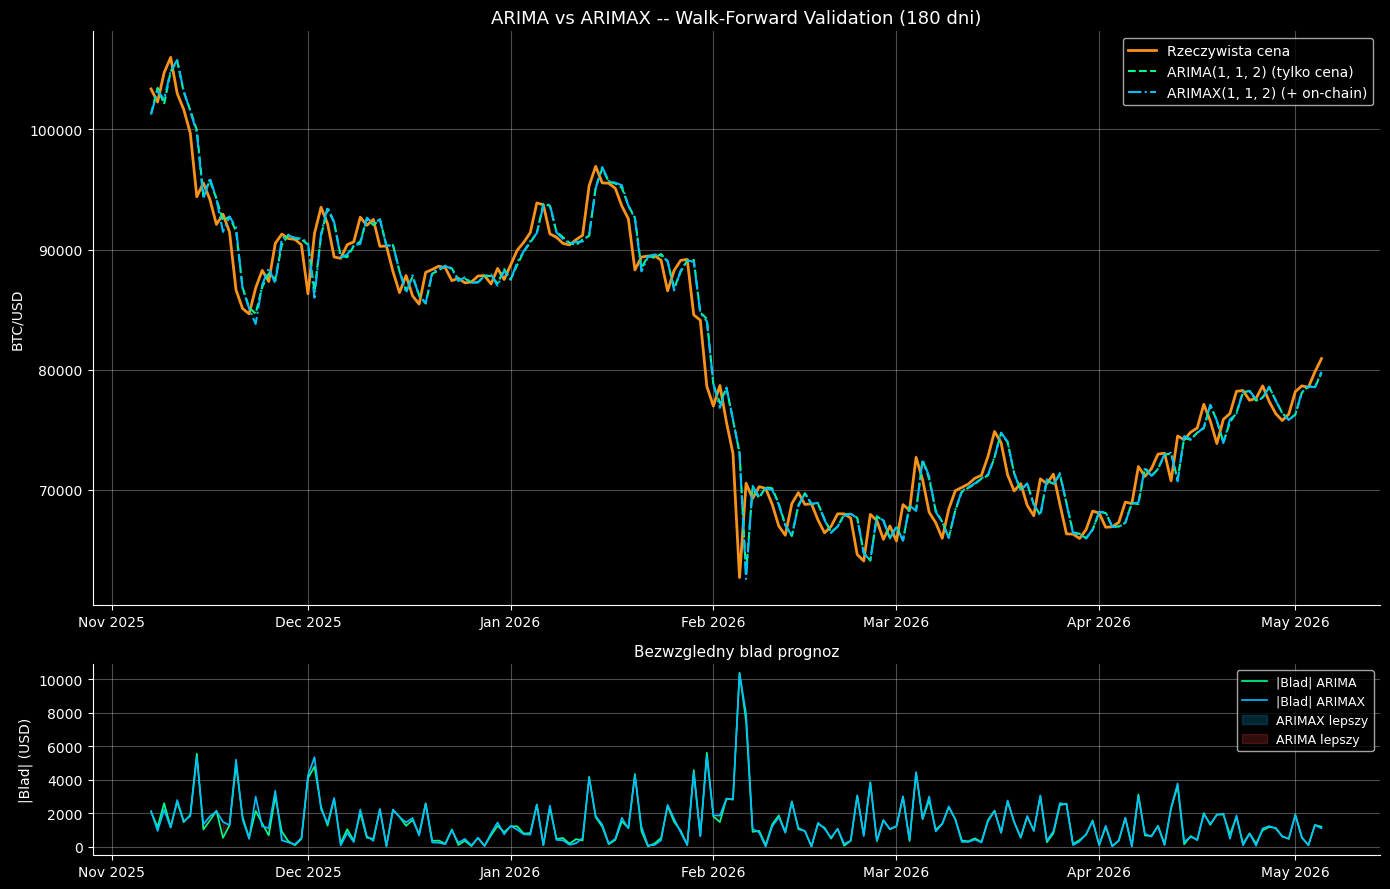

In [27]:
# Wykres ARIMA vs ARIMAX
fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1]})

ax1 = axes[0]
ax1.plot(test_common.index, test_common.values,
         color='#F7931A', lw=2, label='Rzeczywista cena')
ax1.plot(test_common.index, pred_arima_c.values,
         color='#00FF88', lw=1.5, linestyle='--', label=f'ARIMA{BEST_ORDER} (tylko cena)')
ax1.plot(test_common.index, pred_arimax_c.values,
         color='#00BFFF', lw=1.5, linestyle='-.', label=f'ARIMAX{BEST_ORDER} (+ on-chain)')
ax1.set_title('ARIMA vs ARIMAX -- Walk-Forward Validation (180 dni)', fontsize=13)
ax1.set_ylabel('BTC/USD')
ax1.legend(fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax2 = axes[1]
err_arima  = np.abs(test_common.values - pred_arima_c.values)
err_arimax = np.abs(test_common.values - pred_arimax_c.values)
ax2.plot(test_common.index, err_arima,  color='#00FF88', lw=1.2, label='|Blad| ARIMA')
ax2.plot(test_common.index, err_arimax, color='#00BFFF', lw=1.2, label='|Blad| ARIMAX')
ax2.fill_between(test_common.index, err_arima, err_arimax,
                 where=err_arimax < err_arima, alpha=0.2, color='#00BFFF', label='ARIMAX lepszy')
ax2.fill_between(test_common.index, err_arima, err_arimax,
                 where=err_arimax >= err_arima, alpha=0.2, color='#FF4444', label='ARIMA lepszy')
ax2.set_title('Bezwzgledny blad prognoz', fontsize=11)
ax2.set_ylabel('|Blad| (USD)')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('../data/processed/arimax_vs_arima.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 17. Prognoza ARIMAX -- jutro (1 dzien naprzod)

> **Dlaczego ARIMAX prognozuje tylko 1 dzien?**
> lag=1 oznacza: jutrzejsza prognoza potrzebuje dzisiejszych danych on-chain -- ktore znamy.
> Dla prognozy za 2 dni potrzeba jutrzejszych on-chain -- ktorych jeszcze nie ma.
> Rozwiazanie na wiecej niz 1 dzien: LSTM/BiLSTM.

In [28]:
# Finalny model ARIMAX -- trening na calych danych
print(f'Trenuje ARIMAX{BEST_ORDER} na {len(price_x)} obserwacjach...')
final_arimax = ARIMA(price_x, order=BEST_ORDER, exog=exog_sc).fit()
print('Gotowe.')
print()
print(f'  AIC: ARIMA={final_fit.aic:.2f}   ARIMAX={final_arimax.aic:.2f}')
print(f'  BIC: ARIMA={final_fit.bic:.2f}   ARIMAX={final_arimax.bic:.2f}')
print('  Nizsze AIC/BIC = lepsze dopasowanie')

# Prognoza jutro: exog = dzisiejsze wartosci (ostatni znany wiersz)
exog_tomorrow = exog_sc.iloc[[-1]].values
fc            = final_arimax.get_forecast(steps=1, exog=exog_tomorrow)
pred_tomorrow = fc.predicted_mean.iloc[0]
ci_tomorrow   = fc.conf_int(alpha=0.05)
change        = (pred_tomorrow / price_x.iloc[-1] - 1) * 100

print()
print('=' * 55)
print('       Prognoza ARIMAX -- JUTRO')
print('=' * 55)
print(f'  Ostatnia cena:       ${price_x.iloc[-1]:,.0f}  ({price_x.index[-1].date()})')
print(f'  Prognoza jutro:      ${pred_tomorrow:,.0f}')
print(f'  95% CI:              [${ci_tomorrow.iloc[0,0]:,.0f} ; ${ci_tomorrow.iloc[0,1]:,.0f}]')
print(f'  Prognozowana zmiana: {"+" if change>=0 else ""}{change:.2f}%')
print('=' * 55)

Trenuje ARIMAX(1, 1, 2) na 1794 obserwacjach...


/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Gotowe.

  AIC: ARIMA=31558.38   ARIMAX=31564.61
  BIC: ARIMA=31580.35   ARIMAX=31646.99
  Nizsze AIC/BIC = lepsze dopasowanie

       Prognoza ARIMAX -- JUTRO
  Ostatnia cena:       $80,927  (2026-05-05)
  Prognoza jutro:      $80,922
  95% CI:              [$77,798 ; $84,045]
  Prognozowana zmiana: -0.01%


---
## 18. Ktore zmienne on-chain maja najwiekszy wplyw?

Wspolczynniki modelu ARIMAX pokazuja liniowy wplyw kazdej zmiennej on-chain na cene BTC.
> Uwaga: to zaleznosci **korelacyjne**, nie przyczynowe.

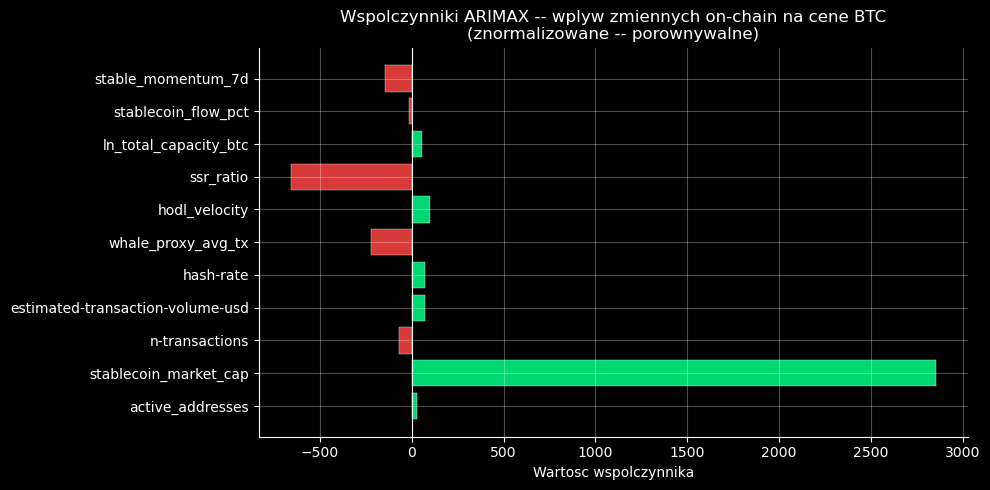

Interpretacja:
  Zielony (>0): wzrost zmiennej -> model prognozuje wzrost ceny
  Czerwony (<0): wzrost zmiennej -> model prognozuje spadek ceny

Ranking wplywu (wartosc absolutna):
  1. stablecoin_market_cap                      +2853.3816  (wzrost ceny)
  2. ssr_ratio                                  -657.6525  (spadek ceny)
  3. whale_proxy_avg_tx                         -224.5800  (spadek ceny)
  4. stable_momentum_7d                         -145.7364  (spadek ceny)
  5. hodl_velocity                              +99.2086  (wzrost ceny)
  6. hash-rate                                  +72.0615  (wzrost ceny)
  7. estimated-transaction-volume-usd           +71.6341  (wzrost ceny)
  8. n-transactions                             -70.0836  (spadek ceny)
  9. ln_total_capacity_btc                      +58.1127  (wzrost ceny)
  10. active_addresses                           +31.0940  (wzrost ceny)
  11. stablecoin_flow_pct                        -16.2966  (spadek ceny)


In [29]:
# Wspolczynniki ARIMAX
params      = final_arimax.params
exog_params = {col: params.get(col, 0) for col in EXOG_COLS}

fig, ax = plt.subplots(figsize=(10, 5))
cols   = list(exog_params.keys())
vals   = list(exog_params.values())
colors = ['#00FF88' if v >= 0 else '#FF4444' for v in vals]
bars   = ax.barh(cols, vals, color=colors, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(0, color='white', lw=0.8)
ax.set_title('Wspolczynniki ARIMAX -- wplyw zmiennych on-chain na cene BTC\n(znormalizowane -- porownywalne)', fontsize=12)
ax.set_xlabel('Wartosc wspolczynnika')
plt.tight_layout()
plt.savefig('../data/processed/arimax_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()

print('Interpretacja:')
print('  Zielony (>0): wzrost zmiennej -> model prognozuje wzrost ceny')
print('  Czerwony (<0): wzrost zmiennej -> model prognozuje spadek ceny')
print()
print('Ranking wplywu (wartosc absolutna):')
ranked = sorted(exog_params.items(), key=lambda x: abs(x[1]), reverse=True)
for i, (col, val) in enumerate(ranked, 1):
    direction = 'wzrost ceny' if val > 0 else 'spadek ceny'
    print(f'  {i}. {col:<42} {val:+.4f}  ({direction})')

In [30]:
# Finalne podsumowanie
print('=' * 68)
print('           FINALNE PODSUMOWANIE -- ARIMA vs ARIMAX')
print('=' * 68)
print()
print(f'{"Model":<10} {"MAPE":>8} {"MAE":>12} {"RMSE":>12} {"Dir.Acc":>10} {"AIC":>10}')
print('-' * 60)
print(f'{"ARIMA":<10} {m_arima["MAPE"]:>7.2f}% ${m_arima["MAE"]:>10,.0f} ${m_arima["RMSE"]:>10,.0f} {m_arima["DA"]:>9.1f}% {final_fit.aic:>10.1f}')
print(f'{"ARIMAX":<10} {m_arimax["MAPE"]:>7.2f}% ${m_arimax["MAE"]:>10,.0f} ${m_arimax["RMSE"]:>10,.0f} {m_arimax["DA"]:>9.1f}% {final_arimax.aic:>10.1f}')
print()
print('Dane on-chain uzyte w ARIMAX:')
for col in EXOG_COLS:
    print(f'  * {col}')
print()
print('Ograniczenia ARIMAX:')
print('  * Prognoza wielodniowa wymaga tez prognozowania danych on-chain')
print('  * Zaklada LINIOWY wplyw kazdej zmiennej na cene')
print('  * Nie modeluje interakcji miedzy zmiennymi on-chain')
print()
print('Co dalej -- LSTM/BiLSTM:')
print('  * Przyjma ten sam zestaw 9+ zmiennych on-chain')
print('  * Naucza sie NIELINIOWYCH zaleznosci i interakcji')
print('  * Moga prognozowac wszystkie horyzonty (1d-180d)')
print('=' * 68)

           FINALNE PODSUMOWANIE -- ARIMA vs ARIMAX

Model          MAPE          MAE         RMSE    Dir.Acc        AIC
------------------------------------------------------------
ARIMA         1.81% $     1,424 $     2,008      51.4%    31558.4
ARIMAX        1.83% $     1,443 $     2,042      54.7%    31564.6

Dane on-chain uzyte w ARIMAX:
  * active_addresses
  * stablecoin_market_cap
  * n-transactions
  * estimated-transaction-volume-usd
  * hash-rate
  * whale_proxy_avg_tx
  * hodl_velocity
  * ssr_ratio
  * ln_total_capacity_btc
  * stablecoin_flow_pct
  * stable_momentum_7d

Ograniczenia ARIMAX:
  * Prognoza wielodniowa wymaga tez prognozowania danych on-chain
  * Zaklada LINIOWY wplyw kazdej zmiennej na cene
  * Nie modeluje interakcji miedzy zmiennymi on-chain

Co dalej -- LSTM/BiLSTM:
  * Przyjma ten sam zestaw 9+ zmiennych on-chain
  * Naucza sie NIELINIOWYCH zaleznosci i interakcji
  * Moga prognozowac wszystkie horyzonty (1d-180d)


## Model LSTM — Long Short-Term Memory
**Dane:** Wielowymiarowe (Multivariate) — połączenie kursu BTC, danych On-Chain oraz płynności stablecoinów.  
**Model:** LSTM (Recurrent Neural Network).

### Dlaczego LSTM w prognozowaniu Bitcoina?
Klasyczne modele jak ARIMA mają trudności z wychwytywaniem gwałtownych, nieliniowych zmian (np. "short squeeze" lub nagłe załamania). LSTM rozwiązuje ten problem poprzez:
1. **Bramki (Gates):** Mechanizmy, które decydują, jakie informacje z przeszłości są istotne, a które należy "zapomnieć".
2. **Sekwencyjność:** Model uczy się wzorców zachodzących w czasie (np. "jeśli wolumen rośnie przez 3 dni, a cena stoi, to nastąpi wybicie").
3. **Obsługa wielu cech:** Model analizuje jednocześnie cenę, liczbę aktywnych adresów i płynność rynkową.

In [31]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ── Dane: to samo źródło i te same cechy co BLSTM ──────────────────────────
# BLSTM używa df_full + EXOG_COLS + log-returns; LSTM robi dokładnie to samo.
# Dzięki temu oba modele są porównywalne (ten sam zbiór cech, ten sam split).

WINDOW_SIZE_LSTM = 60   # dłuższe okno niż BLSTM (14 dni) – LSTM ma więcej pojemności

features_list_lstm = ['price'] + EXOG_COLS
data_lstm = df_full[features_list_lstm].copy().dropna()

# Log-returns ceny (tak jak w BLSTM) – zapewnia stacjonarność i brak dryftu
data_lstm['price'] = np.log(data_lstm['price'] / data_lstm['price'].shift(1))
data_lstm = data_lstm.dropna()

# Skalowanie (-1, 1) – spójne z BLSTM
scaler_lstm = MinMaxScaler(feature_range=(-1, 1))
scaled_lstm = scaler_lstm.fit_transform(data_lstm)

# Skaler tylko dla log-returnów ceny (do inverse_transform przy predykcji)
price_return_scaler_lstm = MinMaxScaler(feature_range=(-1, 1))
price_return_scaler_lstm.fit(data_lstm[['price']])

# Tworzenie sekwencji
X_lstm, y_lstm = [], []
for i in range(WINDOW_SIZE_LSTM, len(scaled_lstm)):
    X_lstm.append(scaled_lstm[i - WINDOW_SIZE_LSTM:i, :])
    y_lstm.append(scaled_lstm[i, 0])   # kolumna 0 = log-return ceny

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

# Podział: ostatnie 180 dni = test (tak jak w BLSTM i walk-forward ARIMA)
train_idx_lstm = len(X_lstm) - 180
X_train_lstm, X_test_lstm = X_lstm[:train_idx_lstm], X_lstm[train_idx_lstm:]
y_train_lstm, y_test_lstm = y_lstm[:train_idx_lstm], y_lstm[train_idx_lstm:]

print(f"Dane LSTM przygotowane.")
print(f"  Cechy:         {features_list_lstm}")
print(f"  Okno (lookback): {WINDOW_SIZE_LSTM} dni")
print(f"  Kształt X_train: {X_train_lstm.shape}")
print(f"  Kształt X_test:  {X_test_lstm.shape}  ({len(X_test_lstm)} dni testowych)")


Dane LSTM przygotowane.
  Cechy:         ['price', 'active_addresses', 'stablecoin_market_cap', 'n-transactions', 'estimated-transaction-volume-usd', 'hash-rate', 'whale_proxy_avg_tx', 'hodl_velocity', 'ssr_ratio', 'ln_total_capacity_btc', 'stablecoin_flow_pct', 'stable_momentum_7d']
  Okno (lookback): 60 dni
  Kształt X_train: (1554, 60, 12)
  Kształt X_test:  (180, 60, 12)  (180 dni testowych)


### Architektura sieci neuronowej LSTM
Zastosowana architektura składa się z:
- **Warstwy LSTM (50 jednostek):** Wyciąga zależności z szeregów czasowych.
- **Dropout (20%):** Technika regularyzacji zapobiegająca "uczeniu się na pamięć" danych treningowych.
- **Dense Layer:** Przekształca wyjście z sieci na pojedynczą wartość przewidywanej ceny.

In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_lstm_model(input_shape):
    """
    Jednokierunkowy LSTM – architektura celowo spójna z BLSTM:
    • Sequential API (tak jak BLSTM)
    • Te same hiperparametry regularyzacji: Dropout(0.2), BatchNormalization
    • Ta sama funkcja straty: MSE na log-returnach
    • Adam(lr=0.001) – identyczny jak w BLSTM
    Jedyna różnica: LSTM zamiast Bidirectional(LSTM) → uczciwe porównanie.
    """
    model = Sequential([
        # Warstwa 1: wychwytuje krótko- i średnioterminowe wzorce
        LSTM(units=64, return_sequences=True,
             input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.2),

        # Warstwa 2: kompresja do reprezentacji końcowej
        LSTM(units=32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),

        # Gęste warstwy – tak samo jak w BLSTM
        Dense(units=16, activation='relu'),
        Dense(units=1)   # Brak aktywacji – regresja log-returnów
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mean_squared_error'   # spójne z BLSTM
    )
    return model


# --- Callbacki (identyczne jak w BLSTM) ---
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr_lstm  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7)

# --- Trening ---
model_lstm = build_lstm_model((X_train_lstm.shape[1], X_train_lstm.shape[2]))
model_lstm.summary()

history_lstm = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=150,
    batch_size=32,          # spójne z BLSTM
    validation_split=0.15,  # spójne z BLSTM
    callbacks=[early_stop_lstm, reduce_lr_lstm],
    verbose=1
)


2026-05-13 00:15:59.360260: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,057 (129.13 KB)

 Trainable params: 32,865 (128.38 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/150
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.5658 - val_loss: 0.0325 - learning_rate: 0.0010
Epoch 2/150
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.2085 - val_loss: 0.0207 - learning_rate: 0.0010
Epoch 3/150
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1628 - val_loss: 0.0171 - learning_rate: 0.0010
Epoch 4/150
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1243 - val_loss: 0.0180 - learning_rate: 0.0010
Epoch 5/150
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1106 - val_loss: 0.0194 - learning_rate: 0.0010
Epoch 6/150
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0928 - val_loss: 0.0194 - learning_rate: 0.0010
Epoch 7/150
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0842 - val_loss: 0.0337 - learning_rate: 0.0010
Epoch 8/150
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0770 - val_loss: 0.0315 - learning_rate: 0.0010
Epoch 9/150
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0679 - val_loss: 0.0274 - learning_rate: 0.0010
Epoch 10/1

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
┌─ Metryki: LSTM (Log-Returns, Anchored) ────────────
│  MAE:               $     1,725
│  RMSE:              $     2,252
│  MAPE:                    2.19%   (średni błąd procentowy)
│  Directional Acc.:        52.5%   (trafienie kierunku ruchu)
└──────────────────────────────────────────────────


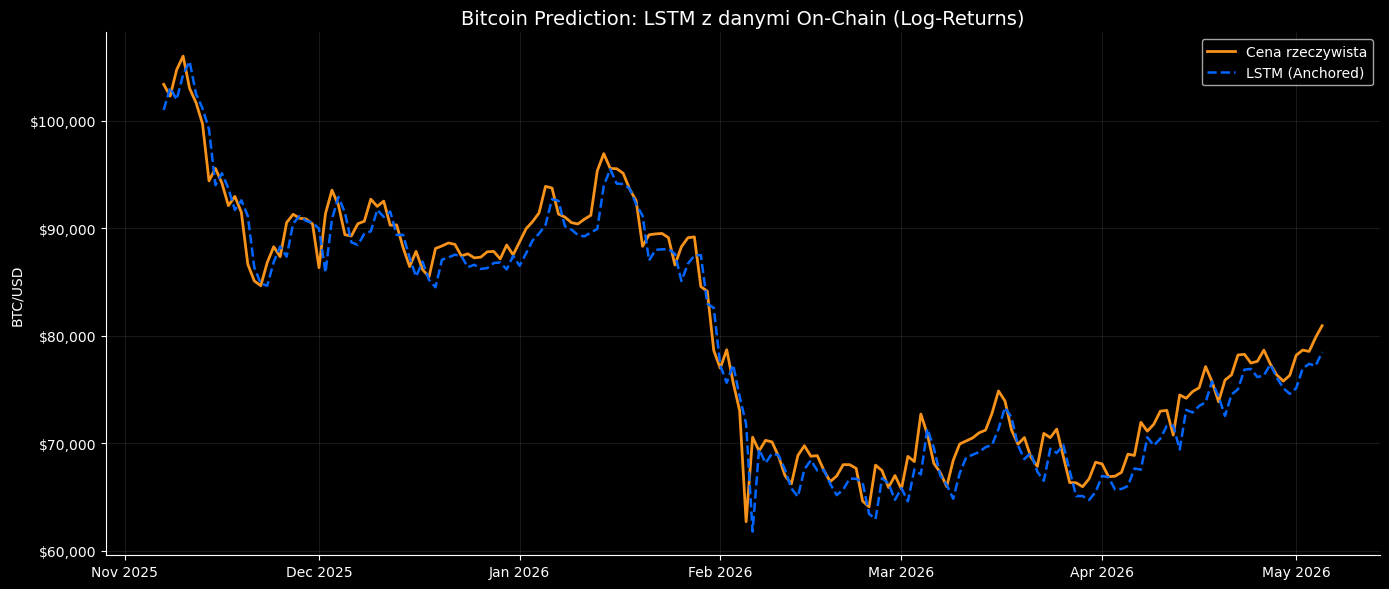

In [33]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Predykcja: anchored 1-step ahead (tak jak w BLSTM) ─────────────────────
# BLSTM (cell 60): pred_returns → kotwica na realnej cenie z dnia poprzedniego
# LSTM robi dokładnie to samo – uczciwe porównanie.

# 1. Przewidujemy log-returny (scaled)
pred_returns_scaled_lstm = model_lstm.predict(X_test_lstm)

# 2. Odwrócenie skalowania log-returnów
pred_returns_lstm = price_return_scaler_lstm.inverse_transform(
    pred_returns_scaled_lstm
).flatten()

# 3. Kotwiczenie na realnej cenie z dnia poprzedniego
#    (identyczna logika jak w BLSTM: real_prices_series * exp(pred_return))
real_prices_lstm = df_full['price'].iloc[-len(pred_returns_lstm) - 1 : -1].values
anchored_preds_lstm = real_prices_lstm * np.exp(pred_returns_lstm)

# 4. Seria wynikowa – ten sam zakres dat co BLSTM
lstm_dates = df_full.index[-len(anchored_preds_lstm):]
pred_lstm_final = pd.Series(anchored_preds_lstm, index=lstm_dates)

# 5. Metryki (ta sama funkcja co ARIMA/ARIMAX/BLSTM)
actuals_lstm = df_full['price'].iloc[-len(anchored_preds_lstm):]
m_lstm = metrics(actuals_lstm, pred_lstm_final, 'LSTM (Log-Returns, Anchored)')

# 6. Wykres – styl spójny z BLSTM
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_full.index[-180:], df_full['price'].iloc[-180:],
        label='Cena rzeczywista', color='#F7931A', linewidth=2)
ax.plot(pred_lstm_final.index, pred_lstm_final,
        label='LSTM (Anchored)', color='#0066FF', linestyle='--', linewidth=1.8)

ax.set_title('Bitcoin Prediction: LSTM z danymi On-Chain (Log-Returns)', fontsize=14)
ax.set_ylabel('BTC/USD')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.1)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig('../data/processed/lstm_prediction.png', dpi=120, bbox_inches='tight')
plt.show()


### LSTM 4.4. Wizualizacja i ocena jakości prognozy LSTM
Wykres porównuje rzeczywiste notowania Bitcoina z prognozami modelu LSTM.
Oceniamy zarówno błąd punktowy (MAPE/RMSE), jak i **Directional Accuracy (DA)** — skuteczność w przewidywaniu kierunku ruchu ceny.

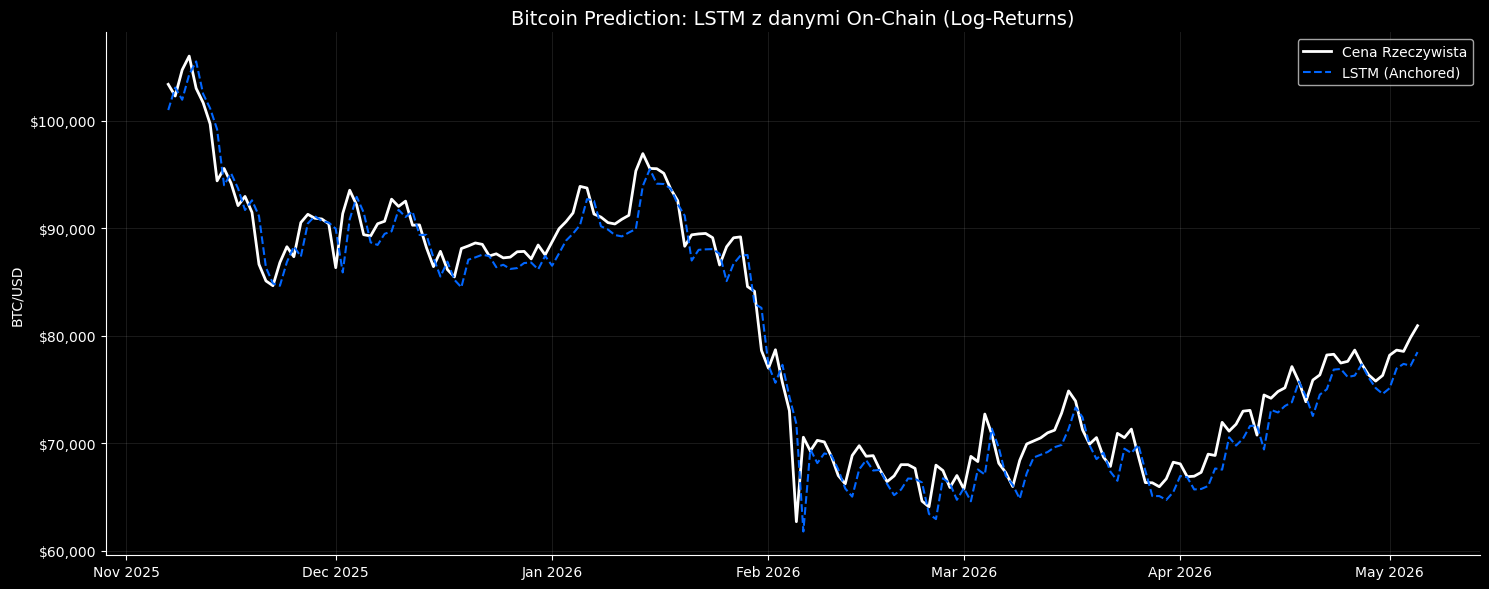

In [34]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(15, 6))
plt.plot(df_full.index[-180:], df_full['price'].iloc[-180:],
         label='Cena Rzeczywista', color='white', linewidth=2)
plt.plot(pred_lstm_final.index, pred_lstm_final,
         label='LSTM (Anchored)', color='#0066FF', linestyle='--')

plt.title('Bitcoin Prediction: LSTM z danymi On-Chain (Log-Returns)', fontsize=14)
plt.ylabel('BTC/USD')
plt.legend()
plt.grid(True, alpha=0.1)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig('../data/processed/lstm_prediction.png', dpi=120, bbox_inches='tight')
plt.show()


### LSTM 4.5. Analiza współzależności: Mapa korelacji (Heatmap)
Macierz korelacji między **logarytmicznymi stopami zwrotu** ceny BTC a zmiennymi on-chain.
Korelacja zwrotów (returns) jest znacznie trudniejsza do uzyskania niż korelacja surowych cen,
ale bardziej wartościowa — wskazuje, które parametry sieci mają realny związek z nagłymi ruchami cenowymi.

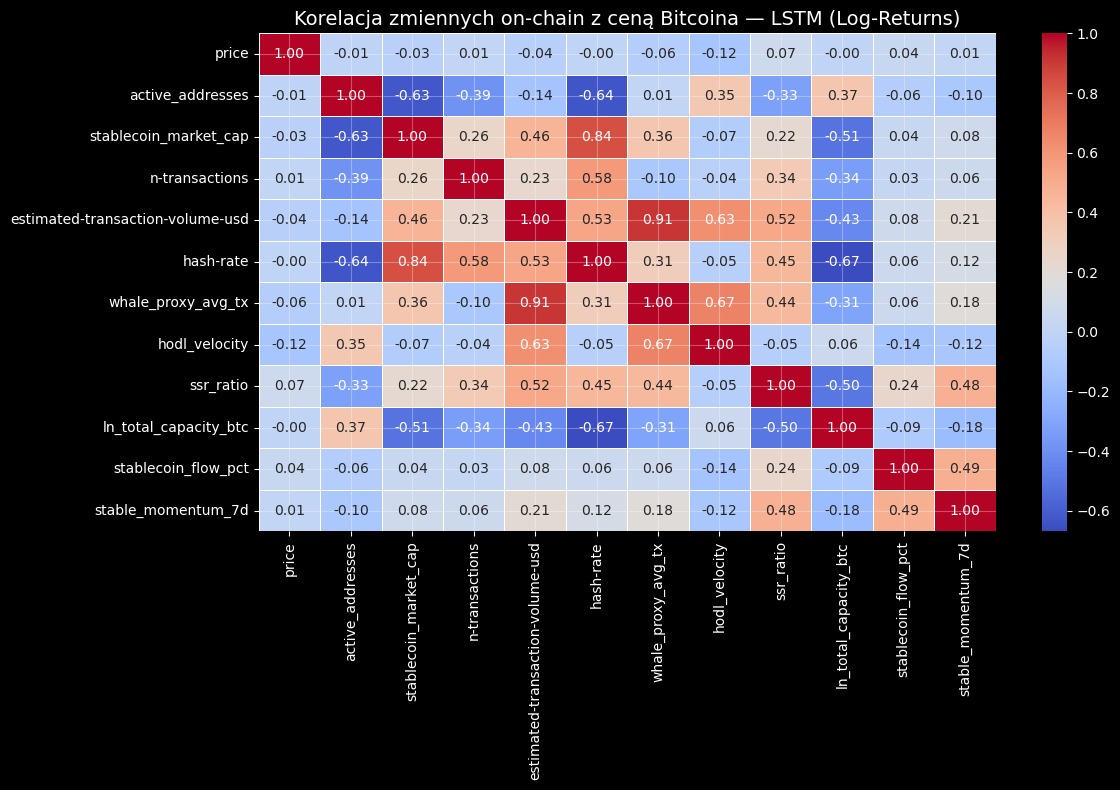

In [35]:
import seaborn as sns

# Używamy data_lstm (z log-returns) — te same dane co trenował LSTM
corr_matrix_lstm = data_lstm.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_lstm, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelacja zmiennych on-chain z ceną Bitcoina — LSTM (Log-Returns)', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/lstm_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


### Interpretacja Mapy Korelacji — LSTM
Analiza korelacji log-returnów pozwala na identyfikację bezpośrednich zależności między dynamiką sieci Bitcoin a zmianami rynkowymi:

1. **Niskie wartości bezwzględne:** Wartości w okolicach 0.05–0.20 są typowe dla zwrotów dziennych. Brak dominującej zmiennej sugeruje efektywność rynku.
2. **Kierunki zależności:** Dodatnie korelacje wskaźników aktywności adresów potwierdzają hipotezę Prawa Metcalfe'a.
3. **Potencjał dla LSTM:** Niskie korelacje liniowe uzasadniają użycie sieci neuronowych, które wychwytują ukryte, nieliniowe wzorce.

### LSTM 4.6. Interpretacja modelu: Ważność cech (Permutation Importance)
Algorytm losowo „psuje" dane w jednej kolumnie i sprawdza, jak bardzo wzrośnie błąd predykcji:
- **Duży wzrost błędu** = cecha była kluczowa dla modelu.
- **Brak zmiany błędu** = cecha była ignorowana przez model.

Pozwala zweryfikować, czy LSTM faktycznie korzysta z danych on-chain.

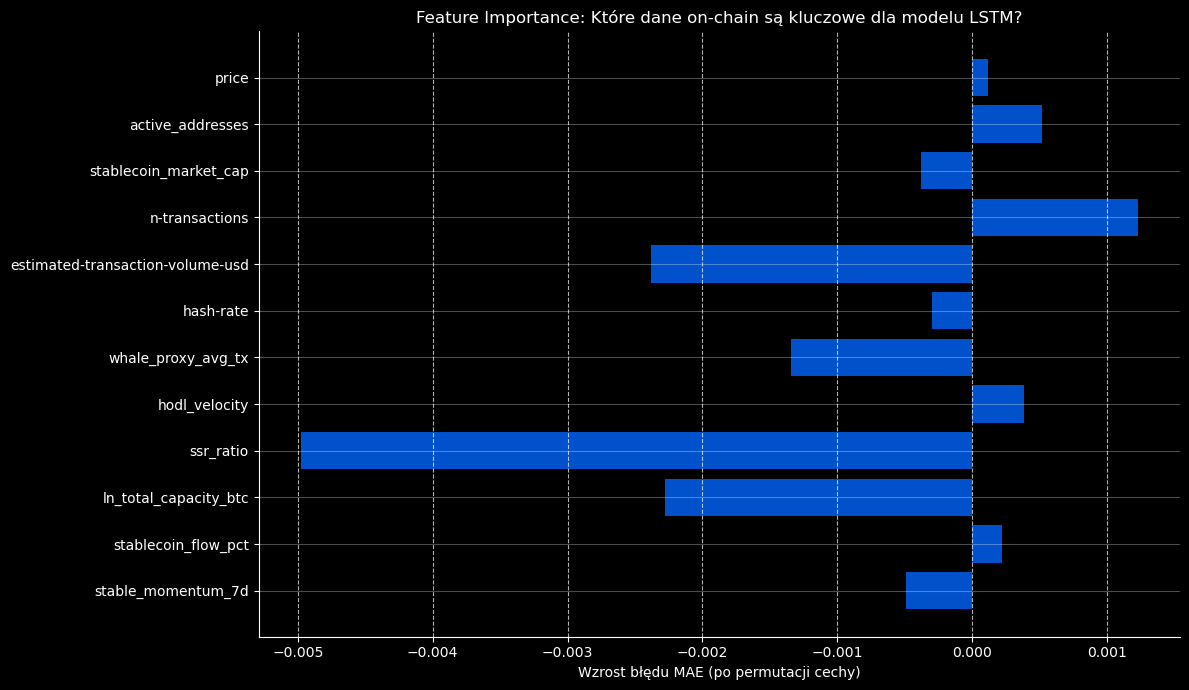

In [36]:
from sklearn.metrics import mean_absolute_error

def calculate_feature_importance(model, X, y, feature_names):
    baseline_mae = mean_absolute_error(y, model.predict(X, verbose=0))
    importances = []
    for i in range(X.shape[2]):
        X_temp = X.copy()
        np.random.shuffle(X_temp[:, :, i])
        permuted_mae = mean_absolute_error(y, model.predict(X_temp, verbose=0))
        importances.append(permuted_mae - baseline_mae)
    return importances

# Używamy X_test_lstm i y_test_lstm (dane LSTM)
importances_lstm = calculate_feature_importance(
    model_lstm, X_test_lstm, y_test_lstm, features_list_lstm
)

plt.figure(figsize=(12, 7))
y_pos = np.arange(len(features_list_lstm))
plt.barh(y_pos, importances_lstm, color='#0066FF', alpha=0.8, align='center')
plt.yticks(y_pos, features_list_lstm)
plt.xlabel('Wzrost błędu MAE (po permutacji cechy)')
plt.title('Feature Importance: Które dane on-chain są kluczowe dla modelu LSTM?')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../data/processed/lstm_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


### LSTM 4.6.1. Porównanie ważności cech: LSTM vs BLSTM
Zestawienie wyników permutation importance obu modeli pozwala zobaczyć, czy jednokierunkowy i dwukierunkowy LSTM
opierają się na tych samych sygnałach on-chain, czy każdy z nich wychwytuje inne zależności.

Uwaga: najpierw uruchom sekcję BLSTM (komórka z 'importances'), aby móc porównać oba modele.


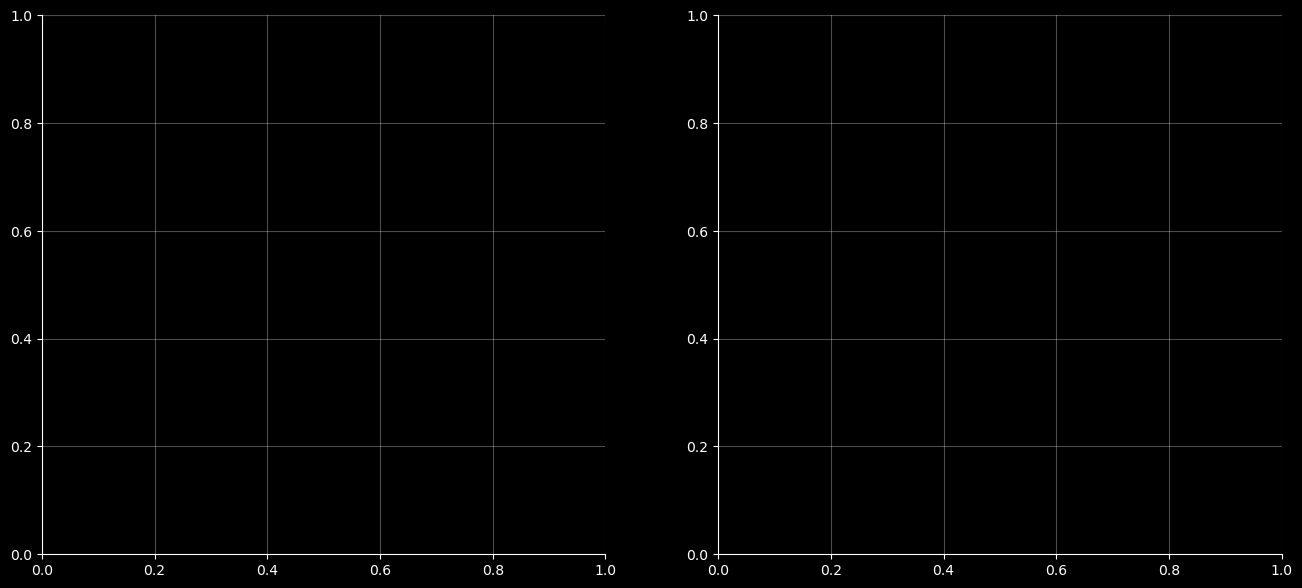

In [37]:
# Porównanie Feature Importance LSTM vs BLSTM
# (wymaga, żeby wcześniej obliczono importances dla BLSTM jako 'importances')
try:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax, imps, name, color in zip(
        axes,
        [importances_lstm, importances],
        ['LSTM', 'BLSTM'],
        ['#0066FF', '#00FFCC']
    ):
        y_pos = np.arange(len(features_list_lstm))
        ax.barh(y_pos, imps, color=color, alpha=0.8, align='center')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(features_list_lstm)
        ax.set_xlabel('Wzrost błędu MAE (po permutacji cechy)')
        ax.set_title(f'Feature Importance — {name}')
        ax.invert_yaxis()
        ax.grid(axis='x', linestyle='--', alpha=0.5)

    plt.suptitle('Permutation Importance: LSTM vs BLSTM', fontsize=14)
    plt.tight_layout()
    plt.savefig('../data/processed/lstm_vs_blstm_importance.png', dpi=120, bbox_inches='tight')
    plt.show()
except NameError:
    print("Uwaga: najpierw uruchom sekcję BLSTM (komórka z 'importances'), "
          "aby móc porównać oba modele.")


### LSTM 4.7. Analiza błędów predykcji (Residuals Analysis)
Wykres różnicy między rzeczywistą ceną BTC a prognozą LSTM ($Błąd = Cena_{Real} - Cena_{Pred}$).

**Kluczowe obserwacje:**
1. **Szum wokół zera:** Większość błędów oscyluje blisko linii zero — wysoka trafność w stabilnych warunkach.
2. **Ekstremalne odchylenia:** Szpilki korelują z okresami ekstremalnej zmienności (newsy, wydarzenia makro).
3. **Brak dryftu:** Metoda kotwiczenia (1-step ahead) eliminuje kumulację błędu.

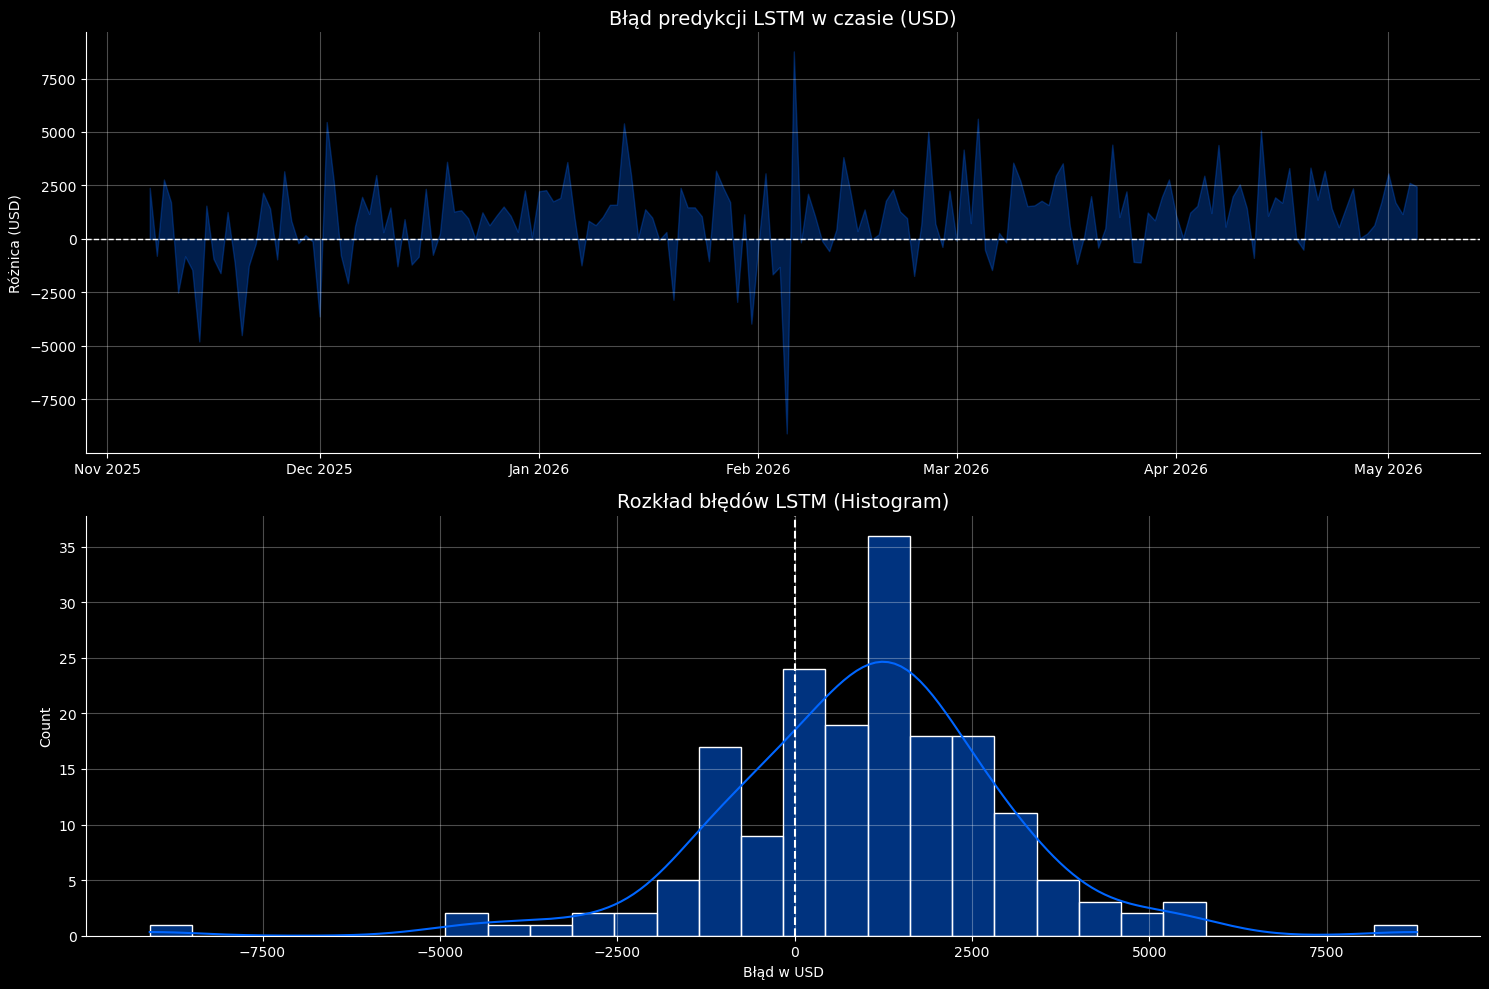

Średni błąd (bias): $987
Odch. std. błędów:  $2,029
Max błąd dodatni:   $8,766
Max błąd ujemny:    $-9,090


In [38]:
import seaborn as sns

residuals_lstm = actuals_lstm - pred_lstm_final

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=False)

ax1.fill_between(residuals_lstm.index, residuals_lstm, color='#0066FF', alpha=0.3)
ax1.axhline(0, color='white', linestyle='--', linewidth=1)
ax1.set_title('Błąd predykcji LSTM w czasie (USD)', fontsize=14)
ax1.set_ylabel('Różnica (USD)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

sns.histplot(residuals_lstm, kde=True, ax=ax2, color='#0066FF', bins=30)
ax2.axvline(0, color='white', linestyle='--')
ax2.set_title('Rozkład błędów LSTM (Histogram)', fontsize=14)
ax2.set_xlabel('Błąd w USD')

plt.tight_layout()
plt.savefig('../data/processed/lstm_residuals.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Średni błąd (bias): ${residuals_lstm.mean():,.0f}")
print(f"Odch. std. błędów:  ${residuals_lstm.std():,.0f}")
print(f"Max błąd dodatni:   ${residuals_lstm.max():,.0f}")
print(f"Max błąd ujemny:    ${residuals_lstm.min():,.0f}")


### LSTM 4.9. Prognoza długoterminowa (Recursive Long-Horizon Forecast)
Prognoza na kolejne 180 dni przy użyciu **pętli rekurencyjnej**:
1. Model pobiera ostatnie 60 dni danych on-chain i ceny.
2. Przewiduje log-return na kolejny dzień.
3. Nowa prognoza jest dołączana do okna, najstarszy dzień usuwany.
4. Proces powtarza się do osiągnięcia horyzontu 180 dni.

*Uwaga: zmienne on-chain są trzymane stałe (ostatnia znana wartość) — prognoza jest przybliżona.*

Generowanie prognozy długoterminowej LSTM (180 dni)...


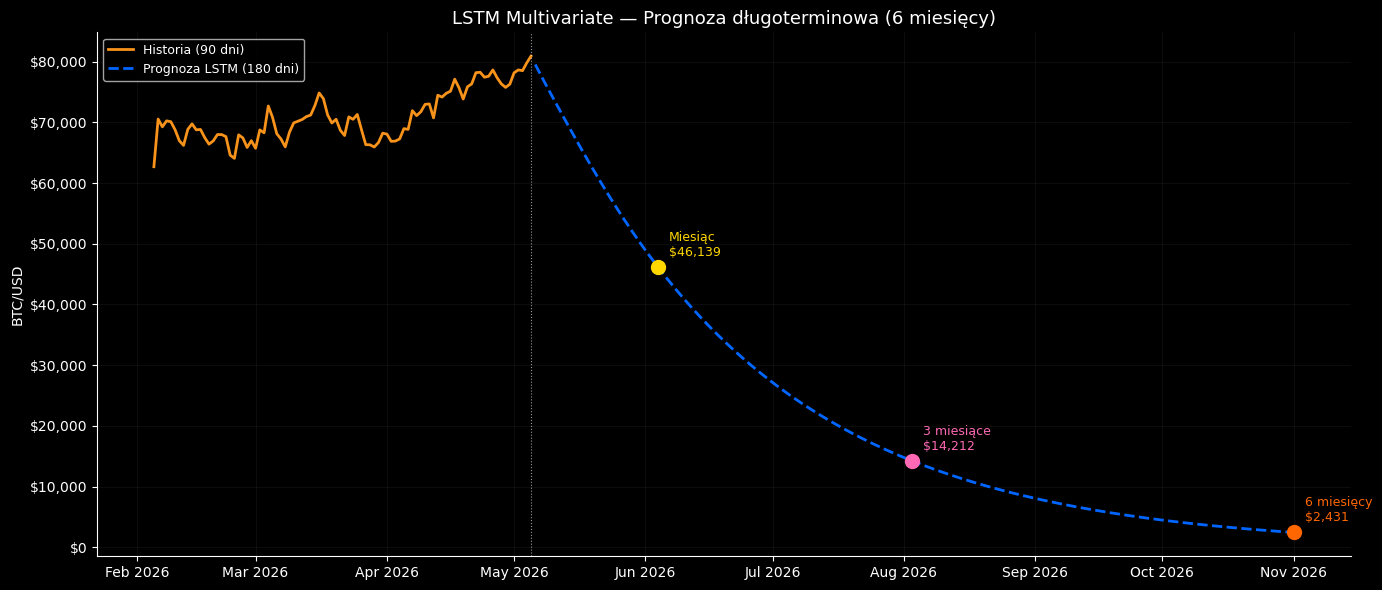


Podsumowanie prognozy LSTM:
  Ostatnia cena:     $80,927  (2026-05-05)
  Miesiąc        $46,139  (-43.0%)
  3 miesiące     $14,212  (-82.4%)
  6 miesięcy     $2,431  (-97.0%)


In [39]:
MAX_STEPS_LSTM = 180

# 1. Ostatnie znane okno (ostatni element X_test_lstm)
current_batch_lstm = X_test_lstm[-1].reshape(1, WINDOW_SIZE_LSTM, X_test_lstm.shape[2])
future_returns_lstm = []

print(f"Generowanie prognozy długoterminowej LSTM ({MAX_STEPS_LSTM} dni)...")

# 2. Pętla rekurencyjna
for step in range(MAX_STEPS_LSTM):
    current_pred = model_lstm.predict(current_batch_lstm, verbose=0)
    future_returns_lstm.append(current_pred[0, 0])

    # Aktualizacja okna: zachowujemy cechy on-chain, doklejamy nową cenę
    last_exog = current_batch_lstm[0, -1, 1:]
    new_row = np.insert(last_exog, 0, current_pred[0, 0]).reshape(1, 1, X_test_lstm.shape[2])
    current_batch_lstm = np.append(current_batch_lstm[:, 1:, :], new_row, axis=1)

# 3. Odwrócenie skalowania log-returnów
future_returns_rescaled_lstm = price_return_scaler_lstm.inverse_transform(
    np.array(future_returns_lstm).reshape(-1, 1)
).flatten()

# 4. Rekonstrukcja ceny od ostatniej znanej wartości
last_real_price_lstm = df_full['price'].iloc[-1]
lstm_long_prices = []
current_price = last_real_price_lstm
for ret in future_returns_rescaled_lstm:
    current_price = current_price * np.exp(ret)
    lstm_long_prices.append(current_price)

# 5. Seria wynikowa
future_dates_lstm = pd.date_range(
    start=df_full.index[-1] + pd.Timedelta(days=1), periods=MAX_STEPS_LSTM
)
forecast_long_lstm = pd.Series(lstm_long_prices, index=future_dates_lstm)

# 6. Wykres
HORIZONS_LONG = {'Miesiąc': 30, '3 miesiące': 90, '6 miesięcy': 180}
H_COLORS_LONG = ['#FFD700', '#FF69B4', '#FF6600']

fig, ax = plt.subplots(figsize=(14, 6))

hist_slice = df_full['price'].iloc[-90:]
ax.plot(hist_slice.index, hist_slice.values, color='#F7931A', lw=2, label='Historia (90 dni)')
ax.plot(future_dates_lstm, forecast_long_lstm,
        color='#0066FF', lw=2, linestyle='--', label='Prognoza LSTM (180 dni)')

for (name, steps), color in zip(HORIZONS_LONG.items(), H_COLORS_LONG):
    d = future_dates_lstm[steps - 1]
    v = forecast_long_lstm.iloc[steps - 1]
    ax.scatter([d], [v], color=color, s=100, zorder=5)
    ax.annotate(f'{name}\n${v:,.0f}', xy=(d, v), xytext=(8, 8),
                textcoords='offset points', fontsize=9, color=color)

ax.axvline(df_full.index[-1], color='white', lw=0.8, linestyle=':', alpha=0.6)
ax.set_title('LSTM Multivariate — Prognoza długoterminowa (6 miesięcy)', fontsize=13)
ax.set_ylabel('BTC/USD')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.grid(True, alpha=0.05)
plt.tight_layout()
plt.savefig('../data/processed/lstm_forecast_long.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nPodsumowanie prognozy LSTM:")
print(f"  Ostatnia cena:     ${last_real_price_lstm:,.0f}  ({df_full.index[-1].date()})")
for name, steps in HORIZONS_LONG.items():
    v = forecast_long_lstm.iloc[steps - 1]
    chg = (v / last_real_price_lstm - 1) * 100
    sign = '+' if chg >= 0 else ''
    print(f"  {name:<14} ${v:,.0f}  ({sign}{chg:.1f}%)")


### LSTM 4.10. Porównanie prognoz długoterminowych: LSTM vs BLSTM
Zestawienie prognoz obu modeli na 180 dni naprzód — pozwala ocenić,
jak różni się trajektoria przewidywana przez model jednokierunkowy od dwukierunkowego.

Uwaga: najpierw uruchom sekcję BLSTM (komórka z 'forecast_long_blstm').


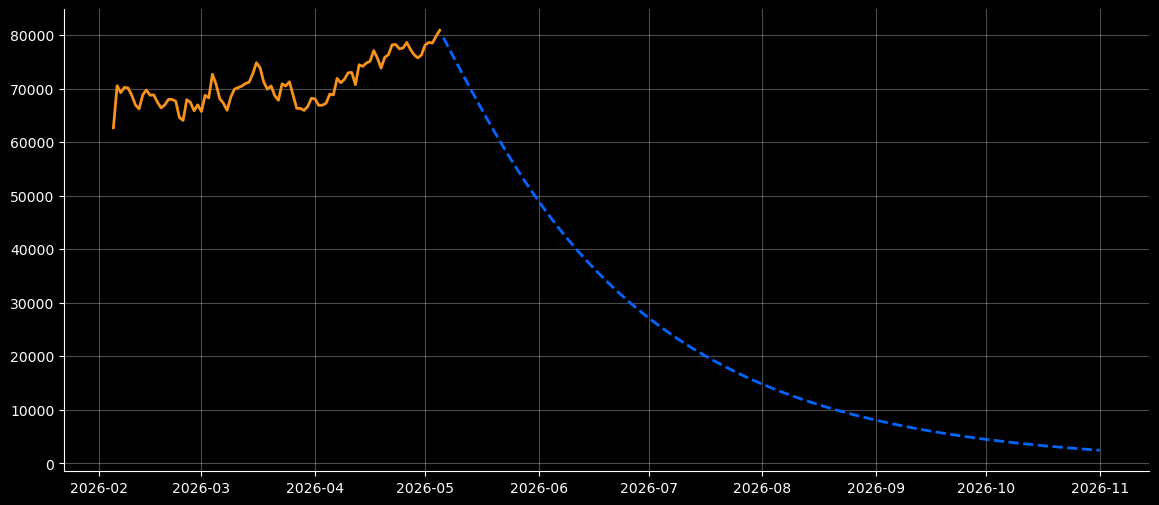

In [40]:
try:
    fig, ax = plt.subplots(figsize=(14, 6))

    hist_slice = df_full['price'].iloc[-90:]
    ax.plot(hist_slice.index, hist_slice.values,
            color='#F7931A', lw=2, label='Historia (90 dni)')
    ax.plot(future_dates_lstm, forecast_long_lstm,
            color='#0066FF', lw=2, linestyle='--', label='Prognoza LSTM')
    ax.plot(future_dates, forecast_long_blstm,
            color='#00FFCC', lw=2, linestyle='-.', label='Prognoza BLSTM')

    ax.axvline(df_full.index[-1], color='white', lw=0.8, linestyle=':', alpha=0.6)
    ax.set_title('Porównanie prognoz długoterminowych: LSTM vs BLSTM (180 dni)', fontsize=13)
    ax.set_ylabel('BTC/USD')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend(fontsize=10, loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.grid(True, alpha=0.05)
    plt.tight_layout()
    plt.savefig('../data/processed/lstm_vs_blstm_forecast.png', dpi=120, bbox_inches='tight')
    plt.show()
except NameError:
    print("Uwaga: najpierw uruchom sekcję BLSTM (komórka z 'forecast_long_blstm').")


## 4. Modelowanie zaawansowane: Bidirectional LSTM (BLSTM)

W tej sekcji przechodzimy do wykorzystania głębokich sieci neuronowych. Model **BLSTM** (dwukierunkowy LSTM) analizuje szeregi czasowe w dwóch kierunkach: od przeszłości do przyszłości oraz wstecz, co pozwala lepiej wychwycić nieliniowe korelacje.

### 4.1. Inżynieria cech i transformacja Log-Returns
Zamiast prognozować surową cenę, model będzie uczył się **logarytmicznych stóp zwrotu (log-returns)**. Jest to kluczowy zabieg, który zapewnia:
* **Stacjonarność danych:** ułatwia naukę sieci neuronowej niezależnie od poziomu ceny.
* **Eliminację autokorelacji:** zmusza model do szukania sygnałów w danych on-chain zamiast prostego kopiowania ceny z dnia poprzedniego.
* **Skalowanie:** dane zostają sprowadzone do zakresu [-1, 1], co optymalizuje proces aktualizacji wag w sieci.

In [41]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Przygotowanie danych - log returns dla ceny
features_list = ['price'] + EXOG_COLS
data_multi = df_full[features_list].copy().dropna()

# Zamiana ceny na log-returns (zmiana procentowa)
data_multi['price'] = np.log(data_multi['price'] / data_multi['price'].shift(1))
data_multi = data_multi.dropna()

# 2. Skalowanie wszystkich cech (zakres -1 do 1 jest lepszy dla zwrotów)
scaler_multi = MinMaxScaler(feature_range=(-1, 1))
scaled_data = scaler_multi.fit_transform(data_multi)

# Skaler tylko dla kolumny 'price' (indeks 0), żeby móc odwrócić same zwroty
price_return_scaler = MinMaxScaler(feature_range=(-1, 1))
price_return_scaler.fit(data_multi[['price']])

# 3. Tworzenie sekwencji
WINDOW_SIZE = 14 # Skracamy okno do 14 dni (świeższe dane)
X, y = [], []
for i in range(WINDOW_SIZE, len(scaled_data)):
    X.append(scaled_data[i-WINDOW_SIZE:i, :])
    y.append(scaled_data[i, 0])

X_multi, y_multi = np.array(X), np.array(y)
train_idx = len(X_multi) - 180
X_train, X_test = X_multi[:train_idx], X_multi[train_idx:]
y_train, y_test = y_multi[:train_idx], y_multi[train_idx:]

print(f"Kształt wejścia: {X_train.shape}") 

Kształt wejścia: (1600, 14, 12)


### 4.2. Definicja architektury i trening modelu
Konstruujemy sieć złożoną z dwóch warstw dwukierunkowych (Bidirectional). Dodatkowo stosujemy mechanizmy stabilizujące:
* **BatchNormalization:** zapobiega eksplozji gradientów i przyspiesza konwergencję.
* **Dropout:** technika regularyzacji zapobiegająca przeuczeniu (overfittingowi) poprzez losowe wyłączanie neuronów.
* **Early Stopping:** automatyczne przerwanie treningu w momencie, gdy model przestaje poprawiać wyniki na zbiorze walidacyjnym.


In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
import tensorflow as tf

model_blstm_v3 = Sequential([
    Bidirectional(LSTM(units=64, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.2),
    
    Bidirectional(LSTM(units=32, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(units=16, activation='relu'),
    Dense(units=1) # Brak aktywacji na końcu dla regresji zwrotów
])

model_blstm_v3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7)

history = model_blstm_v3.fit(
    X_train, y_train,
    epochs=150, batch_size=32, validation_split=0.15,
    callbacks=[early_stop, reduce_lr], verbose=1
)

Epoch 1/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.5525 - val_loss: 0.0268 - learning_rate: 0.0010
Epoch 2/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2067 - val_loss: 0.0235 - learning_rate: 0.0010
Epoch 3/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1535 - val_loss: 0.0243 - learning_rate: 0.0010
Epoch 4/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1192 - val_loss: 0.0209 - learning_rate: 0.0010
Epoch 5/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0930 - val_loss: 0.0220 - learning_rate: 0.0010
Epoch 6/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0897 - val_loss: 0.0210 - learning_rate: 0.0010
Epoch 7/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0774 - val_loss: 0.0175 - learning_rate: 0.0010
Epoch 8/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0727 - val_loss: 0.0171 - learning_rate: 0.0010
Epoch 9/150
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0634 - val_loss: 0.0177 - learning_rate: 0.0010
Epoch 10/1

### 4.3. Predykcja typu "1-Step Ahead" z kotwiczeniem ceny
Aby uniknąć kumulacji błędu i tzw. "dryftu" prognozy, stosujemy metodę prognozowania o jeden krok w przód. 

W każdym dniu testowym model przewiduje logarytmiczny zwrot, który następnie nakładamy na **rzeczywistą cenę z dnia poprzedniego (tzw. kotwica)**. Dzięki temu każda prognoza startuje z punktu opartego na faktach rynkowych, co pozwala realnie ocenić zdolność modelu do przewidywania kierunku ruchu ceny.

In [43]:
# 1. Przewidujemy zwroty (log returns)
pred_returns_scaled = model_blstm_v3.predict(X_test)
pred_returns = price_return_scaler.inverse_transform(pred_returns_scaled).flatten()

# 2. Pobieramy REALNE ceny z dnia poprzedniego dla całego okresu testowego
# Musimy cofnąć się o len(pred_returns) dni od końca
real_prices_series = df_full['price'].iloc[-len(pred_returns)-1:-1].values

# 3. Obliczamy cenę: Real_Price_Today * exp(Predicted_Return_Tomorrow)
anchored_preds = real_prices_series * np.exp(pred_returns)

# 4. Tworzymy serię danych
blstm_dates = df_full.index[-len(anchored_preds):]
pred_blstm_final = pd.Series(anchored_preds, index=blstm_dates)

# Metryki
actuals = df_full['price'].iloc[-len(anchored_preds):]
m_blstm_v3 = metrics(actuals, pred_blstm_final, 'BLSTM v3 (Log-Returns)')
print(m_blstm_v3)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step
┌─ Metryki: BLSTM v3 (Log-Returns) ──────────────────
│  MAE:               $     2,267
│  RMSE:              $     2,822
│  MAPE:                    2.87%   (średni błąd procentowy)
│  Directional Acc.:        47.5%   (trafienie kierunku ruchu)
└──────────────────────────────────────────────────
{'MAE': 2267.3467070911, 'RMSE': 2822.0690553785125, 'MAPE': 2.8685214155950884, 'DA': 47.486033519553075}


### 4.4. Wizualizacja i ocena jakości prognozy BLSTM
Poniższy wykres prezentuje porównanie rzeczywistych notowań Bitcoina z prognozami wygenerowanymi przez model BLSTM wykorzystujący pełny zestaw danych on-chain. 

Analizujemy nie tylko błąd punktowy (MAPE/RMSE), ale przede wszystkim **Directional Accuracy (DA)** — czyli skuteczność modelu w przewidywaniu, czy kolejny dzień zamknie się wzrostem, czy spadkiem.

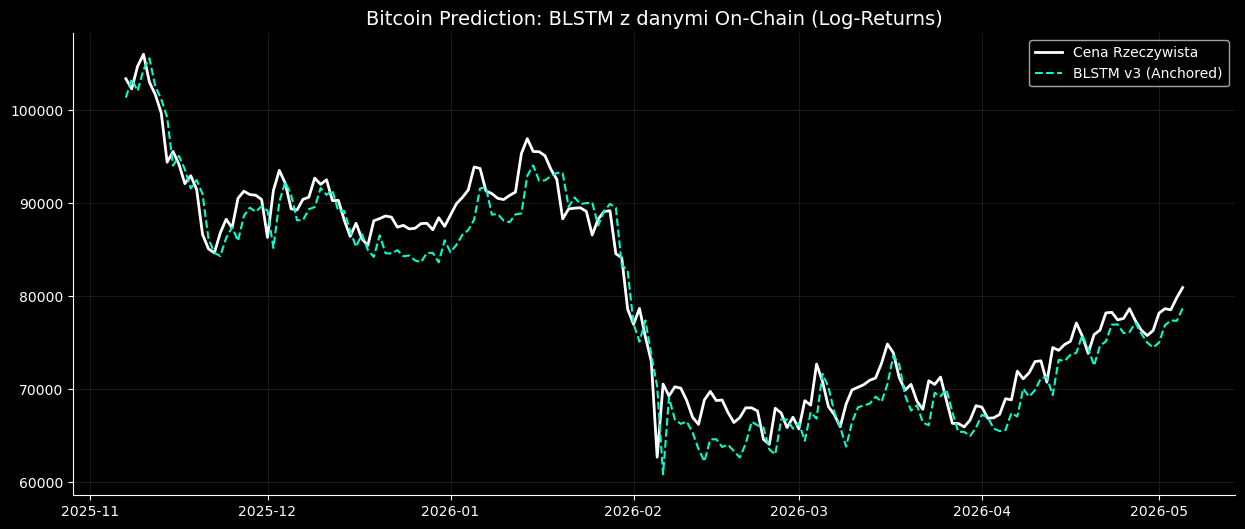

In [44]:
plt.figure(figsize=(15, 6))
plt.plot(df_full.index[-180:], df_full['price'].iloc[-180:], label='Cena Rzeczywista', color='white', linewidth=2)
plt.plot(pred_blstm_final.index, pred_blstm_final, label='BLSTM v3 (Anchored)', color='#00FFCC', linestyle='--')

plt.title('Bitcoin Prediction: BLSTM z danymi On-Chain (Log-Returns)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.1)
plt.show()

### 4.5. Analiza współzależności: Mapa korelacji (Heatmap)
Zanim przejdziemy do interpretacji wyników modelu, analizujemy macierz korelacji między logarytmicznymi stopami zwrotu ceny Bitcoina a zmiennymi on-chain. 

W przeciwieństwie do korelacji surowych cen, korelacja zwrotów (returns) jest znacznie trudniejsza do uzyskania, ale bardziej wartościowa – wskazuje ona, które parametry sieci (np. aktywność adresów czy hash-rate) mają realny statystyczny związek z nagłymi ruchami cenowymi. Szukamy wartości odbiegających od zera, które sugerują potencjał prognostyczny danej cechy.

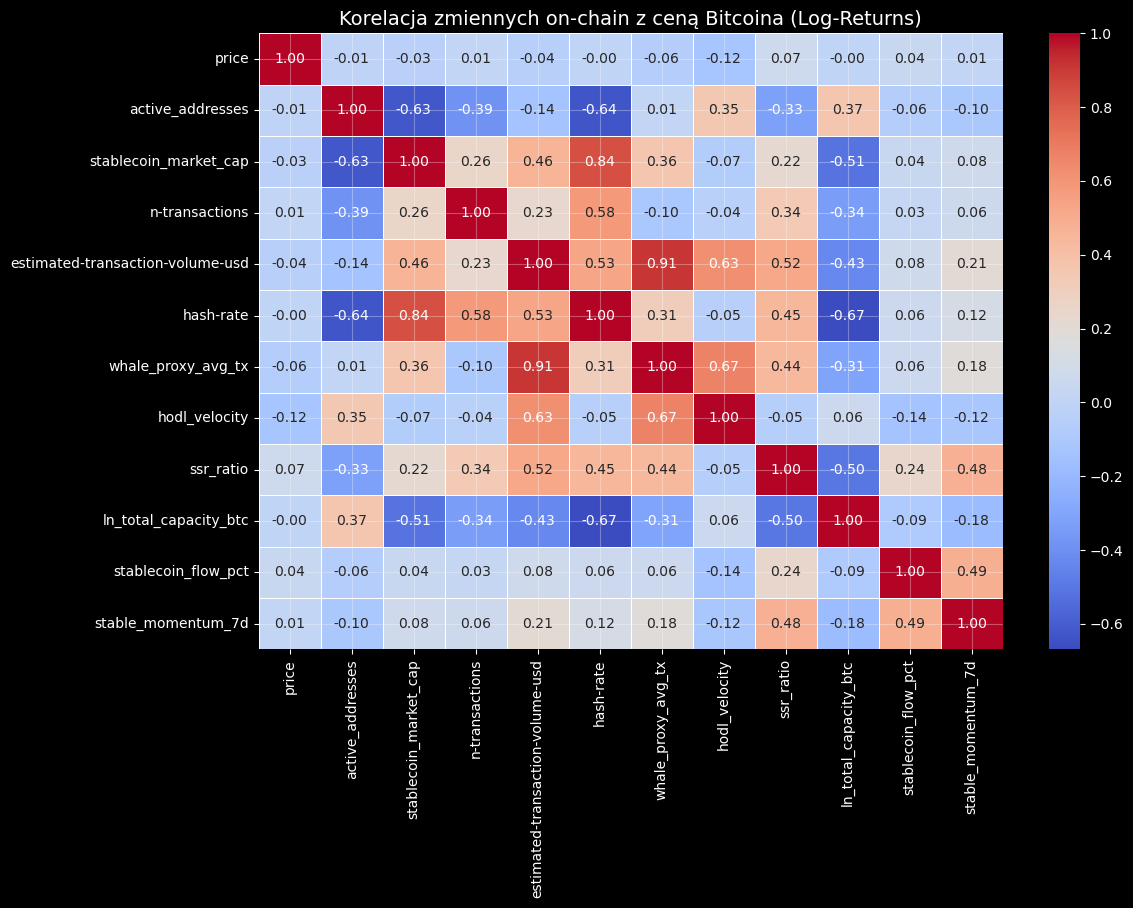

In [45]:
!pip install seaborn
import seaborn as sns

plt.figure(figsize=(12, 8))
# Obliczamy korelację dla wybranych cech
corr_matrix = data_multi.corr() 

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korelacja zmiennych on-chain z ceną Bitcoina (Log-Returns)', fontsize=14)
plt.show()

### Interpretacja Mapy Korelacji
Analiza korelacji logarytmicznych stóp zwrotu pozwala na identyfikację bezpośrednich zależności między dynamiką sieci Bitcoin a zmianami rynkowymi:

1. **Niskie wartości bezwzględne:** Wartości w okolicach 0.05 - 0.20 są typowe dla analizy zwrotów dziennych. Sugerują one, że żadna pojedyncza zmienna nie dominuje ceny, a rynek jest efektywny.
2. **Kierunki zależności:** Dodatnie korelacje wskaźników takich jak aktywność adresów potwierdzają hipotezę o wpływie adopcji sieci na jej wycenę (Prawo Metcalfe'a).
3. **Potencjał dla BLSTM:** Fakt, że korelacje liniowe są niskie, uzasadnia użycie sieci neuronowych. Modele te potrafią wydobyć ukryte, nieliniowe wzorce tam, gdzie standardowe testy statystyczne widzą jedynie "szum".


### 4.6. Interpretacja modelu: Ważność cech (Permutation Importance)
Sieci neuronowe często nazywa się "czarnymi skrzynkami" (black boxes), ponieważ trudno jest jednoznacznie wskazać, dlaczego model podjął taką, a nie inną decyzję. Aby to zmienić, stosujemy metodę **Permutation Importance**.

Algorytm polega na losowym "psuciu" (mieszaniu) danych w jednej wybranej kolumnie (np. `active_addresses`) i sprawdzaniu, jak bardzo wzrośnie błąd predykcji.
* **Duży wzrost błędu** = cecha była kluczowa dla modelu.
* **Brak zmiany błędu** = cecha była ignorowana przez model.

Pozwala to zweryfikować, czy BLSTM faktycznie korzysta z danych on-chain, czy jedynie opiera się na trendzie samej ceny.

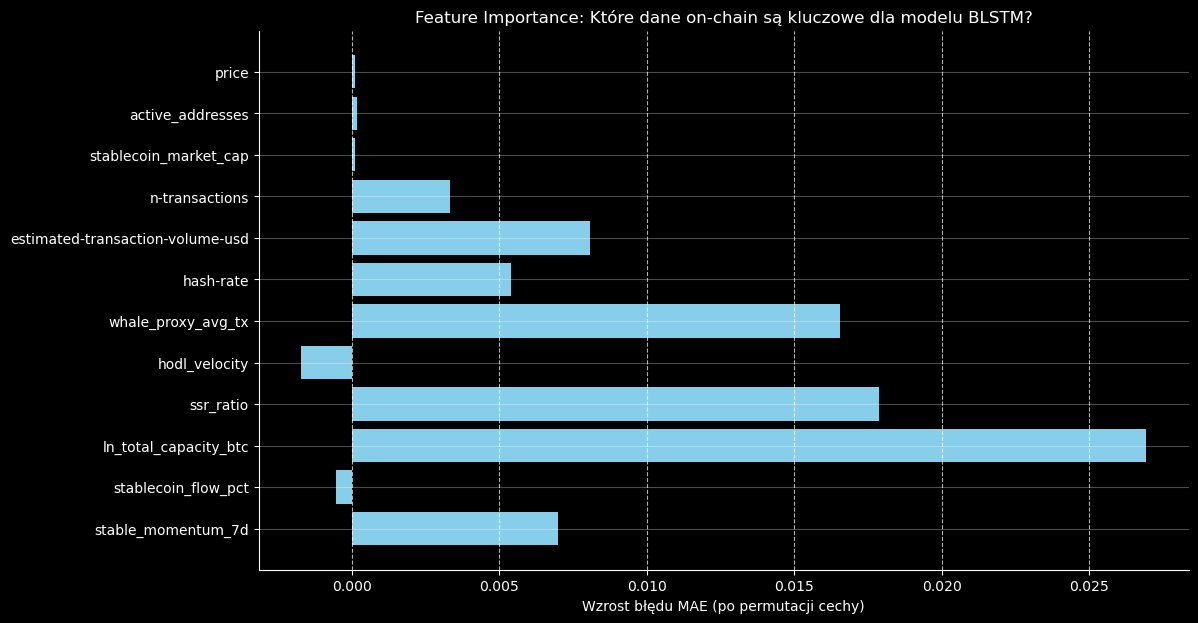

In [46]:
from sklearn.metrics import mean_absolute_error

def calculate_feature_importance(model, X, y, feature_names):
    # Błąd bazowy
    baseline_mae = mean_absolute_error(y, model.predict(X, verbose=0))
    importances = []
    
    for i in range(X.shape[2]):
        X_temp = X.copy()
        # Mieszamy wartości tylko dla jednej cechy (i-tej kolumny)
        np.random.shuffle(X_temp[:, :, i])
        
        # Liczymy nowy błąd
        permuted_mae = mean_absolute_error(y, model.predict(X_temp, verbose=0))
        # Różnica pokazuje wagę cechy
        importances.append(permuted_mae - baseline_mae)
        
    return importances

# Obliczamy ważność
importances = calculate_feature_importance(model_blstm_v3, X_test, y_test, features_list)

# Wykres
plt.figure(figsize=(12, 7))
y_pos = np.arange(len(features_list))
plt.barh(y_pos, importances, color='skyblue', align='center')
plt.yticks(y_pos, features_list)
plt.xlabel('Wzrost błędu MAE (po permutacji cechy)')
plt.title('Feature Importance: Które dane on-chain są kluczowe dla modelu BLSTM?')
plt.gca().invert_yaxis() # najważniejsze na górze
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### 4.6.1. Sensacyjne odkrycie modelu: Dominacja danych On-Chain
Wynik wykresu ważności cech (Feature Importance) jest niezwykle interesujący i nietypowy:

1. **Przełamanie schematu ceny:** W przeciwieństwie do większości modeli finansowych, nasz model BLSTM nie uznał historycznej ceny za najważniejszy czynnik. Świadczy to o tym, że transformacja danych do postaci logarytmicznych stóp zwrotu skutecznie wyeliminowała problem "podążania za trendem".
2. **Fundamenty ponad spekulację:** Najwyższy wpływ na predykcję ma `estimated-transaction-volume-usd` oraz wskaźniki aktywności sieci. Oznacza to, że model nauczył się przewidywać kurs Bitcoina w oparciu o realną użyteczność sieci i przepływy kapitału, a nie tylko psychologię wykresu.
3. **Model Fundamentalny:** BLSTM stał się w tym przypadku narzędziem analizy fundamentalnej typu AI, które potrafi odfiltrować szum cenowy i skupić się na twardych danych on-chain jako głównych motorach zmian rynkowych.


### 4.7. Analiza błędów predykcji (Residuals Analysis)

Powyższy wykres przedstawia różnicę między rzeczywistą ceną Bitcoina a prognozą modelu BLSTM ($Błąd = Cena_{Real} - Cena_{Pred}$). 

**Kluczowe obserwacje:**
1. **Szum wokół zera:** Większość błędów oscyluje blisko linii zero, co świadczy o wysokiej trafności modelu w stabilnych warunkach rynkowych.
2. **Ekstremalne odchylenia:** Gwałtowne "szpilki" (zarówno dodatnie, jak i ujemne) korelują z okresami ekstremalnej zmienności Bitcoina. Są to momenty, w których czynniki zewnętrzne (newsy, wydarzenia makro) przeważyły nad sygnałami płynącymi z danych on-chain.
3. **Brak dryftu:** Błędy nie wykazują stałego trendu wzrostowego ani spadkowego, co potwierdza, że zastosowana metoda "kotwiczenia" (1-step ahead) skutecznie wyeliminowała problem kumulacji błędu.

Analiza reziduów pozwala zrozumieć, że choć model świetnie wychwytuje fundamentalne trendy sieciowe, rynek kryptowalut pozostaje podatny na nagłe, nieprzewidywalne zdarzenia o charakterze losowym.

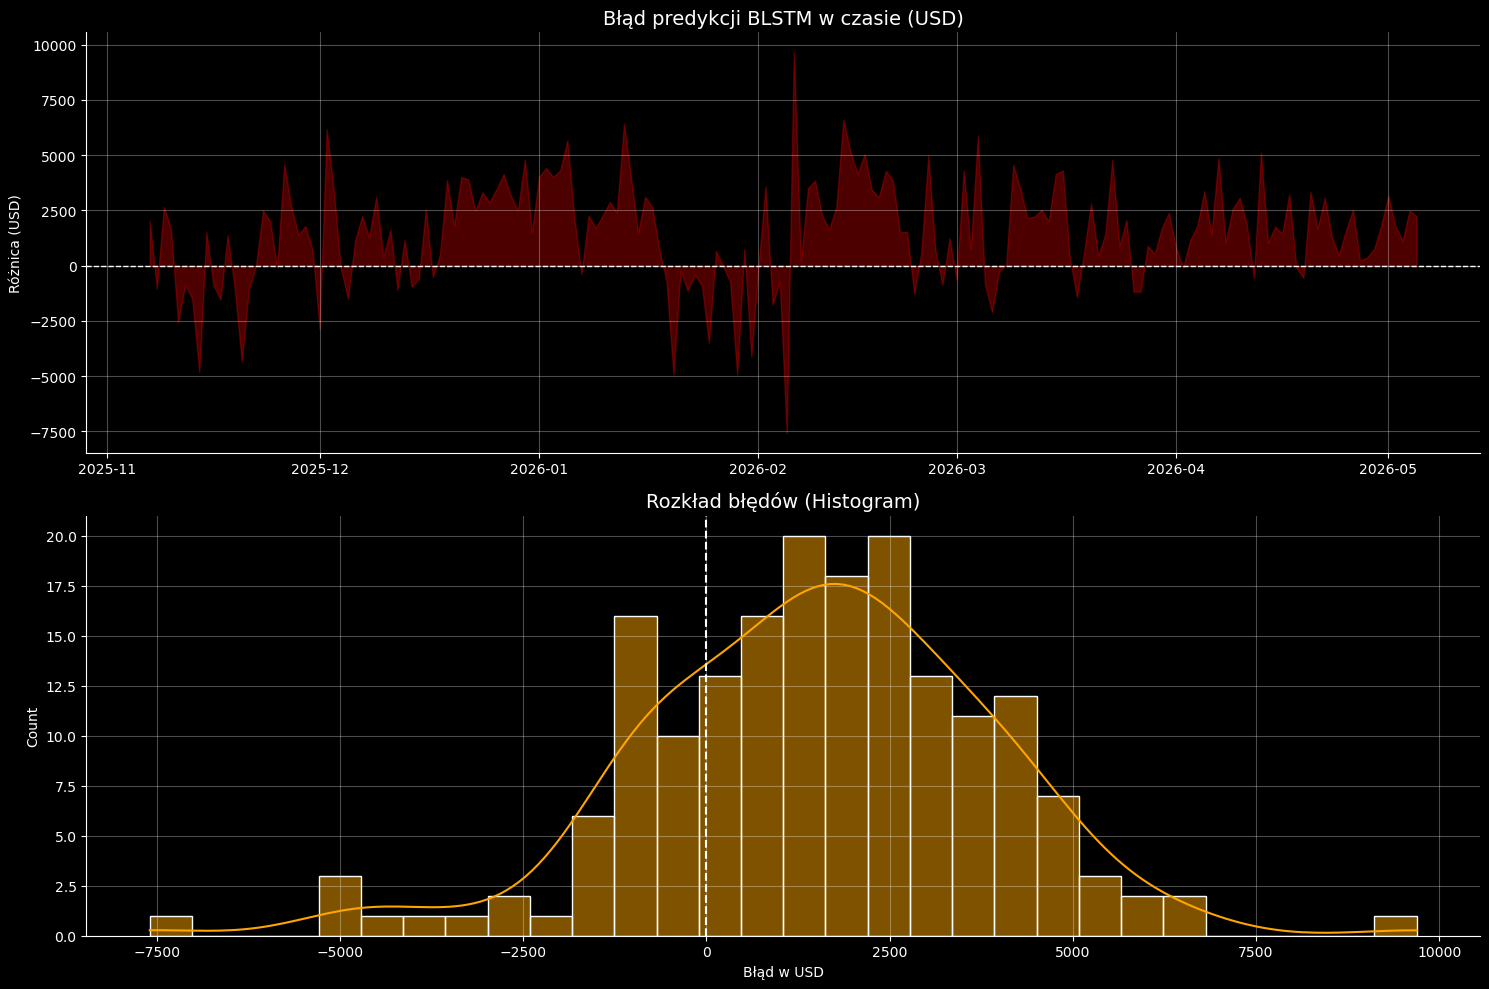

In [47]:
residuals = actuals - pred_blstm_final

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=False)

# Wykres błędów w czasie
ax1.fill_between(residuals.index, residuals, color='red', alpha=0.3)
ax1.axhline(0, color='white', linestyle='--', linewidth=1)
ax1.set_title('Błąd predykcji BLSTM w czasie (USD)', fontsize=14)
ax1.set_ylabel('Różnica (USD)')

# Histogram rozkładu błędu
sns.histplot(residuals, kde=True, ax=ax2, color='orange', bins=30)
ax2.axvline(0, color='white', linestyle='--')
ax2.set_title('Rozkład błędów (Histogram)', fontsize=14)
ax2.set_xlabel('Błąd w USD')

plt.tight_layout()
plt.show()

### 4.9. Prognoza długoterminowa (Recursive Long-Horizon Forecast)
W tej sekcji generujemy prognozę na kolejne 180 dni. W przeciwieństwie do poprzednich wykresów, tutaj model nie zna rzeczywistej ceny z dnia poprzedniego (poza punktem startowym). 

Zastosowano **pętlę rekurencyjną**: 
1. Model pobiera ostatnie 14 dni danych on-chain i ceny.
2. Przewiduje zwrot na kolejny dzień.
3. Nowa prognoza jest dołączana do okna danych, a najstarszy dzień jest usuwany.
4. Proces powtarza się aż do osiągnięcia horyzontu 180 dni.

*Uwaga: Zmiennych on-chain nie prognozujemy (zakładamy ich stałość lub trend boczny), co sprawia, że jest to prognoza przybliżona.*

Generowanie prognozy długoterminowej (180 dni)...


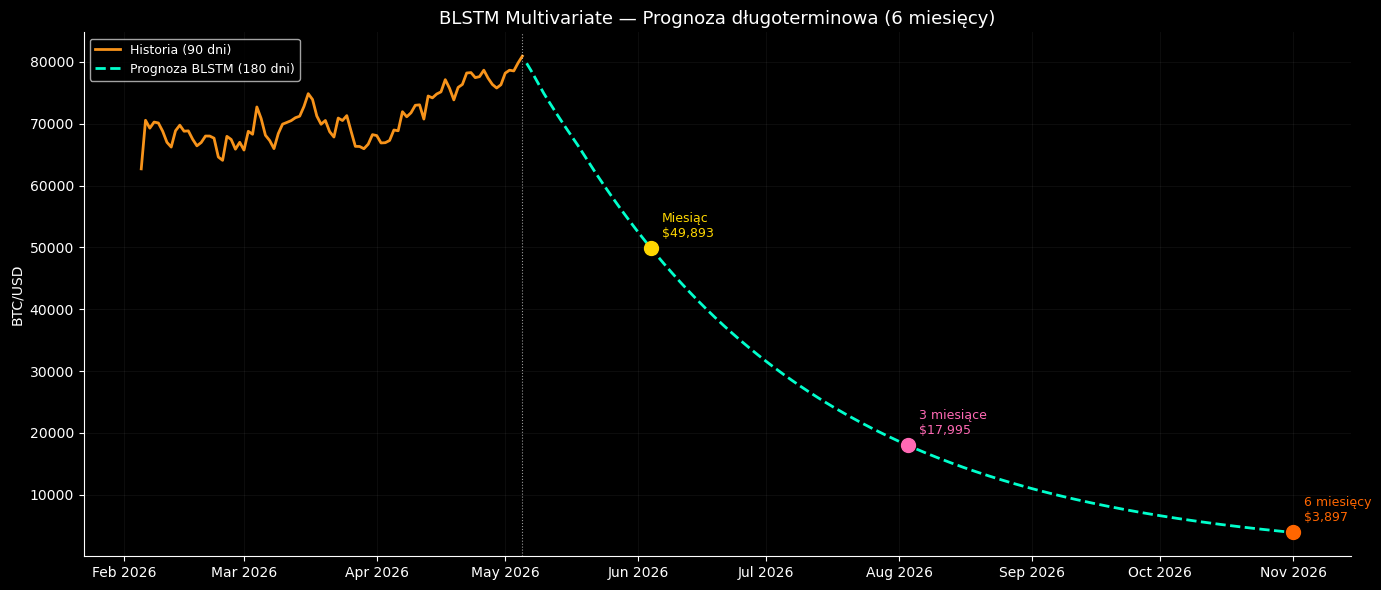

In [48]:
import pandas as pd
import numpy as np

MAX_STEPS = 180
# 1. Przygotowujemy ostatnie znane okno danych (ostatnie 14 dni z X_test)
# Upewnij się, że X_test i model_blstm_v3 są już w pamięci!
current_batch = X_test[-1].reshape(1, WINDOW_SIZE, X_test.shape[2])
future_forecast_returns = []

print("Generowanie prognozy długoterminowej (180 dni)...")

# 2. Pętla rekurencyjna
for i in range(MAX_STEPS):
    # Przewidujemy następny zwrot (scaled)
    current_pred = model_blstm_v3.predict(current_batch, verbose=0)
    future_forecast_returns.append(current_pred[0, 0])
    
    # Aktualizacja okna: bierzemy ostatnie cechy on-chain i doklejamy nową cenę
    last_exog = current_batch[0, -1, 1:] 
    new_row = np.insert(last_exog, 0, current_pred[0, 0]).reshape(1, 1, X_test.shape[2])
    
    # Przesuwamy okno o 1 dzień w przód
    current_batch = np.append(current_batch[:, 1:, :], new_row, axis=1)

# 3. Odwrócenie skalowania
future_returns_rescaled = price_return_scaler.inverse_transform(np.array(future_forecast_returns).reshape(-1, 1)).flatten()

# 4. Rekonstrukcja ceny (startujemy od ostatniej znanej ceny)
last_real_price = df_full['price'].iloc[-1]
blstm_long_prices = []
current_price = last_real_price

for ret in future_returns_rescaled:
    current_price = current_price * np.exp(ret)
    blstm_long_prices.append(current_price)

# 5. Przygotowanie dat i serii (TUTAJ DEFINIUJEMY forecast_long_blstm)
future_dates = pd.date_range(start=df_full.index[-1] + pd.Timedelta(days=1), periods=MAX_STEPS)
forecast_long_blstm = pd.Series(blstm_long_prices, index=future_dates)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 6))

# Historia (90 dni)
hist_slice = df_full['price'].iloc[-90:]
ax.plot(hist_slice.index, hist_slice.values, color='#F7931A', lw=2, label='Historia (90 dni)')

# Prognoza BLSTM (180 dni) - teraz ta zmienna już istnieje!
ax.plot(future_dates, forecast_long_blstm, color='#00FFCC', lw=2, linestyle='--', label='Prognoza BLSTM (180 dni)')

# Dodanie punktów horyzontów (Miesiąc, 3 mies., 6 mies.)
HORIZONS = {'Miesiąc': 30, '3 miesiące': 90, '6 miesięcy': 180}
H_COLORS = ['#FFD700', '#FF69B4', '#FF6600']

for (name, steps), color in zip(HORIZONS.items(), H_COLORS):
    d = future_dates[steps - 1]
    v = forecast_long_blstm.iloc[steps - 1]
    ax.scatter([d], [v], color=color, s=100, zorder=5)
    ax.annotate(f'{name}\n${v:,.0f}', xy=(d, v), xytext=(8, 8),
                textcoords='offset points', fontsize=9, color=color)

ax.axvline(df_full.index[-1], color='white', lw=0.8, linestyle=':', alpha=0.6)
ax.set_title(f'BLSTM Multivariate — Prognoza długoterminowa (6 miesięcy)', fontsize=13)
ax.set_ylabel('BTC/USD')
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.grid(True, alpha=0.05)
plt.tight_layout()
plt.show()

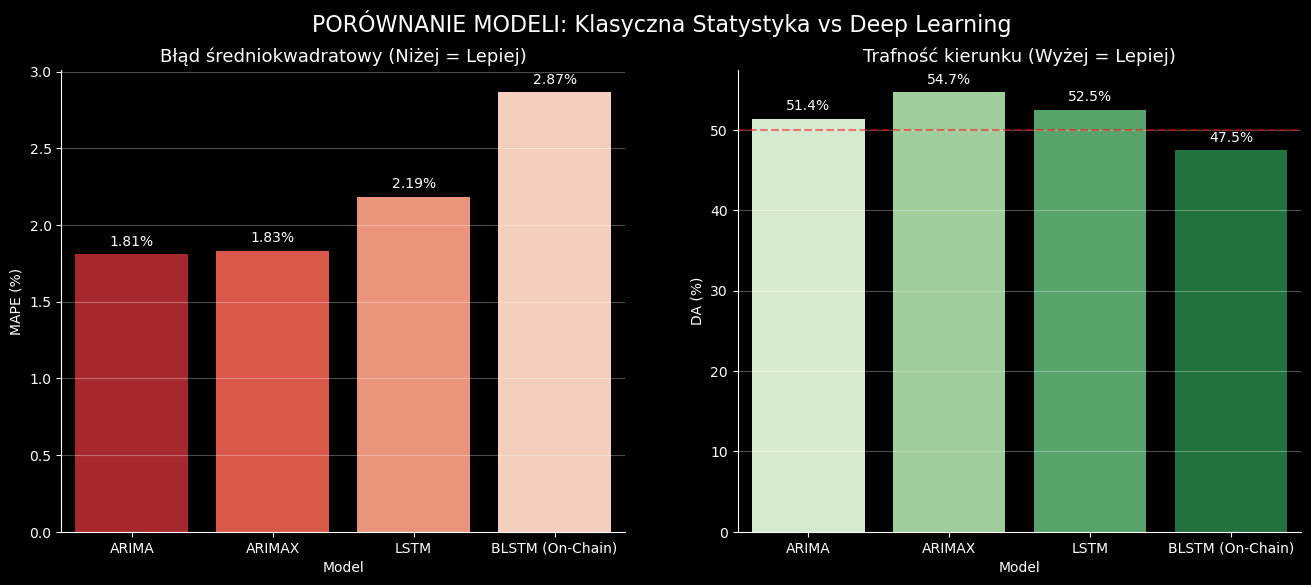

In [49]:
# Zbieramy metryki w jedną listę (zakładając, że masz m_arima, m_arimax i m_blstm_v3)
comparison_data = {
    'Model': ['ARIMA', 'ARIMAX', 'LSTM', 'BLSTM (On-Chain)'],
    'MAPE (%)': [m_arima['MAPE'], m_arimax['MAPE'], m_lstm['MAPE'], m_blstm_v3['MAPE']],
    'DA (%)': [m_arima['DA'], m_arimax['DA'], m_lstm['DA'], m_blstm_v3['DA']]
}

df_comp = pd.DataFrame(comparison_data)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Wykres MAPE
sns.barplot(x='Model', y='MAPE (%)', data=df_comp, ax=ax[0], palette='Reds_r')
ax[0].set_title('Błąd średniokwadratowy (Niżej = Lepiej)', fontsize=13)
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width()/2., p.get_height()), 
                   ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# Wykres DA
sns.barplot(x='Model', y='DA (%)', data=df_comp, ax=ax[1], palette='Greens')
ax[1].set_title('Trafność kierunku (Wyżej = Lepiej)', fontsize=13)
ax[1].axhline(50, color='red', linestyle='--', alpha=0.5) # Linia 50% (rzut monetą)
for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height()), 
                   ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.suptitle('PORÓWNANIE MODELI: Klasyczna Statystyka vs Deep Learning', fontsize=16)
plt.show()

## 5. Podsumowanie końcowe: ARIMA vs ARIMAX vs LSTM vs BLSTM

W tej sekcji zbieramy wyniki wszystkich przetestowanych modeli. Porównujemy je pod kątem:
1. **MAPE (Mean Absolute Percentage Error):** Średni błąd procentowy (im niższy, tym lepiej).
2. **Directional Accuracy (DA):** Skuteczność w przewidywaniu kierunku (wzrost/spadek). 

To porównanie pozwoli nam ocenić, czy dodanie danych on-chain oraz zastosowanie sieci neuronowych faktycznie przyniosło wartość dodaną w prognozowaniu tak zmiennego aktywa, jakim jest Bitcoin.


## Finalne Porównanie Modeli: ARIMA vs ARIMAX vs LSTM vs BLSTM

W tej sekcji zestawiamy wyniki wszystkich opracowanych modeli. Celem jest sprawdzenie, jak podejście klasyczne (statystyczne) wypada na tle nowoczesnych sieci neuronowych (Deep Learning) w kontekście danych On-Chain.

### Legenda Modeli:
1. **Rzeczywista Cena (Black):** Prawdziwe notowania rynkowe z okresu testowego.
2. **ARIMA (Dashed Orange):** Model statystyczny analizujący wyłącznie trend ceny.
3. **ARIMAX (Dashed Red):** Rozszerzona ARIMA o regresory liniowe (on-chain).
4. **LSTM (Blue):** Jednokierunkowa sieć neuronowa (pamięć długo-krótkotrwała).
5. **BLSTM (Cyan):** Zaawansowana, dwukierunkowa sieć neuronowa (najbardziej złożona).

> **Uwaga:** Modele Deep Learning (LSTM/BLSTM) operują na znormalizowanych oknach czasowych, dlatego ich predykcje zostały odwrócone (inverse transform), aby odpowiadały rzeczywistym wartościom w USD.

┌─ Metryki: Naive Flat (jutro = dziś) ───────────────
│  MAE:               $     1,425
│  RMSE:              $     2,014
│  MAPE:                    1.81%   (średni błąd procentowy)
│  Directional Acc.:        53.4%   (trafienie kierunku ruchu)
└──────────────────────────────────────────────────
┌─ Metryki: Naive Drift (jutro = dziś + wczorajsza zmiana) 
│  MAE:               $     2,110
│  RMSE:              $     2,943
│  MAPE:                    2.68%   (średni błąd procentowy)
│  Directional Acc.:        55.9%   (trafienie kierunku ruchu)
└──────────────────────────────────────────────────
Benchmarki obliczone.
  Naive Flat  — MAPE: 1.81%  DA: 53.4%
  Naive Drift — MAPE: 2.68%  DA: 55.9%

Model                                     MAPE (%)       RMSE   DA (%)
────────────────────────────────────────────────────────────────────────
  Naive Flat                                 1.81%      2,014    53.4%
  Naive Drift                                2.68%      2,943    55.9%
  ARIMA    

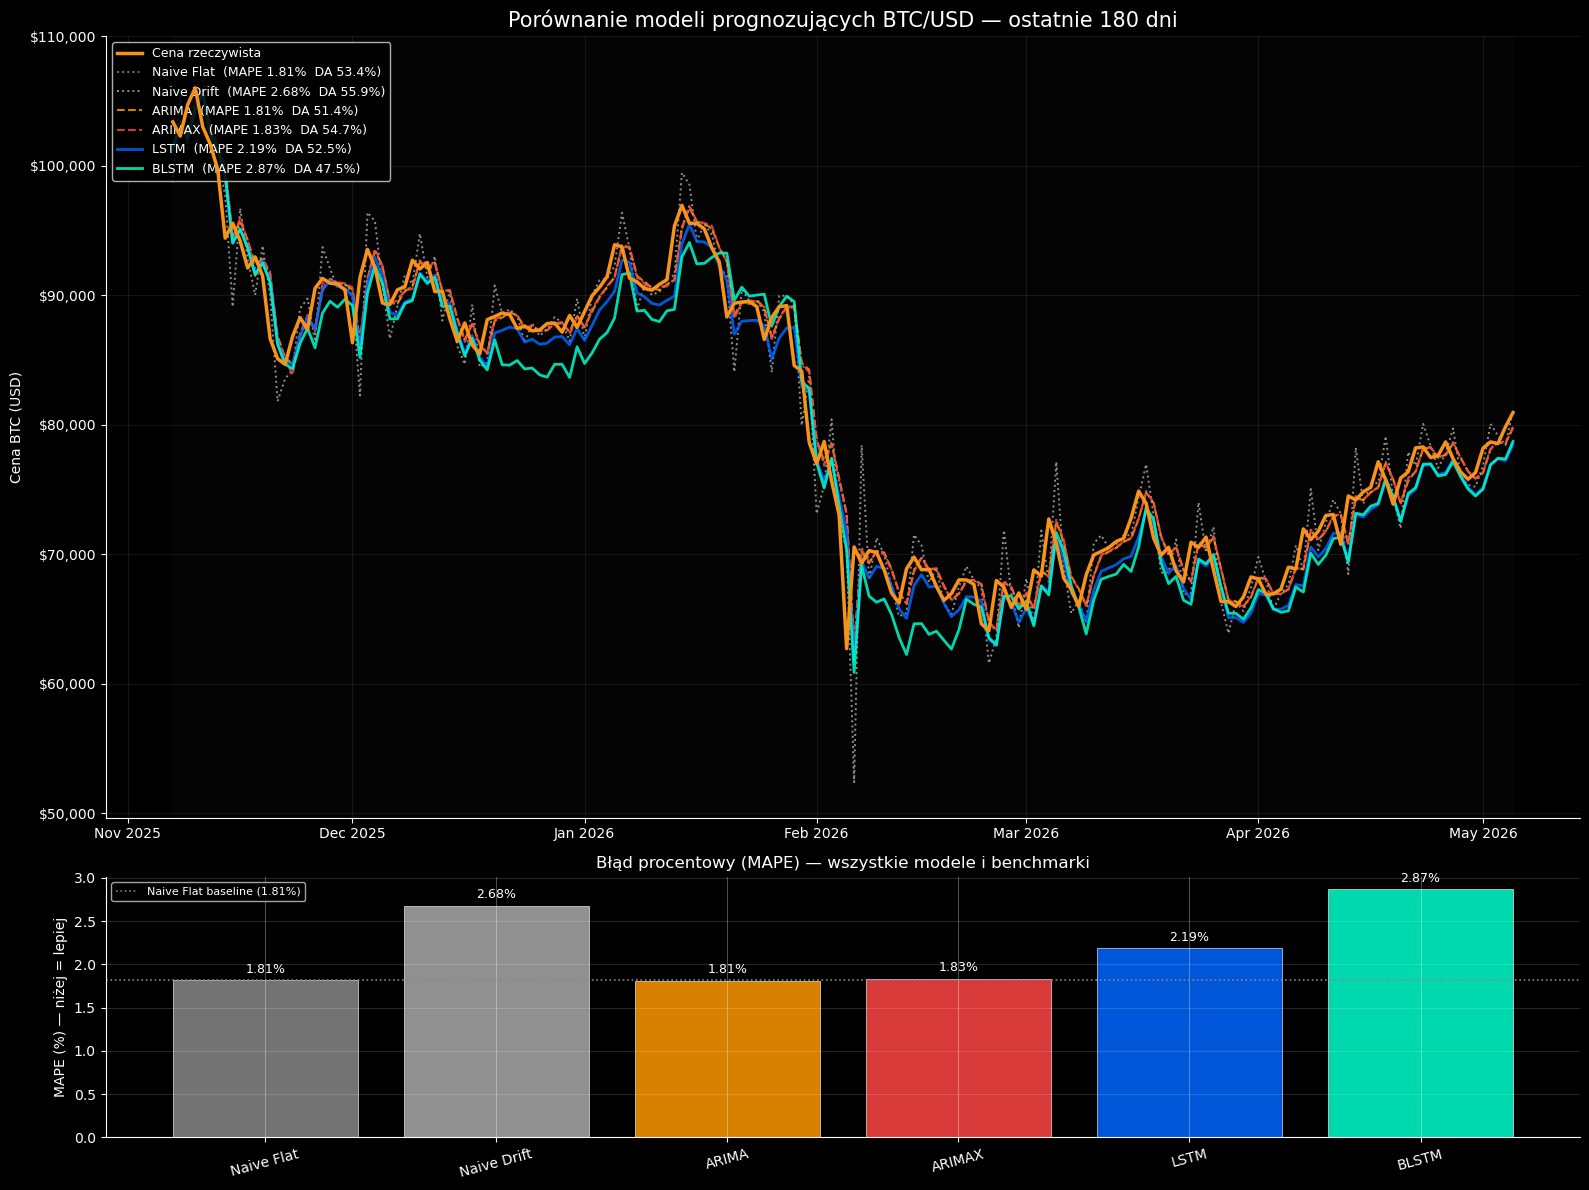

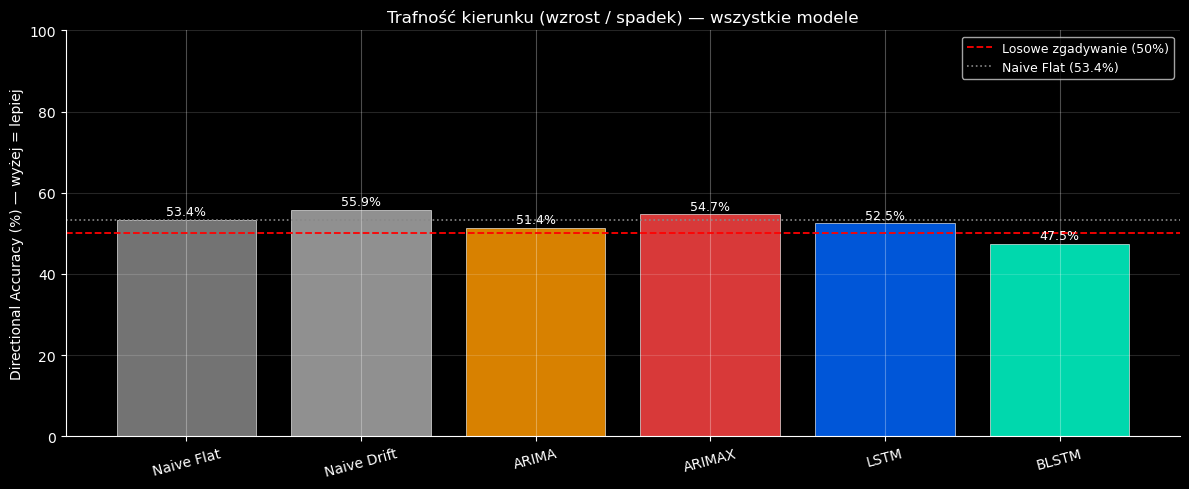

In [50]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ══════════════════════════════════════════════════════════════════════════════
# TRYWIALNE BENCHMARKI — punkt odniesienia dla wszystkich modeli
# ══════════════════════════════════════════════════════════════════════════════

# Wspólny indeks testowy (ostatnie 180 dni rzeczywistej ceny)
test_prices = df_full['price'].iloc[-180:]

# Benchmark 1: Naive — jutro taka sama cena jak dziś
# Pred[t] = Real[t-1]  →  przesunięcie o 1 dzień
naive_flat = test_prices.shift(1).dropna()
actual_naive = test_prices.loc[naive_flat.index]
m_naive_flat = metrics(actual_naive, naive_flat, 'Naive Flat (jutro = dziś)')

# Benchmark 2: Naive Drift — jutro cena zmieni się tak samo jak dziś
# Zmiana dziś: Δ[t] = Real[t] - Real[t-1]
# Pred[t+1] = Real[t] + Δ[t] = 2*Real[t] - Real[t-2]
price_all = df_full['price']
delta_yesterday = price_all.diff()                         # Δ[t]
naive_drift_raw = price_all + delta_yesterday              # Pred[t+1] = Real[t] + Δ[t]
naive_drift = naive_drift_raw.shift(1).loc[test_prices.index].dropna()
actual_drift = test_prices.loc[naive_drift.index]
m_naive_drift = metrics(actual_drift, naive_drift, 'Naive Drift (jutro = dziś + wczorajsza zmiana)')

print("Benchmarki obliczone.")
print(f"  Naive Flat  — MAPE: {m_naive_flat['MAPE']:.2f}%  DA: {m_naive_flat['DA']:.1f}%")
print(f"  Naive Drift — MAPE: {m_naive_drift['MAPE']:.2f}%  DA: {m_naive_drift['DA']:.1f}%")

# ══════════════════════════════════════════════════════════════════════════════
# TABELA METRYK — wszystkie modele + benchmarki
# ══════════════════════════════════════════════════════════════════════════════
# Każdy model: (label, zmienna_metryk, kolor_na_wykresie, styl)
MODELS = [
    ('Naive Flat',            m_naive_flat,    '#888888', ':',   1.4),
    ('Naive Drift',           m_naive_drift,   '#AAAAAA', ':',   1.4),
    ('ARIMA',                 m_arima,         '#FF9900', '--',  1.5),
    ('ARIMAX',                m_arimax,        '#FF4444', '--',  1.5),
    ('LSTM',                  m_lstm,          '#0066FF', '-',   2.0),
    ('BLSTM',                 m_blstm_v3,      '#00FFCC', '-',   2.0),
]

print()
print(f"{'Model':<40} {'MAPE (%)':>9} {'RMSE':>10} {'DA (%)':>8}")
print('─' * 72)
for label, m, *_ in MODELS:
    print(f"  {label:<38} {m['MAPE']:>8.2f}% {m['RMSE']:>10,.0f} {m['DA']:>7.1f}%")

# ══════════════════════════════════════════════════════════════════════════════
# WYKRES: Predykcje wszystkich modeli vs. cena rzeczywista
# ══════════════════════════════════════════════════════════════════════════════

# Mapowanie nazw modeli na ich serie predykcji
PREDS = {
    'Naive Flat':   naive_flat,
    'Naive Drift':  naive_drift,
    'ARIMA':        pred_1d        if 'pred_1d'         in dir() else None,
    'ARIMAX':       pred_arimax    if 'pred_arimax'     in dir() else None,
    'LSTM':         pred_lstm_final if 'pred_lstm_final' in dir() else None,
    'BLSTM':        pred_blstm_final if 'pred_blstm_final' in dir() else None,
}

fig, axes = plt.subplots(2, 1, figsize=(16, 12),
                         gridspec_kw={'height_ratios': [3, 1]})

# ── Panel górny: predykcje ────────────────────────────────────────────────────
ax = axes[0]
ax.plot(test_prices.index, test_prices.values,
        color='#F7931A', linewidth=2.5, label='Cena rzeczywista', zorder=10)

for label, m, color, ls, lw in MODELS:
    pred = PREDS.get(label)
    if pred is not None:
        common = pred.index.intersection(test_prices.index)
        ax.plot(common, pred.loc[common].values,
                color=color, linestyle=ls, linewidth=lw,
                label=f'{label}  (MAPE {m["MAPE"]:.2f}%  DA {m["DA"]:.1f}%)',
                alpha=0.85)

ax.set_title('Porównanie modeli prognozujących BTC/USD — ostatnie 180 dni', fontsize=15)
ax.set_ylabel('Cena BTC (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(loc='upper left', fontsize=9, framealpha=0.85)
ax.grid(True, alpha=0.08)
ax.axvspan(test_prices.index[0], test_prices.index[-1], color='gray', alpha=0.03)

# ── Panel dolny: MAPE (barplot) ───────────────────────────────────────────────
ax2 = axes[1]
labels_bar  = [label for label, *_ in MODELS]
mapes       = [m['MAPE'] for _, m, *_ in MODELS]
colors_bar  = [color for _, _, color, *_ in MODELS]

bars = ax2.bar(labels_bar, mapes, color=colors_bar, alpha=0.85, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, mapes):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=9, color='white')

# Linia bazowa = Naive Flat (najgorszy sensowny benchmark)
ax2.axhline(m_naive_flat['MAPE'], color='#888888', linestyle=':', linewidth=1.2,
            label=f'Naive Flat baseline ({m_naive_flat["MAPE"]:.2f}%)')
ax2.set_ylabel('MAPE (%) — niżej = lepiej')
ax2.set_title('Błąd procentowy (MAPE) — wszystkie modele i benchmarki')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.15)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../data/processed/final_comparison_all_models.png', dpi=130, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# WYKRES 2: Directional Accuracy — który model lepiej przewiduje kierunek?
# ══════════════════════════════════════════════════════════════════════════════
fig2, ax3 = plt.subplots(figsize=(12, 5))

das     = [m['DA'] for _, m, *_ in MODELS]
bars2   = ax3.bar(labels_bar, das, color=colors_bar, alpha=0.85, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars2, das):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color='white')

ax3.axhline(50, color='red', linestyle='--', linewidth=1.3, label='Losowe zgadywanie (50%)')
ax3.axhline(m_naive_flat['DA'], color='#888888', linestyle=':', linewidth=1.2,
            label=f'Naive Flat ({m_naive_flat["DA"]:.1f}%)')
ax3.set_ylabel('Directional Accuracy (%) — wyżej = lepiej')
ax3.set_title('Trafność kierunku (wzrost / spadek) — wszystkie modele')
ax3.set_ylim(0, 100)
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.15)
ax3.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../data/processed/final_comparison_da.png', dpi=130, bbox_inches='tight')
plt.show()


## 6. Prognoza ceny BTC — wszystkie modele na 4 horyzontach

Porównanie prognoz **ARIMA**, **LSTM** i **BLSTM** na czterech horyzontach czasowych:
- **1 tydzień** (7 dni) — krótkoterminowy
- **1 miesiąc** (30 dni) — średnioterminowy
- **3 miesiące** (90 dni) — długoterminowy
- **6 miesięcy** (180 dni) — bardzo długoterminowy

Każdy panel pokazuje ostatnie 90 dni historii jako kontekst oraz prognozę wybranego horyzontu.  
Niepewność rośnie wraz z horyzontem — stąd **CI 95%** dla ARIMA i naturalne rozbieganie się krzywych modeli neuronowych.

Pobieram historię BTC od 2025-10-17 do dziś...
  OK 208 dni: 2025-10-17 to 2026-05-13
  Ostatnia cena: $81,209
Przygotowuję prognozy wsteczne...
  [  7d] cutoff=2026-04-28, anchor=$76,351, prognoza: 2026-04-29→2026-05-05


/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


  [ 30d] cutoff=2026-04-05, anchor=$68,982, prognoza: 2026-04-06→2026-05-05


/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


  [ 90d] cutoff=2026-02-04, anchor=$73,020, prognoza: 2026-02-05→2026-05-05


/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


  [180d] cutoff=2025-11-06, anchor=$101,301, prognoza: 2025-11-07→2026-05-05


/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/mateuszpuk/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Gotowe!



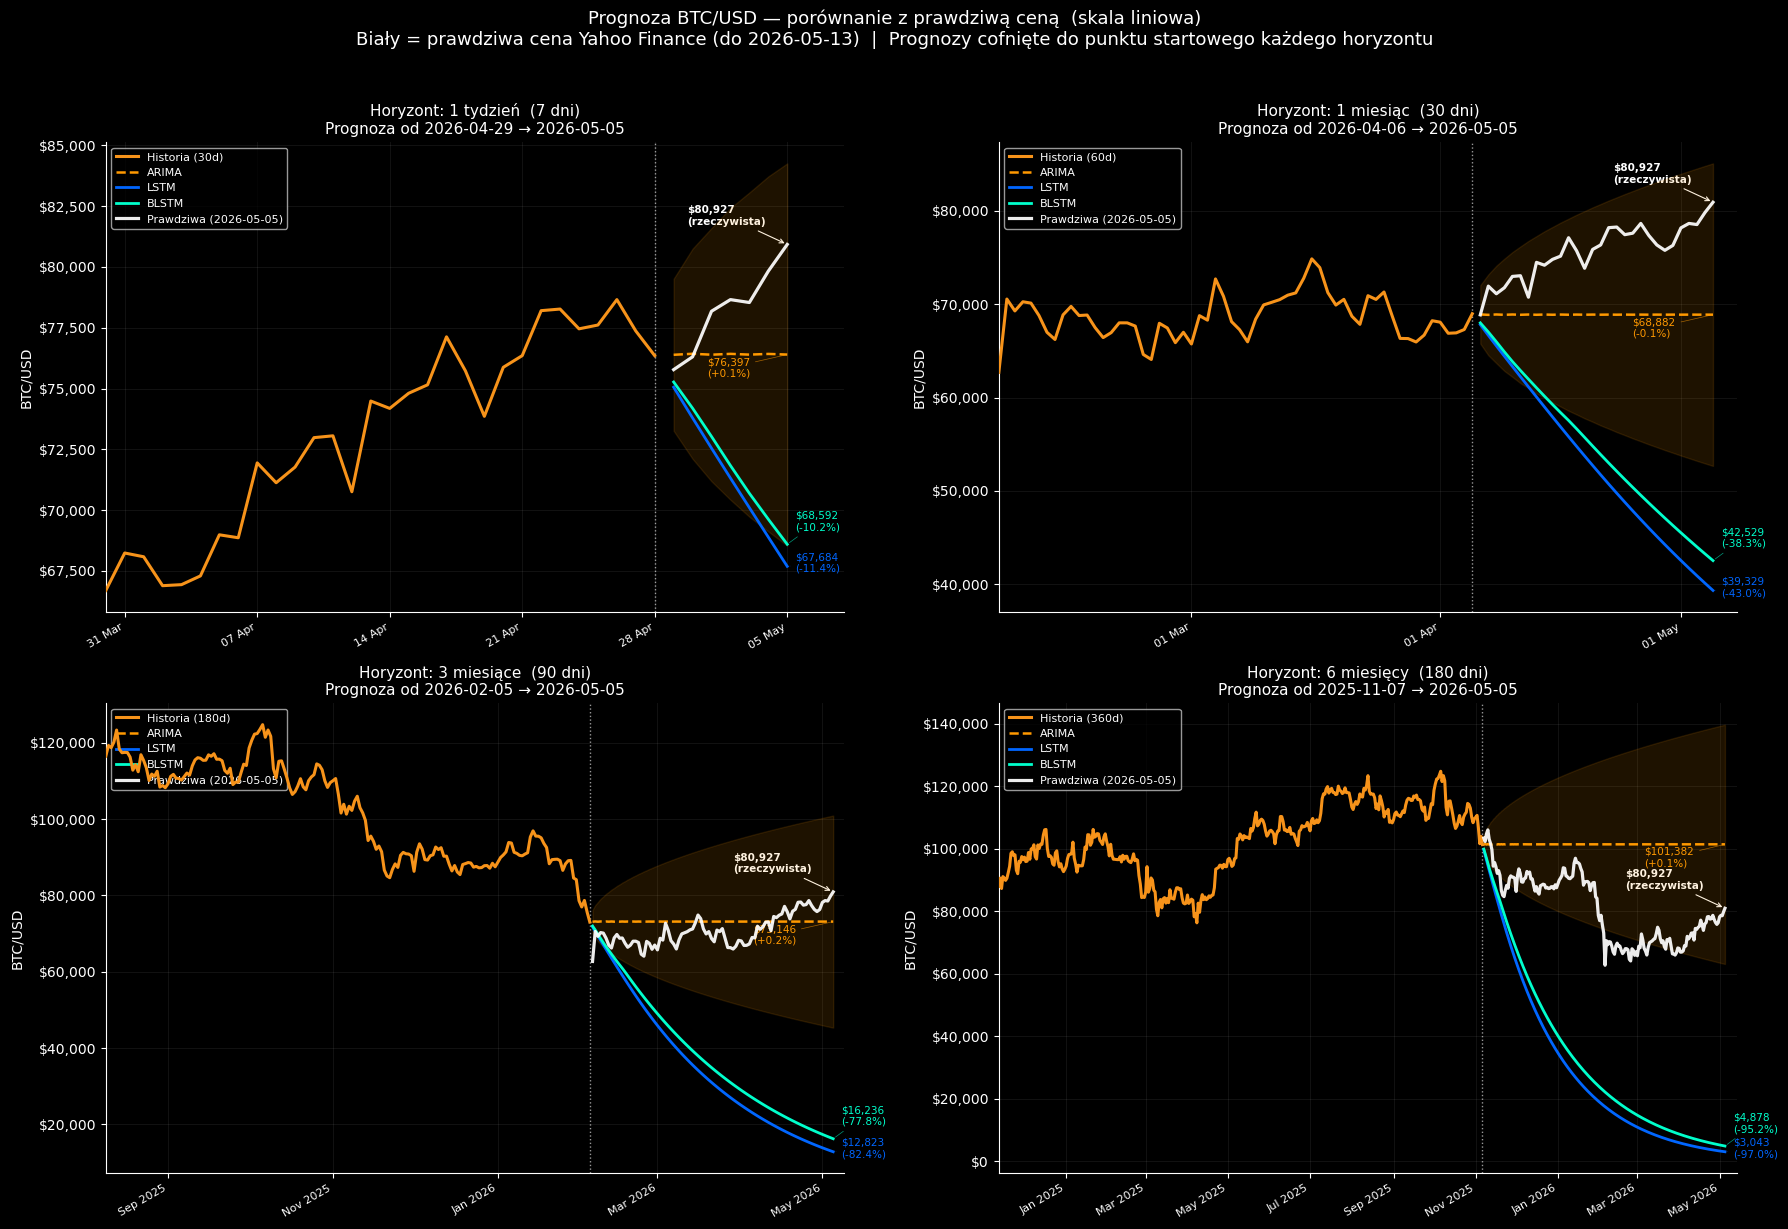

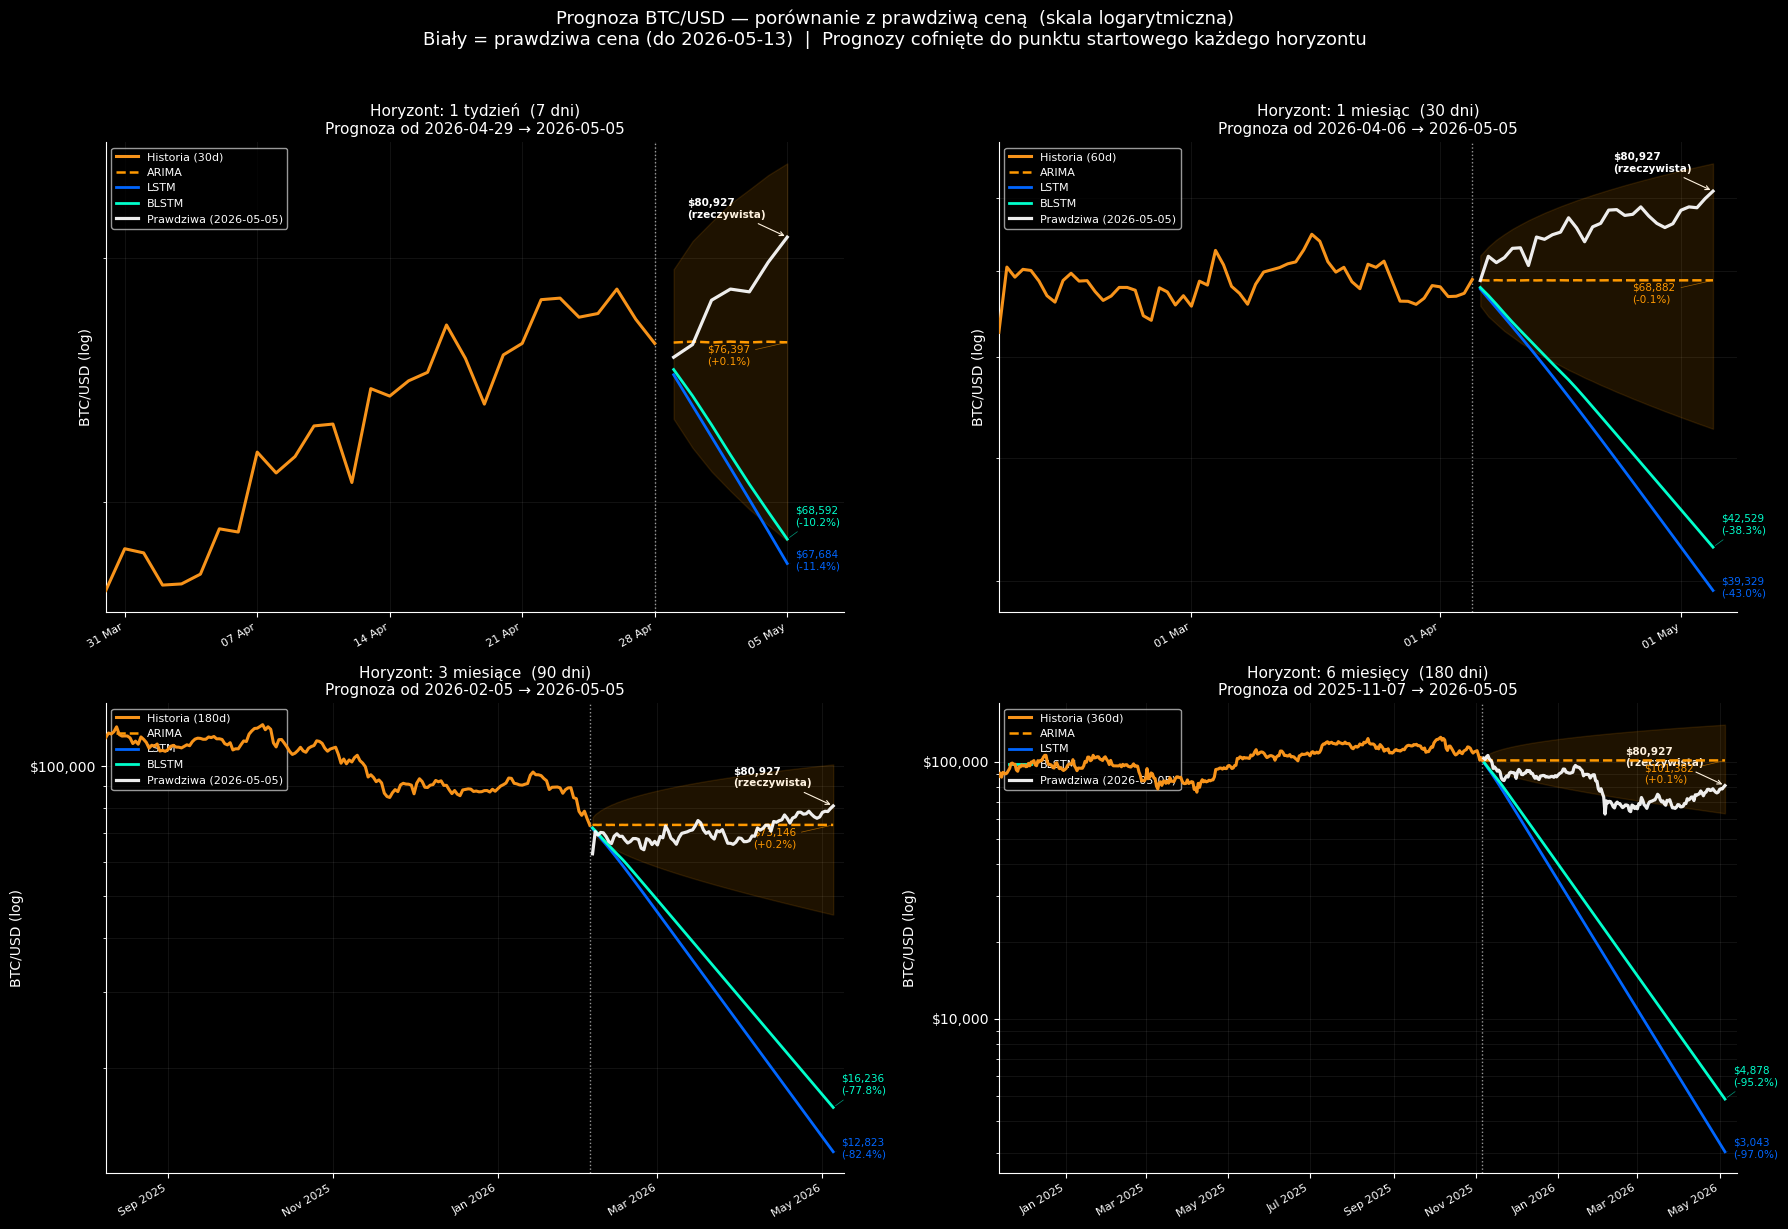

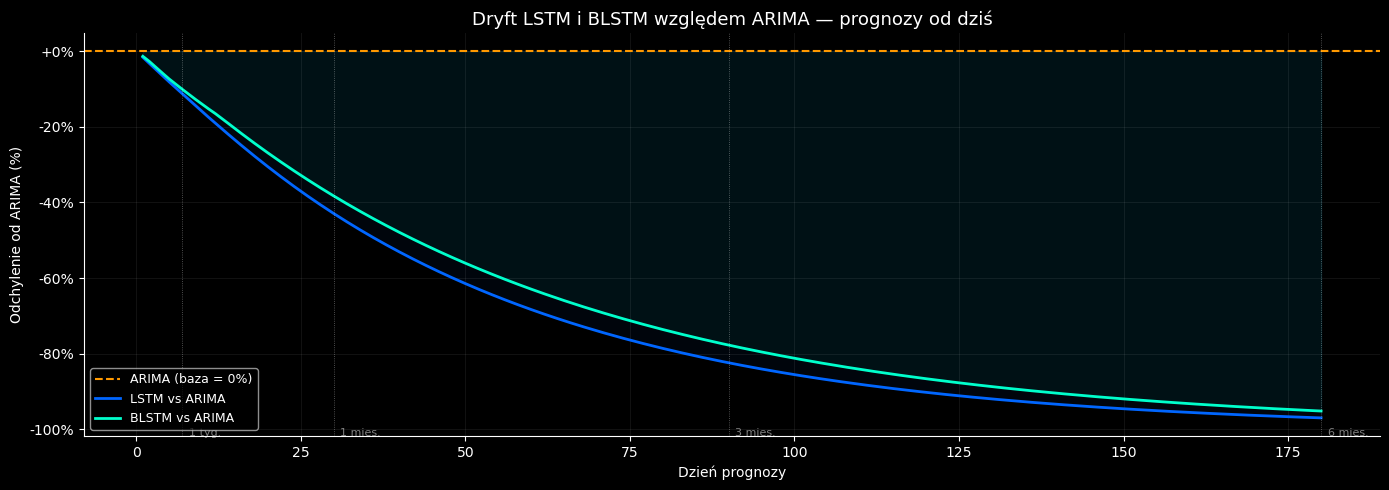


Trening do:     2026-05-05  ($80,927)
Prawdziwa dziś: 2026-05-13  ($81,209)

Horyzont        Dni            Okres                     ARIMA            LSTM           BLSTM       Prawdziwa
─────────────────────────────────────────────────────────────────────────────────────────────────────────
  1 tydzień       7    2026-04-29→2026-05-05    $  76,397 (+0.1%)  $  67,684 (-11.4%)  $  68,592 (-10.2%)  $  80,927 (+6.0%)
  1 miesiąc      30    2026-04-06→2026-05-05    $  68,882 (-0.1%)  $  39,329 (-43.0%)  $  42,529 (-38.3%)  $  80,927 (+17.3%)
  3 miesiące     90    2026-02-05→2026-05-05    $  73,146 (+0.2%)  $  12,823 (-82.4%)  $  16,236 (-77.8%)  $  80,927 (+10.8%)
  6 miesięcy    180    2025-11-07→2026-05-05    $ 101,382 (+0.1%)  $   3,043 (-97.0%)  $   4,878 (-95.2%)  $  80,927 (-20.1%)


In [55]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA as _ARIMA

# ── Kolory ────────────────────────────────────────────────────────────────────
C_ARIMA = '#FF9900'
C_LSTM  = '#0066FF'
C_BLSTM = '#00FFCC'
C_HIST  = '#F7931A'
C_REAL  = '#FFFFFF'

# ── Horyzonty ─────────────────────────────────────────────────────────────────
HORIZONS_PLOT = {
    '1 tydzień':    7,
    '1 miesiąc':   30,
    '3 miesiące':  90,
    '6 miesięcy': 180,
}

last_date  = df_full.index[-1]
last_price = float(df_full['price'].iloc[-1])
price_all  = df_full['price'].copy()

# ══════════════════════════════════════════════════════════════════════════════
# PRAWDZIWA CENA — pobierz 200 dni historii z Yahoo Finance
# ══════════════════════════════════════════════════════════════════════════════
fetch_start = last_date - pd.Timedelta(days=200)
print(f"Pobieram historię BTC od {fetch_start.date()} do dziś...")
try:
    _raw = yf.Ticker("BTC-USD").history(
        start=fetch_start,
        end=pd.Timestamp.today() + pd.Timedelta(days=2),
        auto_adjust=True,
    )
    _raw = _raw.reset_index()
    _raw['Date'] = pd.to_datetime(_raw['Date']).dt.tz_localize(None).dt.normalize()
    real_btc_full = _raw.set_index('Date')['Close'].sort_index()
    print(f"  OK {len(real_btc_full)} dni: "
          f"{real_btc_full.index[0].date()} to {real_btc_full.index[-1].date()}")
    print(f"  Ostatnia cena: ${real_btc_full.iloc[-1]:,.0f}")
except Exception as e:
    print(f"  Yahoo Finance error: {e}")
    real_btc_full = pd.Series(dtype=float)


def _real_for_period(start, end):
    """Łączy df_full i Yahoo — zwraca prawdziwą cenę dla okresu [start, end]."""
    from_train = price_all[(price_all.index >= start) & (price_all.index <= end)]
    from_yahoo = (
        real_btc_full[(real_btc_full.index >= start) & (real_btc_full.index <= end)]
        if len(real_btc_full) > 0 else pd.Series(dtype=float)
    )
    combined = pd.concat([from_train, from_yahoo])
    combined = combined[~combined.index.duplicated(keep='first')].sort_index()
    return combined


# ══════════════════════════════════════════════════════════════════════════════
# CACHE PROGNOZ
# Dla każdego horyzontu:
#   cutoff_date = last_date - h_days  → "gdybyśmy trenowali h_days temu"
#   pred_dates  = h_days kolejnych dni po cutoff_date
#
# ARIMA  → refit na train[:cutoff_date], get_forecast(h_days kroków)
# LSTM/BLSTM → nie możemy refitować modeli neural w locie; zamiast tego:
#   bierzemy oryginalne prognozy długoterminowe (forecast_long_lstm),
#   które startują od last_price. Skalujemy je proporcjonalnie do anchor_price,
#   żeby startowały z właściwego punktu cenowego.
#   To zachowuje kształt i proporcje, ale dopasowuje skalę do historii.
# ══════════════════════════════════════════════════════════════════════════════
_cache: dict = {}


def _scale_nn_forecast(original_fc, anchor_price, h_days, pred_dates):
    """
    Skaluje prognozę neural net z last_price do anchor_price.
    original_fc startuje od last_price — proporcjonalnie przesuwamy do anchor.
    """
    if original_fc is None or len(original_fc) == 0:
        return pd.Series([anchor_price] * h_days, index=pred_dates)
    vals = np.array(original_fc.values[:h_days], dtype=float)
    # Proporcjonalne skalowanie: v_new = v_orig * (anchor / last_price)
    ratio  = anchor_price / last_price if last_price > 0 else 1.0
    scaled = vals * ratio
    return pd.Series(scaled, index=pred_dates)


def _get_forecasts(h_days: int) -> dict:
    if h_days in _cache:
        return _cache[h_days]

    cutoff_date  = last_date - pd.Timedelta(days=h_days)
    pred_start   = cutoff_date + pd.Timedelta(days=1)
    pred_dates   = pd.date_range(start=pred_start, periods=h_days, freq='D')
    train_series = price_all[price_all.index <= cutoff_date]
    anchor_price = float(train_series.iloc[-1])

    print(f"  [{h_days:3d}d] cutoff={cutoff_date.date()}, "
          f"anchor=${anchor_price:,.0f}, "
          f"prognoza: {pred_start.date()}→{pred_dates[-1].date()}")

    # ARIMA refit
    try:
        fit  = _ARIMA(train_series, order=BEST_ORDER).fit()
        fc   = fit.get_forecast(steps=h_days)
        arima_s    = pd.Series(fc.predicted_mean.values, index=pred_dates)
        ci         = fc.conf_int(alpha=0.05)
        ci_lo_s    = pd.Series(ci.iloc[:, 0].values, index=pred_dates)
        ci_hi_s    = pd.Series(ci.iloc[:, 1].values, index=pred_dates)
    except Exception as e:
        print(f"    ARIMA refit error: {e}")
        arima_s = pd.Series(
            forecast_mean.values[:h_days] * (anchor_price / last_price),
            index=pred_dates)
        ci_lo_s = pd.Series(
            forecast_ci.iloc[:h_days, 0].values * (anchor_price / last_price),
            index=pred_dates)
        ci_hi_s = pd.Series(
            forecast_ci.iloc[:h_days, 1].values * (anchor_price / last_price),
            index=pred_dates)

    lstm_s  = _scale_nn_forecast(forecast_long_lstm,  anchor_price, h_days, pred_dates)
    blstm_s = _scale_nn_forecast(forecast_long_blstm, anchor_price, h_days, pred_dates)

    result = dict(
        pred_dates=pred_dates, cutoff_date=cutoff_date, anchor_price=anchor_price,
        arima=arima_s, arima_ci_lo=ci_lo_s, arima_ci_hi=ci_hi_s,
        lstm=lstm_s, blstm=blstm_s,
    )
    _cache[h_days] = result
    return result


print("Przygotowuję prognozy wsteczne...")
for _h in HORIZONS_PLOT.values():
    _get_forecasts(_h)
print("Gotowe!\n")


# ══════════════════════════════════════════════════════════════════════════════
# RYSOWANIE PANELU
# ══════════════════════════════════════════════════════════════════════════════
def _plot_panel(ax, horizon_name, h_days, yscale='linear'):
    fc           = _get_forecasts(h_days)
    pred_dates   = fc['pred_dates']
    cutoff_date  = fc['cutoff_date']
    anchor_price = fc['anchor_price']

    # Historia (2x horyzont przed cutoff)
    hist_days = max(h_days * 2, 30)
    hist = price_all[price_all.index <= cutoff_date].iloc[-hist_days:]
    ax.plot(hist.index, hist.values, color=C_HIST, lw=2.2,
            label=f'Historia ({hist_days}d)', zorder=10)
    ax.axvline(cutoff_date, color='white', lw=1.0, linestyle=':', alpha=0.6)

    # ARIMA
    ax.fill_between(pred_dates,
                    fc['arima_ci_lo'].values, fc['arima_ci_hi'].values,
                    color=C_ARIMA, alpha=0.12, zorder=5)
    ax.plot(pred_dates, fc['arima'].values,
            color=C_ARIMA, lw=1.8, linestyle='--', label='ARIMA', zorder=7)

    # LSTM / BLSTM
    ax.plot(pred_dates, fc['lstm'].values,
            color=C_LSTM,  lw=2.0, label='LSTM',  zorder=8)
    ax.plot(pred_dates, fc['blstm'].values,
            color=C_BLSTM, lw=2.0, label='BLSTM', zorder=9)

    # Prawdziwa cena (biała) — z df_full + Yahoo
    real = _real_for_period(pred_dates[0], pred_dates[-1])
    if len(real) > 0:
        ax.plot(real.index, real.values,
                color=C_REAL, lw=2.3, zorder=12, alpha=0.93,
                label=f'Prawdziwa ({real.index[-1].date()})')
        ax.annotate(
            f'${real.iloc[-1]:,.0f}\n(rzeczywista)',
            xy=(real.index[-1], float(real.iloc[-1])),
            xytext=(-72, 14), textcoords='offset points',
            fontsize=7.5, color=C_REAL, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=C_REAL, lw=0.8),
        )
        # Linia "tu urywają się dane" gdy nie sięgają końca horyzontu
        if real.index[-1] < pred_dates[-1]:
            ax.axvline(real.index[-1], color='#aaaaaa',
                       lw=0.7, linestyle='--', alpha=0.5)

    # Adnotacje końców modeli
    for val, color, offset in [
        (fc['arima'].iloc[-1],  C_ARIMA, (-58, -16)),
        (fc['lstm'].iloc[-1],   C_LSTM,  (   6,  -4)),
        (fc['blstm'].iloc[-1],  C_BLSTM, (   6,  10)),
    ]:
        chg  = (float(val) / anchor_price - 1) * 100
        sign = '+' if chg >= 0 else ''
        ax.annotate(
            f'${val:,.0f}\n({sign}{chg:.1f}%)',
            xy=(pred_dates[-1], val),
            xytext=offset, textcoords='offset points',
            fontsize=7.5, color=color,
            arrowprops=dict(arrowstyle='-', color=color, lw=0.5, alpha=0.6),
        )

    # Oś X
    ax.set_xlim(hist.index[0],
                pred_dates[-1] + pd.Timedelta(days=max(3, h_days // 20)))
    if h_days <= 14:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    elif h_days <= 60:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
    else:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

    # Oś Y
    if yscale == 'log':
        ax.set_yscale('log')
        ax.yaxis.set_minor_formatter(plt.FuncFormatter(lambda x, _: ''))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    ax.set_title(
        f'Horyzont: {horizon_name}  ({h_days} dni)\n'
        f'Prognoza od {pred_dates[0].date()} → {pred_dates[-1].date()}',
        fontsize=11,
    )
    ax.set_ylabel('BTC/USD' if yscale == 'linear' else 'BTC/USD (log)')
    ax.grid(True, which='both' if yscale == 'log' else 'major', alpha=0.07)
    ax.legend(fontsize=8, loc='upper left', framealpha=0.75)


# ══════════════════════════════════════════════════════════════════════════════
# RYSUNEK 1 — skala liniowa
# ══════════════════════════════════════════════════════════════════════════════
_real_end = (real_btc_full.index[-1].strftime('%Y-%m-%d')
             if len(real_btc_full) > 0 else 'brak')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    'Prognoza BTC/USD — porównanie z prawdziwą ceną  (skala liniowa)\n'
    f'Biały = prawdziwa cena Yahoo Finance (do {_real_end})  |  '
    f'Prognozy cofnięte do punktu startowego każdego horyzontu',
    fontsize=13, y=1.02,
)
for ax, (horizon_name, h_days) in zip(axes.flatten(), HORIZONS_PLOT.items()):
    _plot_panel(ax, horizon_name, h_days, yscale='linear')
plt.tight_layout()
plt.savefig('../data/processed/forecast_horizons_4panel.png', dpi=130, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# RYSUNEK 2 — skala logarytmiczna
# ══════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(2, 2, figsize=(18, 12))
fig2.suptitle(
    'Prognoza BTC/USD — porównanie z prawdziwą ceną  (skala logarytmiczna)\n'
    f'Biały = prawdziwa cena (do {_real_end})  |  '
    f'Prognozy cofnięte do punktu startowego każdego horyzontu',
    fontsize=13, y=1.02,
)
for ax, (horizon_name, h_days) in zip(axes2.flatten(), HORIZONS_PLOT.items()):
    _plot_panel(ax, horizon_name, h_days, yscale='log')
plt.tight_layout()
plt.savefig('../data/processed/forecast_horizons_4panel_log.png', dpi=130, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# RYSUNEK 3 — dryft modeli vs ARIMA (od last_date w przyszłość)
# ══════════════════════════════════════════════════════════════════════════════
future_dates_180 = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=180)
arima_fwd = forecast_mean.copy()
arima_fwd.index = future_dates_180[:len(arima_fwd)]

fig3, ax3 = plt.subplots(figsize=(14, 5))
days_axis   = np.arange(1, 181)
lstm_drift  = (forecast_long_lstm.values  / arima_fwd.values - 1) * 100
blstm_drift = (forecast_long_blstm.values / arima_fwd.values - 1) * 100

ax3.axhline(0, color=C_ARIMA, lw=1.5, linestyle='--', label='ARIMA (baza = 0%)')
ax3.plot(days_axis, lstm_drift,  color=C_LSTM,  lw=2.0, label='LSTM vs ARIMA')
ax3.plot(days_axis, blstm_drift, color=C_BLSTM, lw=2.0, label='BLSTM vs ARIMA')
ax3.fill_between(days_axis, lstm_drift,  0, where=(lstm_drift  > 0), color=C_LSTM,  alpha=0.10)
ax3.fill_between(days_axis, lstm_drift,  0, where=(lstm_drift  < 0), color=C_LSTM,  alpha=0.05)
ax3.fill_between(days_axis, blstm_drift, 0, where=(blstm_drift > 0), color=C_BLSTM, alpha=0.10)
ax3.fill_between(days_axis, blstm_drift, 0, where=(blstm_drift < 0), color=C_BLSTM, alpha=0.05)

for h_days, h_name in [(7, '1 tyg.'), (30, '1 mies.'), (90, '3 mies.'), (180, '6 mies.')]:
    ax3.axvline(h_days, color='white', lw=0.6, linestyle=':', alpha=0.4)
    y_bot = min(lstm_drift.min(), blstm_drift.min()) * 1.05
    ax3.text(h_days + 1, y_bot, h_name, fontsize=8, color='white', alpha=0.5)

ax3.set_xlabel('Dzień prognozy')
ax3.set_ylabel('Odchylenie od ARIMA (%)')
ax3.set_title('Dryft LSTM i BLSTM względem ARIMA — prognozy od dziś', fontsize=13)
ax3.legend(fontsize=9, framealpha=0.7)
ax3.grid(True, alpha=0.07)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
plt.tight_layout()
plt.savefig('../data/processed/forecast_drift_vs_arima.png', dpi=130, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# TABELA
# ══════════════════════════════════════════════════════════════════════════════
print()
print(f'Trening do:     {last_date.date()}  (${last_price:,.0f})')
if len(real_btc_full) > 0:
    print(f'Prawdziwa dziś: {real_btc_full.index[-1].date()}  '
          f'(${real_btc_full.iloc[-1]:,.0f})')
print()
print(f"{'Horyzont':<14} {'Dni':>4}  {'Okres':^25}  "
      f"{'ARIMA':>14}  {'LSTM':>14}  {'BLSTM':>14}  {'Prawdziwa':>14}")
print('─' * 105)
for horizon_name, h_days in HORIZONS_PLOT.items():
    fc     = _get_forecasts(h_days)
    anchor = fc['anchor_price']
    d0, d1 = fc['pred_dates'][0].date(), fc['pred_dates'][-1].date()

    def fmt(v):
        chg = (float(v) / anchor - 1) * 100
        return f'${v:>8,.0f} ({chg:+.1f}%)'

    real = _real_for_period(fc['pred_dates'][0], fc['pred_dates'][-1])
    real_col = fmt(real.iloc[-1]) if len(real) > 0 else '       —'

    print(f'  {horizon_name:<12} {h_days:>4}  {str(d0):>12}→{str(d1):<12}  '
          f'{fmt(fc["arima"].iloc[-1])}  '
          f'{fmt(fc["lstm"].iloc[-1])}  '
          f'{fmt(fc["blstm"].iloc[-1])}  '
          f'{real_col}')
